In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [5]:
models = [
    "zhihan1996/DNABERT-S",
    "zhihan1996/DNABERT-2-117M",
    "AIRI-Institute/gena-lm-bigbird-base-t2t",
    "InstaDeepAI/nucleotide-transformer-2.5b-multi-species",
    "InstaDeepAI/nucleotide-transformer-2.5b-1000g",
    "songlab/gpn-brassicales",
    "PoetschLab/GROVER",
    "LongSafari/hyenadna-tiny-1k-seqlen-hf",
    "LongSafari/hyenadna-tiny-16k-seqlen-d128-hf",
    "LongSafari/hyenadna-small-32k-seqlen-hf",
    "LongSafari/hyenadna-medium-160k-seqlen-hf",
    "LongSafari/hyenadna-medium-450k-seqlen-hf",
    "LongSafari/hyenadna-large-1m-seqlen-hf",
]

genes = [
    "YAL001C",
    "YAL007C",
    "YAL018C",
    "YAL022C",
    "YAL026C",
    "YJR136C",
    "YPR192W",
]

EMBED_DIR = Path("../../../Model Inference/Embeddings")
OH_DIR = Path("./Encodings")
META_PATH = Path("../../Data Labelling/metadata2.csv")
RESULTS_DIR = Path("./Results/glm_vs_oh")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# metric calcs

In [6]:
def extract_strain_name(sample_id, gene):
    marker = f"_{gene}_"
    idx = sample_id.find(marker)
    return sample_id[:idx] if idx >= 0 else sample_id


def load_glm_embeddings(path):
    obj = ast.literal_eval(path.read_text(encoding="utf-8"))
    if "id" in obj[0]:
        ids = [int(item["id"]) for item in obj]
        if ids == list(range(1, len(ids) + 1)):
            obj = sorted(obj, key=lambda x: int(x["id"]))
    return np.asarray([item["embedding"] for item in obj], dtype=float)


def kmeans_labels(X, k=30):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    return km.fit_predict(X)


def ari_vs_clades(pred_labels, clades):
    clade_labels = np.asarray(clades)
    return float(adjusted_rand_score(clade_labels, pred_labels))


def safe_silhouette(X, labels):
    # Silhouette needs at least 2 clusters and no all-noise labeling.
    if len(np.unique(labels)) < 2:
        return float("nan")
    return float(silhouette_score(X, labels))


def center_features(X):
    return X - X.mean(axis=0, keepdims=True)


def linear_cka(X, Y):
    X = center_features(np.asarray(X, dtype=float))
    Y = center_features(np.asarray(Y, dtype=float))

    xty = X.T @ Y
    hsic = np.linalg.norm(xty, "fro") ** 2

    xtx = X.T @ X
    yty = Y.T @ Y
    norm_x = np.linalg.norm(xtx, "fro")
    norm_y = np.linalg.norm(yty, "fro")

    return float(hsic / (norm_x * norm_y + 1e-12))

In [7]:
metadata = pd.read_csv(META_PATH)
clade_map = dict(
    zip(metadata["Standardized name"], metadata["Clades"].astype(str).str.strip())
)
# strain name - clade label mapping

def clades_for_gene(sample_ids, gene):
    out = []
    for sid in sample_ids:
        strain = extract_strain_name(sid, gene)
        out.append(clade_map.get(strain, "Unknown"))
    return out

print(clade_map)

print(len(clade_map.keys()), len(set(clade_map.values())))

{'BFC': 'Wine/European', 'AGL': 'Wine/European', 'ABE': 'Wine/European', 'SACE_YAM': 'Wine/European', 'BKI': 'Wine/European', 'ABR': 'Wine/European', 'ABQ': 'Wine/European', 'BNV': 'Wine/European', 'BPB': 'Wine/European', 'BPT': 'Wine/European', 'BQM': 'Wine/European', 'BFK': 'Wine/European', 'BQS': 'Wine/European', 'BQE': 'Wine/European', 'AIN': 'Wine/European', 'BQR': 'Wine/European', 'BLT': 'Wine/European', 'AIF': 'Wine/European', 'AQR': 'Wine/European', 'BPF': 'Wine/European', 'BLR': 'Wine/European', 'BNL': 'Wine/European', 'BPK': 'Wine/European', 'BKQ': 'Wine/European', 'BPG': 'Wine/European', 'BPH': 'Wine/European', 'BQT': 'Wine/European', 'APT': 'Wine/European', 'BID': 'Wine/European', 'AGI': 'Wine/European', 'BHV': 'Wine/European', 'BNE': 'Wine/European', 'BLA': 'Wine/European', 'BKT': 'Wine/European', 'BIA': 'Wine/European', 'BKL': 'Wine/European', 'BIB': 'Wine/European', 'BKK': 'Wine/European', 'BLQ': 'Wine/European', 'SACE_YBY': 'Wine/European', 'SACE_YDF': 'Wine/European', 

In [8]:
rows = []

for gene in genes:
    gene_dir = OH_DIR / gene
    if not gene_dir.exists():
        print(f"[skip] Missing folder for {gene}: {gene_dir}")
        continue

    sample_ids = [
        line.strip()
        for line in (gene_dir / "sample_ids.txt").read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    clades = clades_for_gene(sample_ids, gene)

    onehot = np.load(gene_dir / "snp_onehot.npy")
    vcf_cols = np.load(gene_dir / "vcf_gt_matrix.npy")

    for model in models:
        emb_file = EMBED_DIR / gene / f"{model.split('/')[-1]}_{gene}.txt"
        if not emb_file.exists():
            print(f"[skip] {gene} | {model}: embedding file missing")
            continue

        glm = load_glm_embeddings(emb_file)

        n = len(sample_ids)
        if glm.shape[0] != n or onehot.shape[0] != n or vcf_cols.shape[0] != n:
            print(
                f"[skip] {gene} | {model}: row mismatch glm={glm.shape[0]} onehot={onehot.shape[0]} vcf={vcf_cols.shape[0]} sample_ids={n}"
            )
            continue

        glm_labels = kmeans_labels(glm, k=30)
        onehot_labels = kmeans_labels(onehot, k=30)
        vcf_labels = kmeans_labels(vcf_cols, k=30)

        sil_glm = safe_silhouette(glm, glm_labels)
        sil_onehot = safe_silhouette(onehot, onehot_labels)
        sil_vcf = safe_silhouette(vcf_cols, vcf_labels)

        ari_glm_onehot = float(adjusted_rand_score(glm_labels, onehot_labels))
        ari_glm_vcf = float(adjusted_rand_score(glm_labels, vcf_labels))
        ari_onehot_vcf = float(adjusted_rand_score(onehot_labels, vcf_labels))

        row = {
            "gene": gene,
            "model": model,
            "n_samples": n,
            "glm_dim": int(glm.shape[1]),
            "onehot_dim": int(onehot.shape[1]),
            "vcf_dim": int(vcf_cols.shape[1]),
            "ari_glm_vs_clades": ari_vs_clades(glm_labels, clades),
            "ari_onehot_vs_clades": ari_vs_clades(onehot_labels, clades),
            "ari_vcf_vs_clades": ari_vs_clades(vcf_labels, clades),
            "ari_glm_vs_onehot": ari_glm_onehot,
            "ari_glm_vs_vcf": ari_glm_vcf,
            "ari_onehot_vs_vcf": ari_onehot_vcf,
            "sil_glm": sil_glm,
            "sil_onehot": sil_onehot,
            "sil_vcf": sil_vcf,
            "cka_glm_vs_onehot": linear_cka(glm, onehot),
            "cka_glm_vs_vcf": linear_cka(glm, vcf_cols),
        }
        rows.append(row)

        print(gene)
        print(model)
        print(
            f"ARI vs clades: glm={row['ari_glm_vs_clades']:.3f}, onehot={row['ari_onehot_vs_clades']:.3f}, vcf={row['ari_vcf_vs_clades']:.3f}"
        )
        print(
            f"Pairwise ARI: glm-vs-onehot={ari_glm_onehot:.3f}, glm-vs-vcf={ari_glm_vcf:.3f}, onehot-vs-vcf={ari_onehot_vcf:.3f}"
        )
        print(
            f"Silhouette: glm={sil_glm:.3f}, onehot={sil_onehot:.3f}, vcf={sil_vcf:.3f} | CKA glm-onehot={row['cka_glm_vs_onehot']:.3f}, glm-vcf={row['cka_glm_vs_vcf']:.3f}"
        )

results_df = pd.DataFrame(rows)
results_path = RESULTS_DIR / "glm_oh_vcf_ari_cka.csv"
results_df.to_csv(results_path, index=False)

print(f"\nSaved: {results_path}")
print(f"rows={len(results_df)}")
results_df.head()

YAL001C
zhihan1996/DNABERT-S
ARI vs clades: glm=0.555, onehot=0.667, vcf=0.449
Pairwise ARI: glm-vs-onehot=0.756, glm-vs-vcf=0.643, onehot-vs-vcf=0.633
Silhouette: glm=0.518, onehot=0.365, vcf=0.258 | CKA glm-onehot=0.274, glm-vcf=0.388
YAL001C
zhihan1996/DNABERT-2-117M
ARI vs clades: glm=0.550, onehot=0.667, vcf=0.449
Pairwise ARI: glm-vs-onehot=0.748, glm-vs-vcf=0.643, onehot-vs-vcf=0.633
Silhouette: glm=0.500, onehot=0.365, vcf=0.258 | CKA glm-onehot=0.181, glm-vcf=0.254
YAL001C
AIRI-Institute/gena-lm-bigbird-base-t2t
ARI vs clades: glm=0.453, onehot=0.667, vcf=0.449
Pairwise ARI: glm-vs-onehot=0.605, glm-vs-vcf=0.530, onehot-vs-vcf=0.633
Silhouette: glm=0.438, onehot=0.365, vcf=0.258 | CKA glm-onehot=0.166, glm-vcf=0.410
YAL001C
InstaDeepAI/nucleotide-transformer-2.5b-multi-species
ARI vs clades: glm=0.122, onehot=0.667, vcf=0.449
Pairwise ARI: glm-vs-onehot=0.173, glm-vs-vcf=0.192, onehot-vs-vcf=0.633
Silhouette: glm=0.558, onehot=0.365, vcf=0.258 | CKA glm-onehot=0.092, glm-vcf=0

KeyboardInterrupt: 

In [ ]:
if len(results_df) > 0:
    display(
        results_df.groupby("model", as_index=False)[
            [
                "ari_glm_vs_clades",
                "ari_onehot_vs_clades",
                "ari_vcf_vs_clades",
                "ari_glm_vs_onehot",
                "ari_glm_vs_vcf",
                "ari_onehot_vs_vcf",
                "cka_glm_vs_onehot",
                "cka_glm_vs_vcf",
            ]
        ]
        .mean()
        .sort_values("ari_glm_vs_clades", ascending=False)
        .head(10)
    )
else:
    print("No rows in results_df. Check missing files or shape mismatches.")

,model,ari_glm_vs_clades,ari_onehot_vs_clades,ari_vcf_vs_clades,ari_glm_vs_onehot,ari_glm_vs_vcf,ari_onehot_vs_vcf,cka_glm_vs_onehot,cka_glm_vs_vcf
7,zhihan1996/DNABERT-2-117M,0.352490,0.364690,0.335119,0.592008,0.625544,0.704116,0.169948,0.315262
0,AIRI-Institute/gena-lm-bigbird-base-t2t,0.347911,0.333941,0.307247,0.635015,0.646313,0.733124,0.197296,0.415919
3,LongSafari/hyenadna-large-1m-seqlen-hf,0.343333,0.333941,0.307247,0.707548,0.697610,0.733124,0.416755,0.492075
8,zhihan1996/DNABERT-S,0.342762,0.333941,0.307247,0.686978,0.683820,0.733124,0.493363,0.524180
5,PoetschLab/GROVER,0.339436,0.333941,0.307247,0.693543,0.705081,0.733124,0.572139,0.565509
4,LongSafari/hyenadna-medium-450k-seqlen-hf,0.325937,0.333941,0.307247,0.728710,0.671856,0.733124,0.672745,0.511586
6,songlab/gpn-brassicales,0.315604,0.333941,0.307247,0.653065,0.659944,0.733124,0.474147,0.329546
1,InstaDeepAI/nucleotide-transformer-2.5b-1000g,0.277533,0.333941,0.307247,0.445327,0.541285,0.733124,0.149512,0.353434
2,InstaDeepAI/nucleotide-transformer-2.5b-multi-...,0.245843,0.333941,0.307247,0.397947,0.491208,0.733124,0.119583,0.227995


In [10]:
# Prep metadata for plotting (gene length + variant sites + constant CKA onehot-vcf)
GENE_FASTA_DIR = Path("./Genes")

def first_fasta_seq_len(fasta_path):
    if not fasta_path.exists():
        return np.nan
    seq_parts = []
    in_first = False
    with open(fasta_path, "r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">") and not in_first:
                in_first = True
                continue
            if line.startswith(">") and in_first:
                break
            if in_first:
                seq_parts.append(line)
    if not seq_parts:
        return np.nan
    return len("".join(seq_parts))

plot_df = results_df.copy()
plot_df["model_short"] = plot_df["model"].apply(lambda s: s.split("/")[-1])

gene_info_rows = []
for gene in sorted(plot_df["gene"].unique()):
    g = plot_df[plot_df["gene"] == gene]
    n_sites = int(g["vcf_dim"].iloc[0])
    seq_len = first_fasta_seq_len(GENE_FASTA_DIR / f"{gene}.fasta")

    gene_dir = OH_DIR / gene
    onehot = np.load(gene_dir / "snp_onehot.npy")
    vcf_cols = np.load(gene_dir / "vcf_gt_matrix.npy")
    cka_oh_vcf = linear_cka(onehot, vcf_cols)

    gene_info_rows.append(
        {
            "gene": gene,
            "seq_len": seq_len,
            "n_variant_sites": n_sites,
            "cka_onehot_vs_vcf": cka_oh_vcf,
        }
    )

gene_info_df = pd.DataFrame(gene_info_rows)
plot_df = plot_df.merge(gene_info_df, on="gene", how="left")

print(gene_info_df)

      gene  seq_len  n_variant_sites  cka_onehot_vs_vcf
0  YAL001C     3573              421           0.599738
1  YAL007C      648               77           0.540391
2  YAL018C      978              146           0.685374
3  YAL022C     1554              212           0.683106
4  YAL026C     4068              421           0.814685
5  YJR136C     1266              154           0.725885
6  YPR192W      918              178           0.596755


# Plots

In [11]:
# Load precomputed results from CSV (skip full recalculation)
# This allows plots to be regenerated without re-running K-means and ARI/CKA calculations.

results_path = RESULTS_DIR / "glm_oh_vcf_ari_cka.csv"
if results_path.exists():
    results_df = pd.read_csv(results_path)
    print(f"Loaded {len(results_df)} results from {results_path}")
else:
    print(f"Warning: {results_path} not found. Run cells 5-7 first to compute results.")

# Recreate plot_df with model_short and gene metadata
if len(results_df) > 0:
    plot_df = results_df.copy()
    plot_df["model_short"] = plot_df["model"].apply(lambda s: s.split("/")[-1])
    
    # Recreate gene_info_df (requires FASTA and .npy files)
    gene_info_rows = []
    for gene in sorted(plot_df["gene"].unique()):
        g = plot_df[plot_df["gene"] == gene]
        n_sites = int(g["vcf_dim"].iloc[0])
        seq_len = first_fasta_seq_len(GENE_FASTA_DIR / f"{gene}.fasta")

        gene_dir = OH_DIR / gene
        onehot = np.load(gene_dir / "snp_onehot.npy")
        vcf_cols = np.load(gene_dir / "vcf_gt_matrix.npy")
        cka_oh_vcf = linear_cka(onehot, vcf_cols)

        gene_info_rows.append(
            {
                "gene": gene,
                "seq_len": seq_len,
                "n_variant_sites": n_sites,
                "cka_onehot_vs_vcf": cka_oh_vcf,
            }
        )

    gene_info_df = pd.DataFrame(gene_info_rows)
    plot_df = plot_df.merge(gene_info_df, on="gene", how="left")
    
    print(f"plot_df ready: {len(plot_df)} rows")
else:
    print("No results loaded; plot_df is empty.")

Loaded 62 results from Results\glm_vs_oh\glm_oh_vcf_ari_cka.csv
plot_df ready: 62 rows


## individual ARIs
how good each one is at clustering or capturing the actual clade sitribution

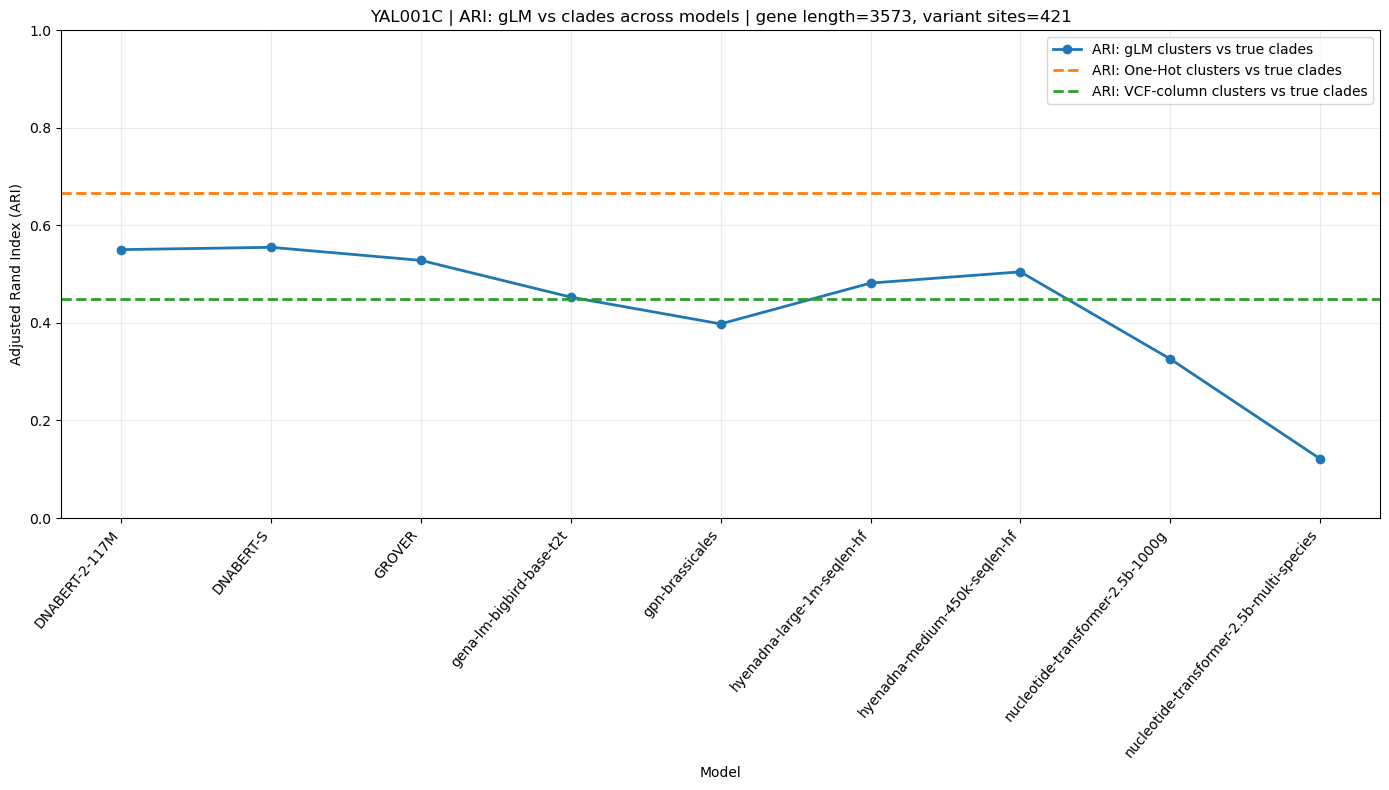

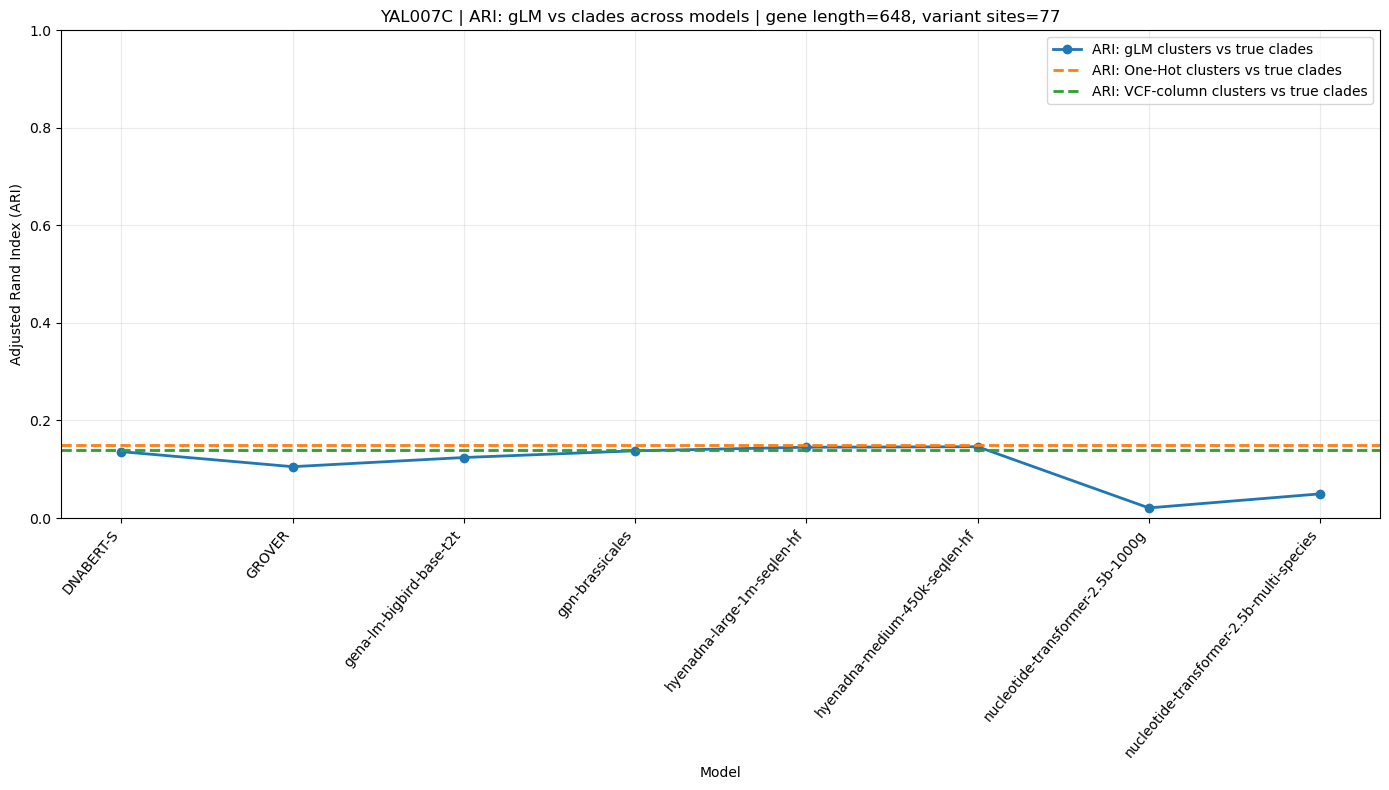

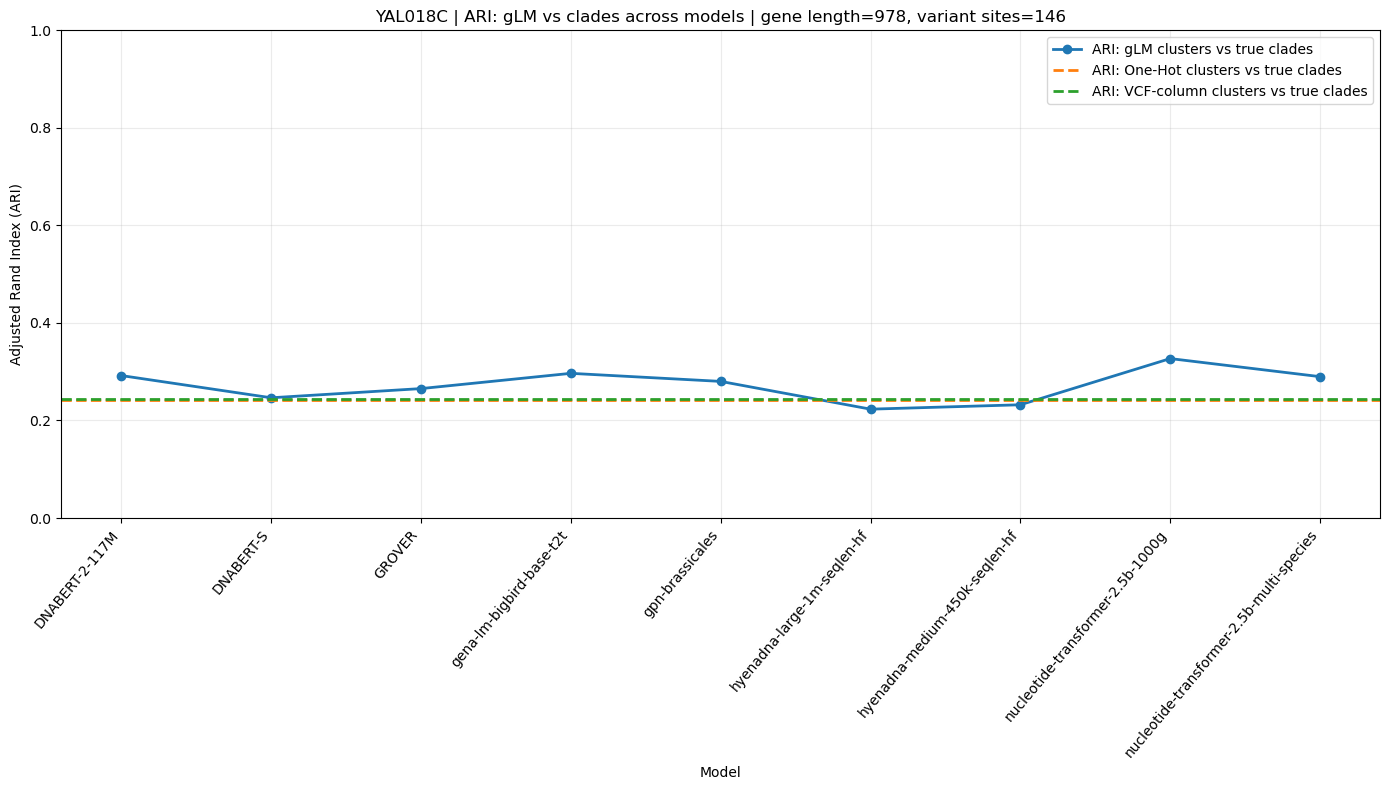

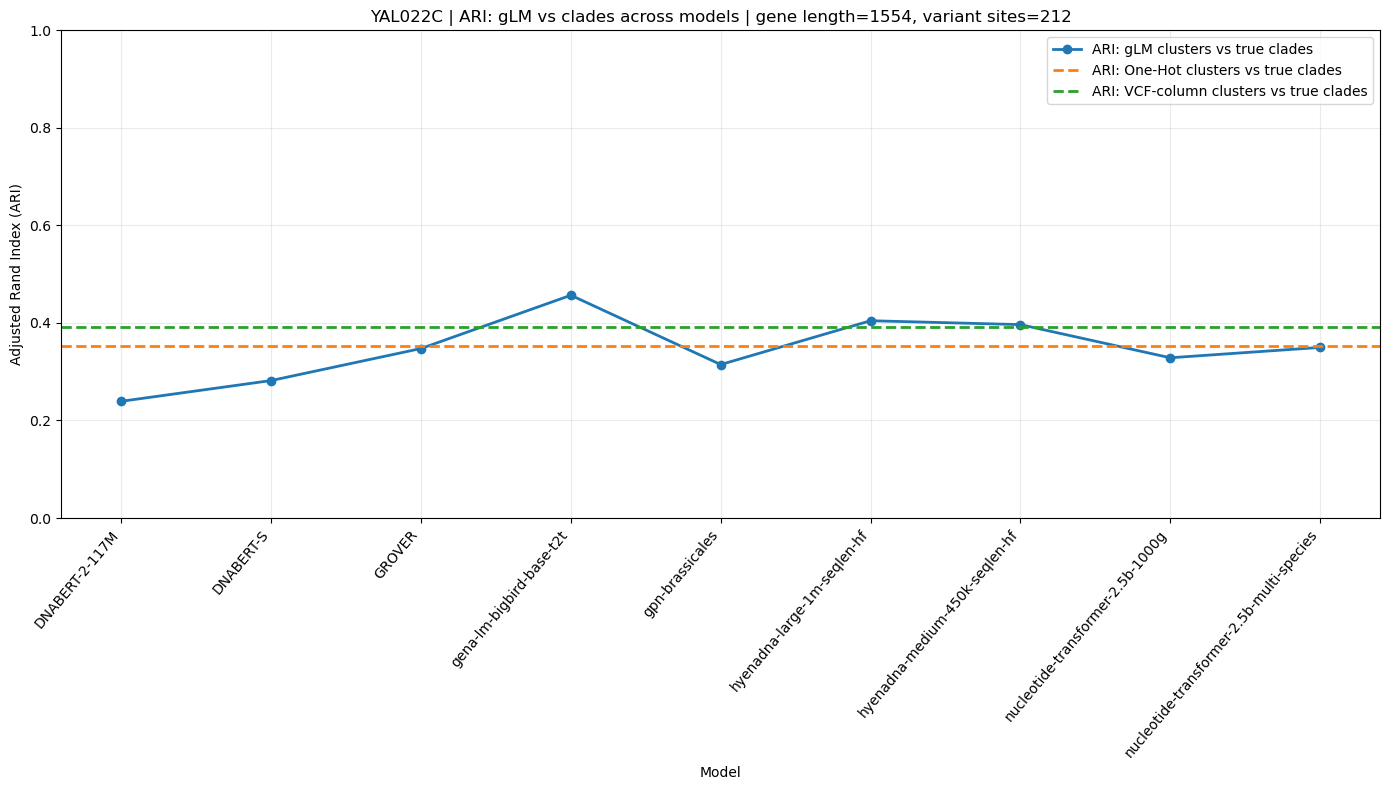

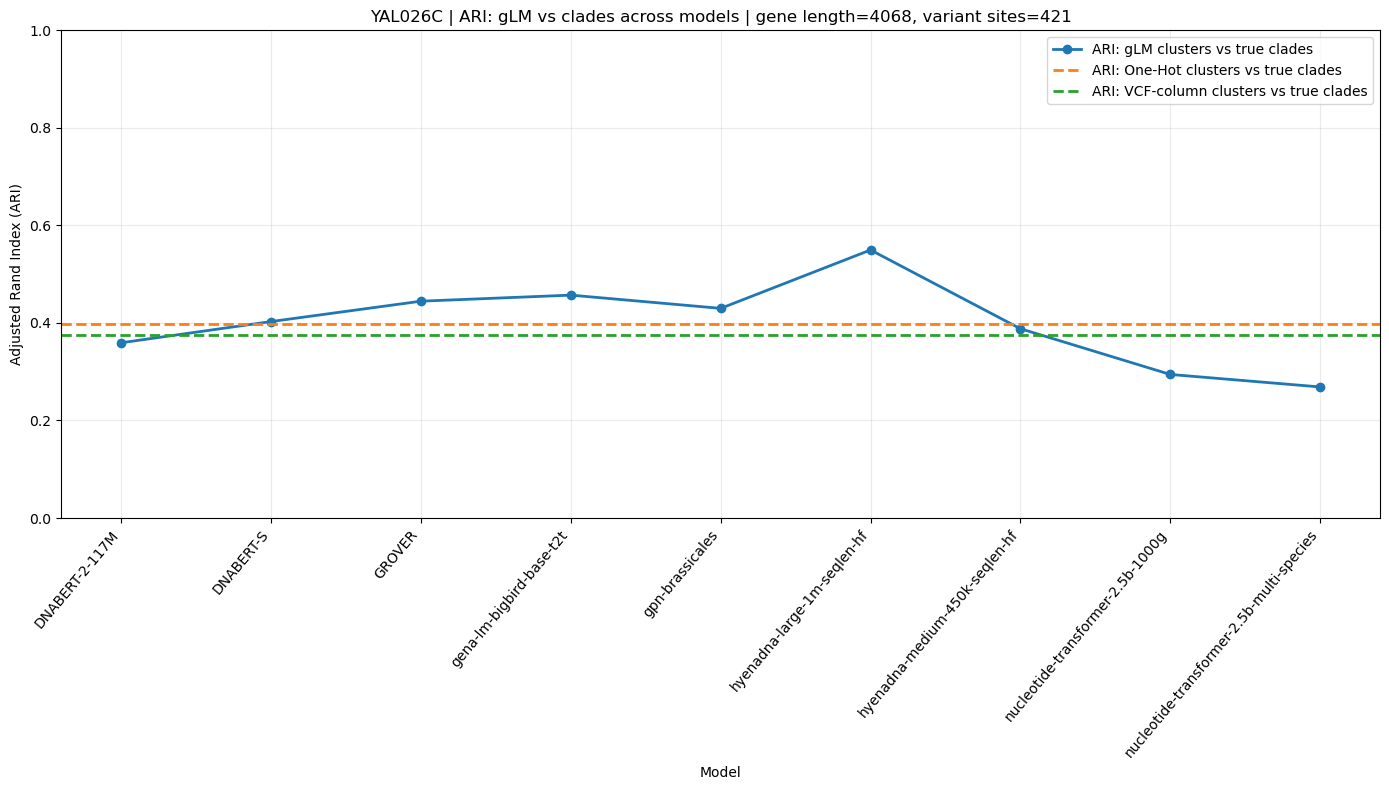

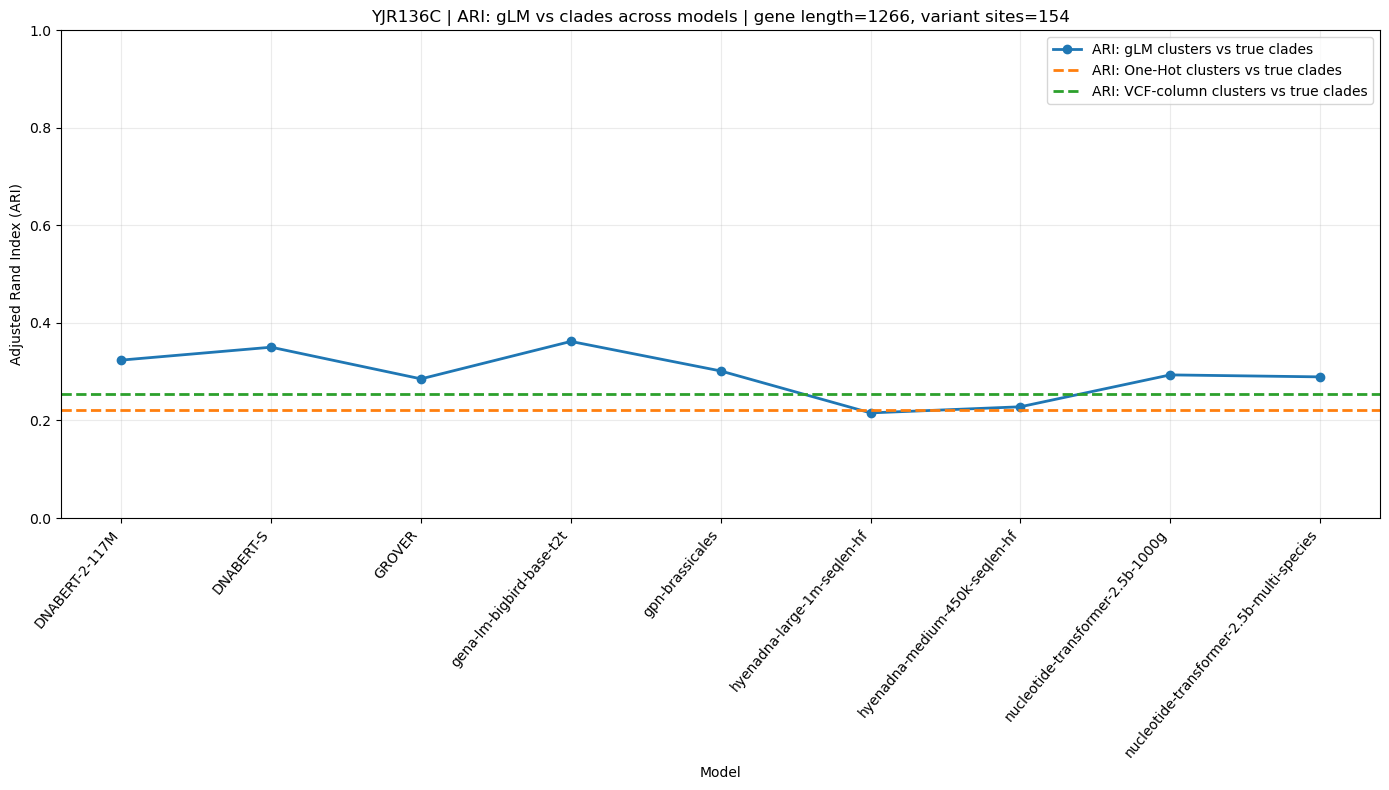

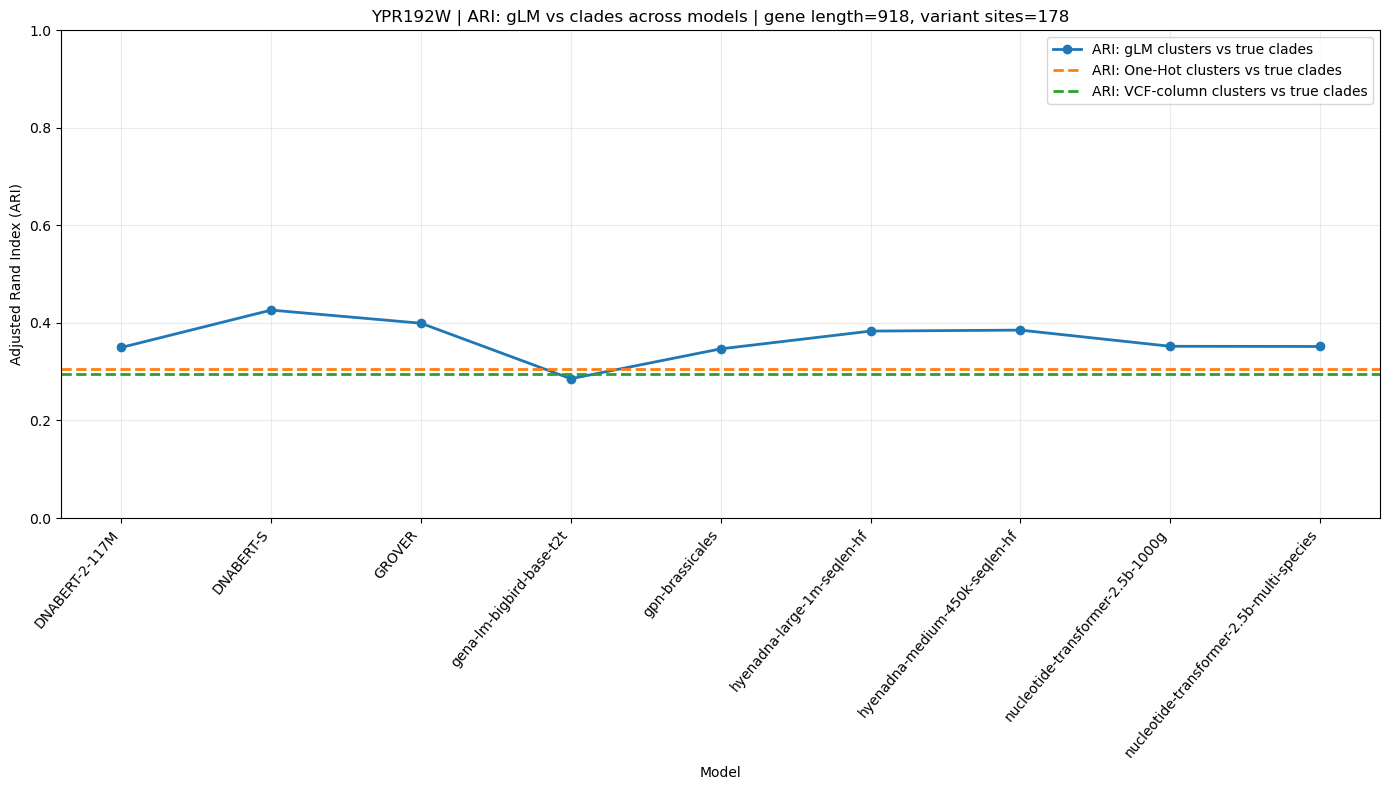

In [9]:
for gene in sorted(plot_df["gene"].unique()):
    g = plot_df[plot_df["gene"] == gene].sort_values("model_short")

    plt.figure(figsize=(14, 8))
    plt.plot(
        g["model_short"],
        g["ari_glm_vs_clades"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="ARI: gLM clusters vs true clades",
    )
    plt.axhline(
        g["ari_onehot_vs_clades"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:orange",
        label="ARI: One-Hot clusters vs true clades",
    )
    plt.axhline(
        g["ari_vcf_vs_clades"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:green",
        label="ARI: VCF-column clusters vs true clades",
    )

    seq_len = g["seq_len"].iloc[0]
    n_sites = g["n_variant_sites"].iloc[0]
    plt.title(f"{gene} | ARI: gLM vs clades across models | gene length={seq_len}, variant sites={n_sites}")
    plt.xlabel("Model")
    plt.ylabel("Adjusted Rand Index (ARI)")
    plt.ylim(0, 1)
    plt.xticks(rotation=50, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

## individual silhouette scores

individual silhouette scores for the same; how good the clusterings are in terms of grouping

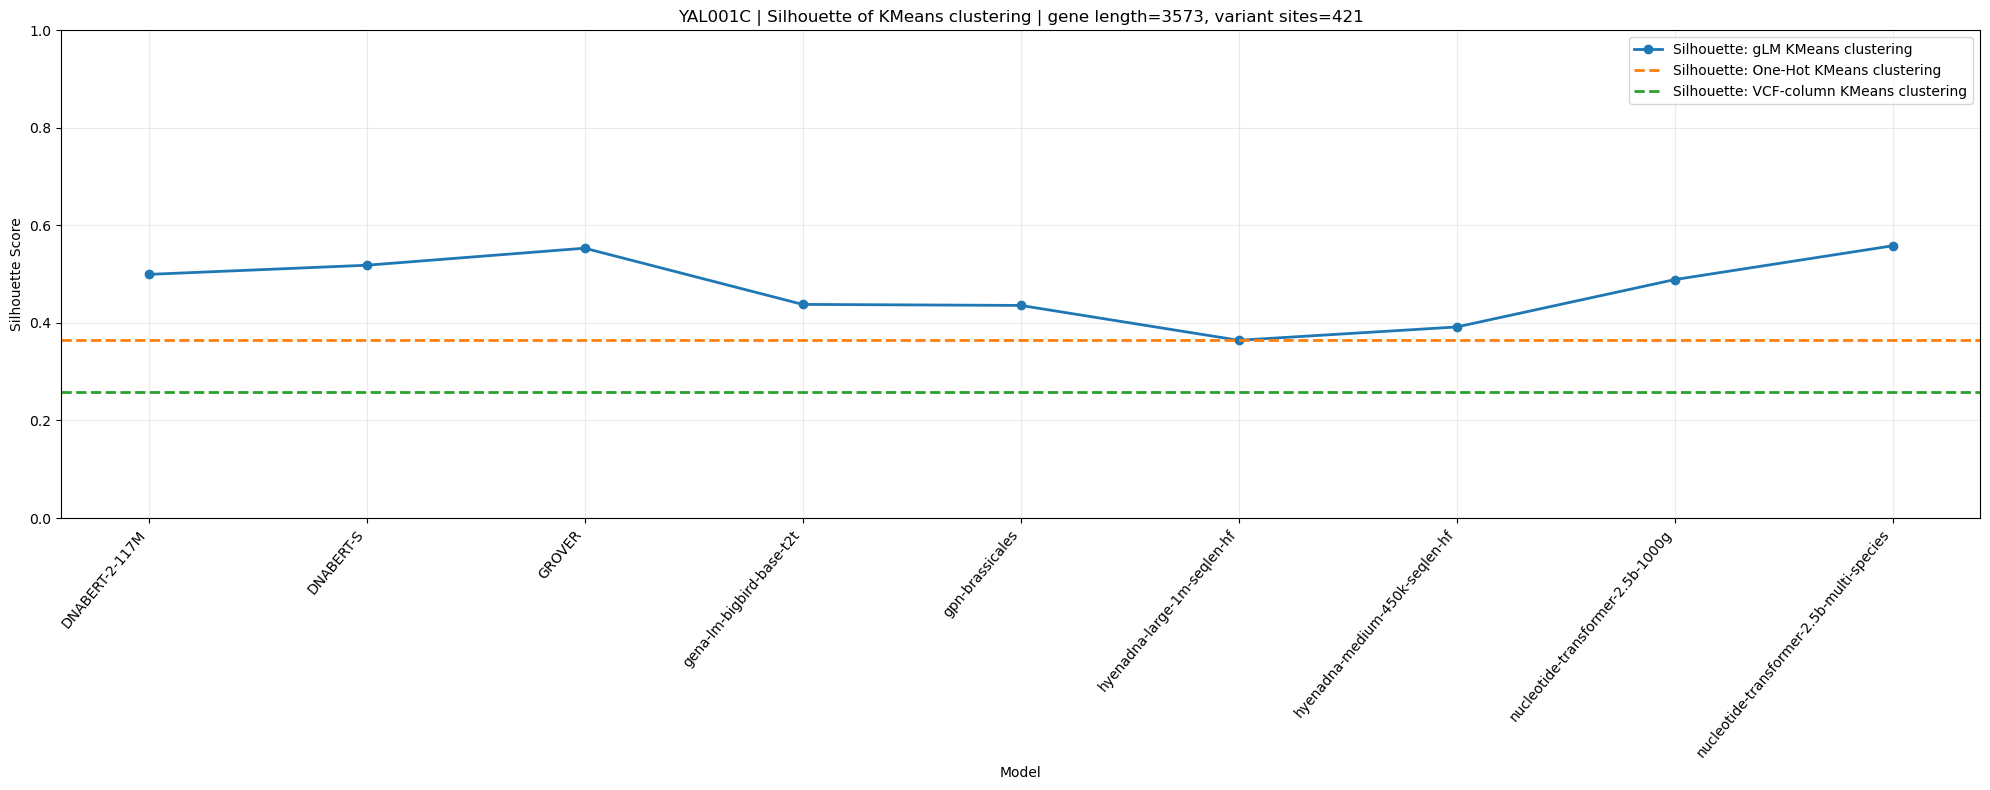

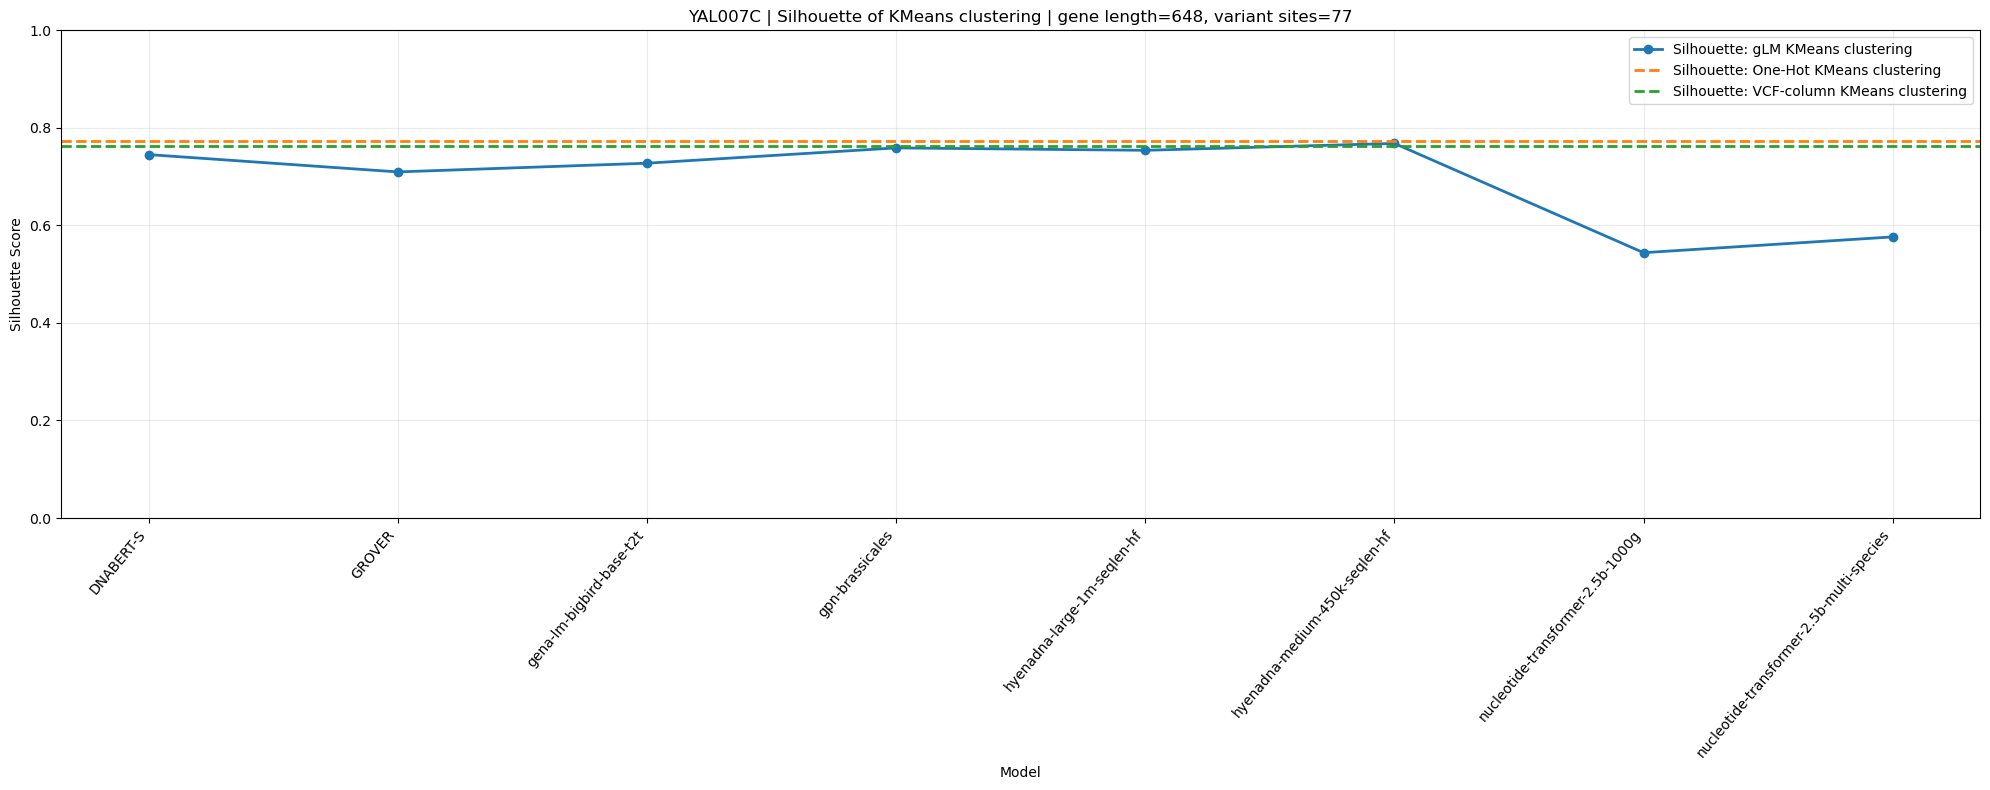

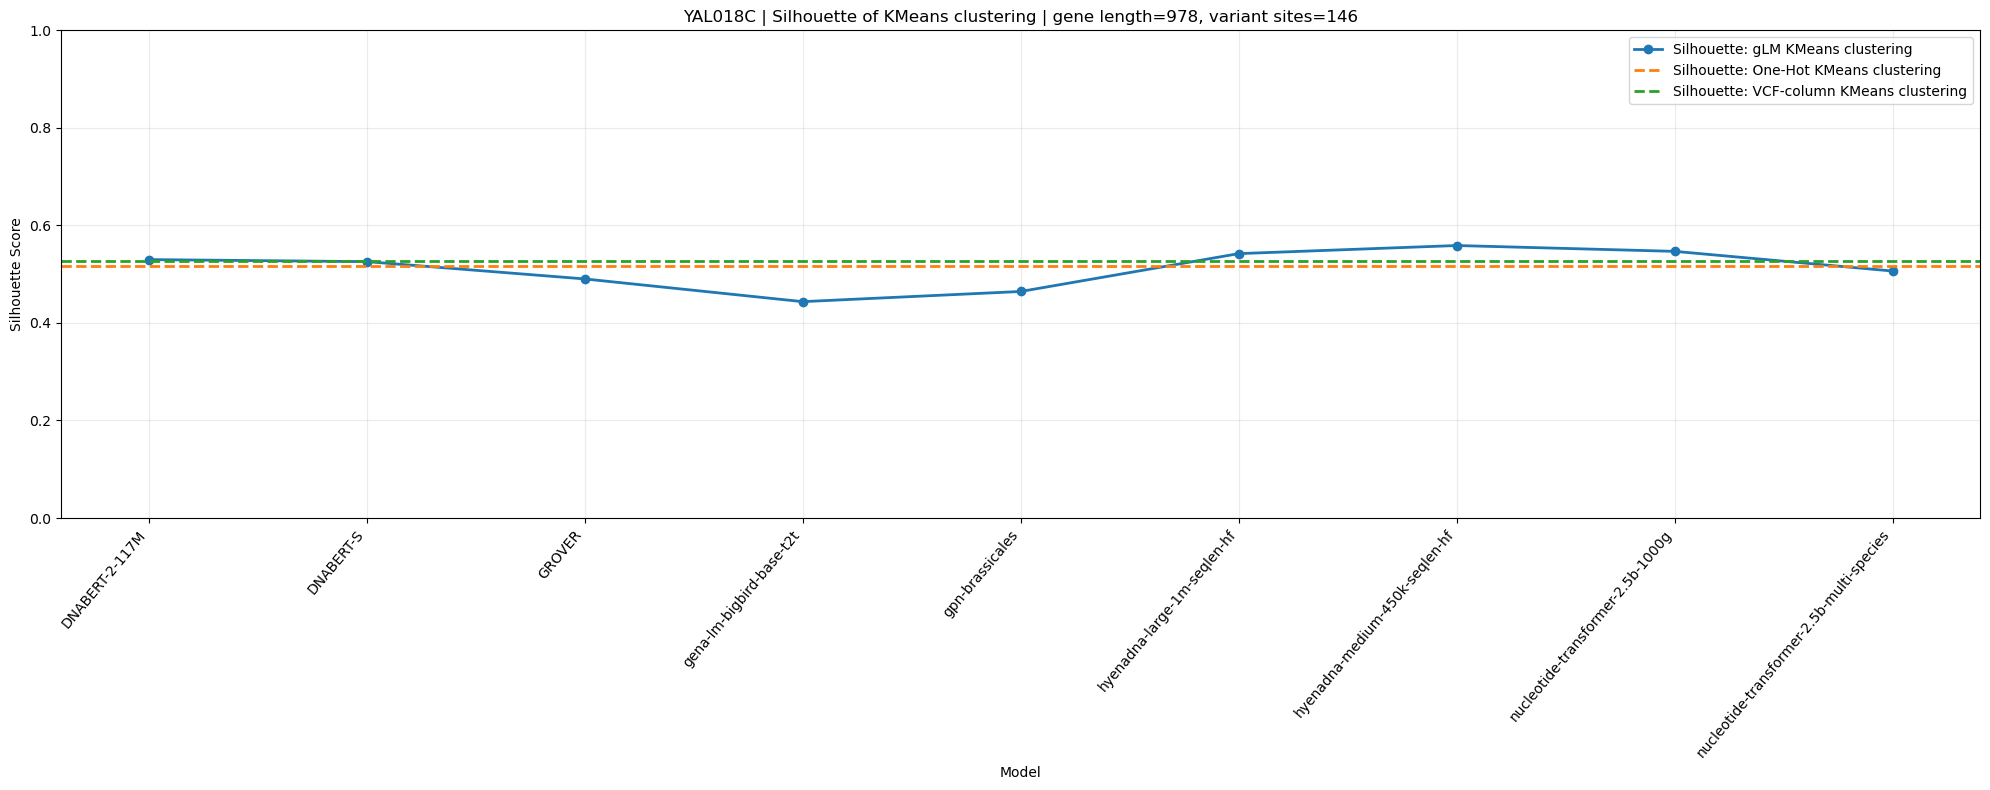

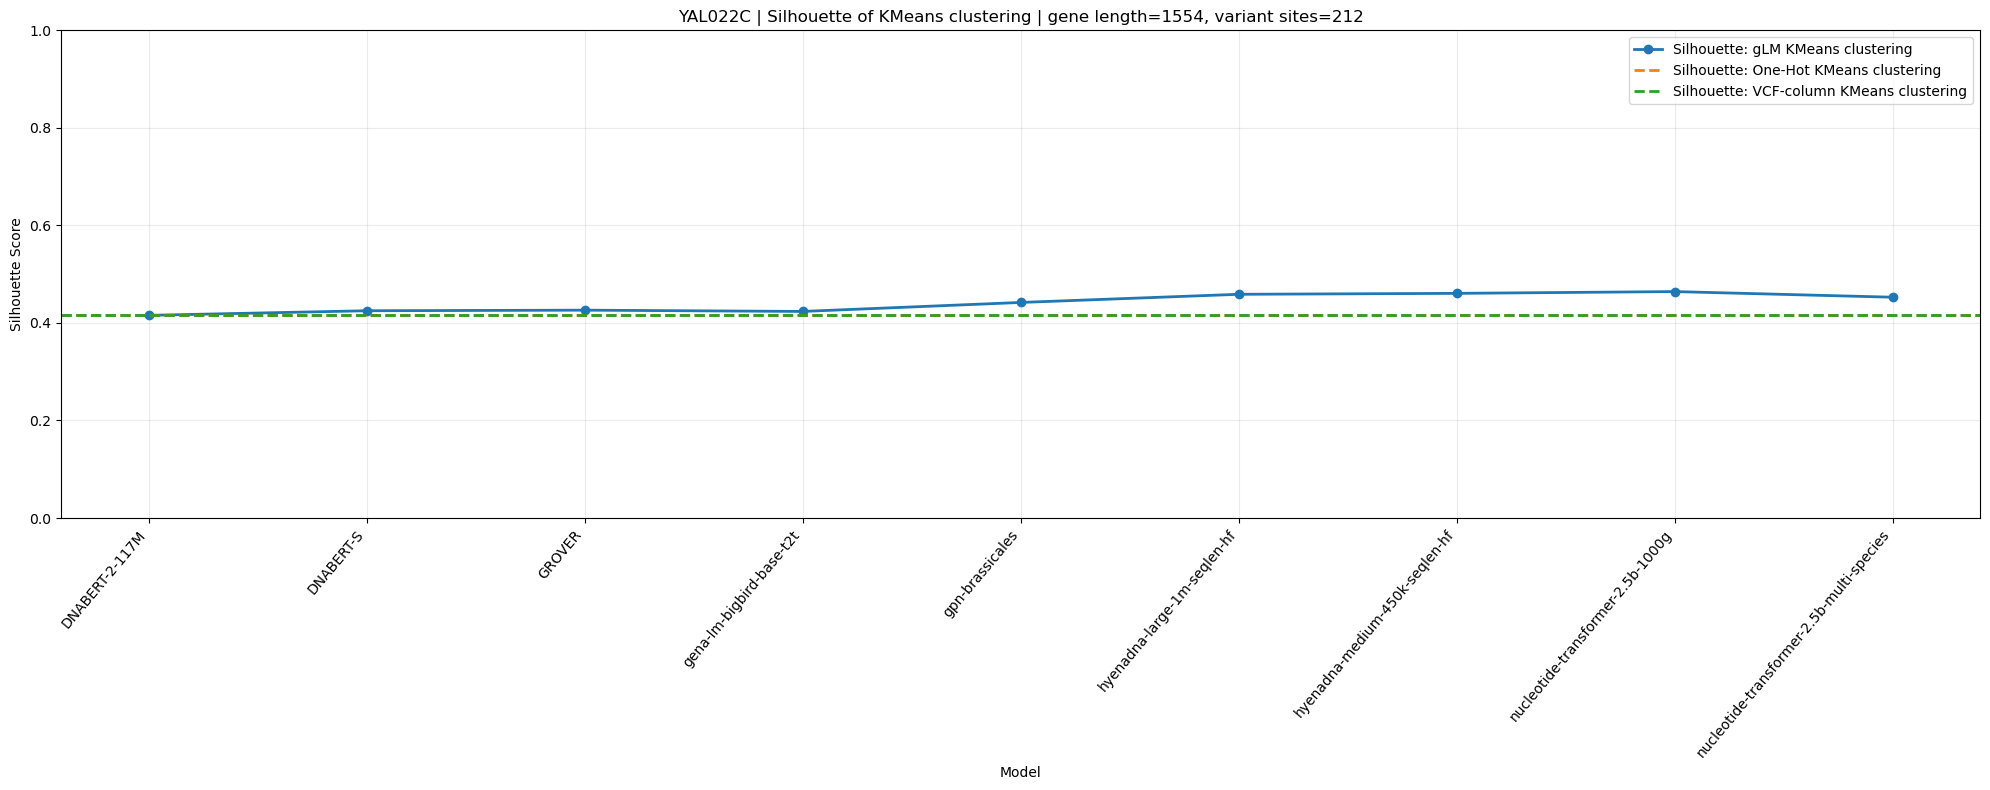

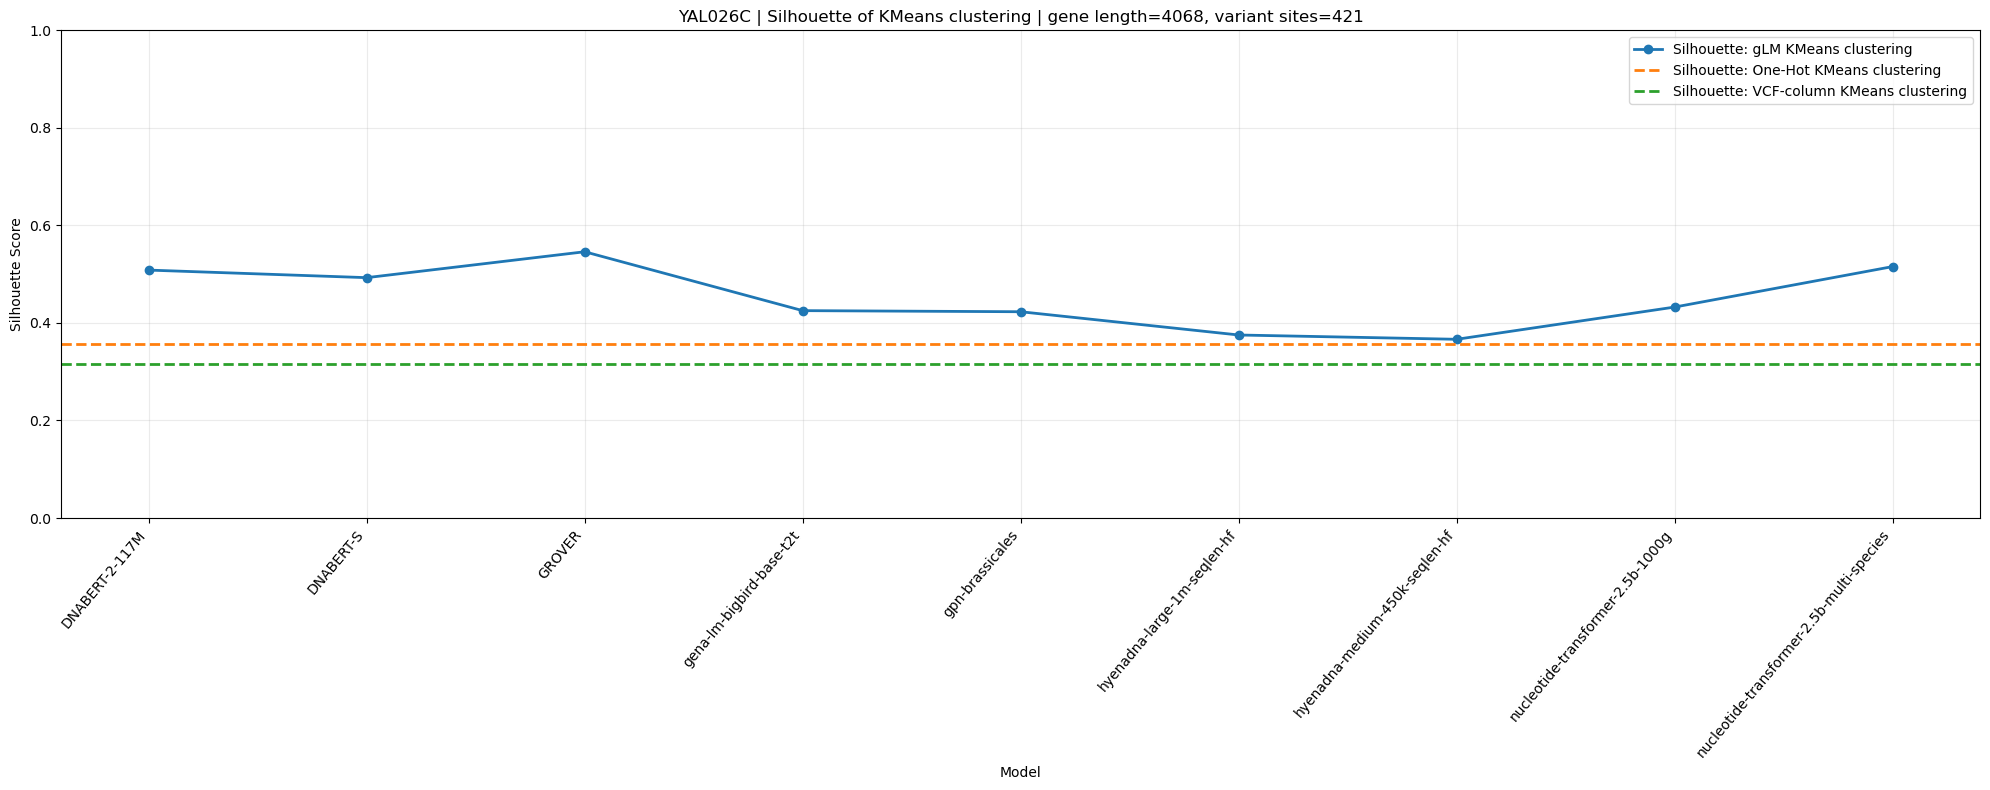

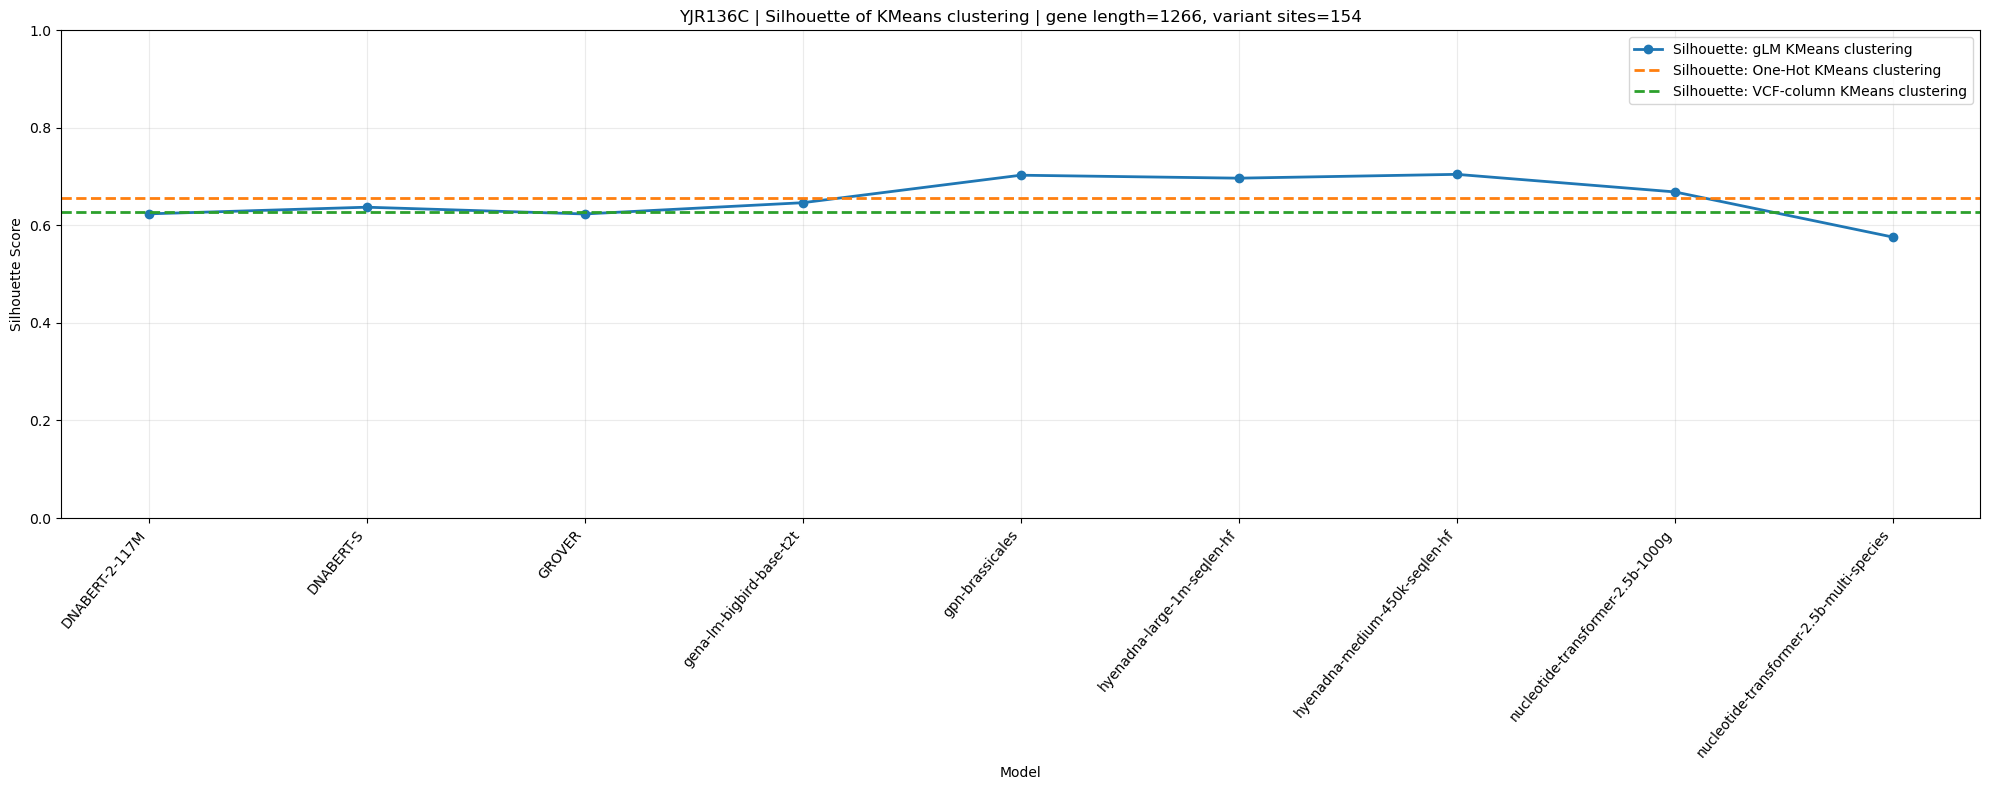

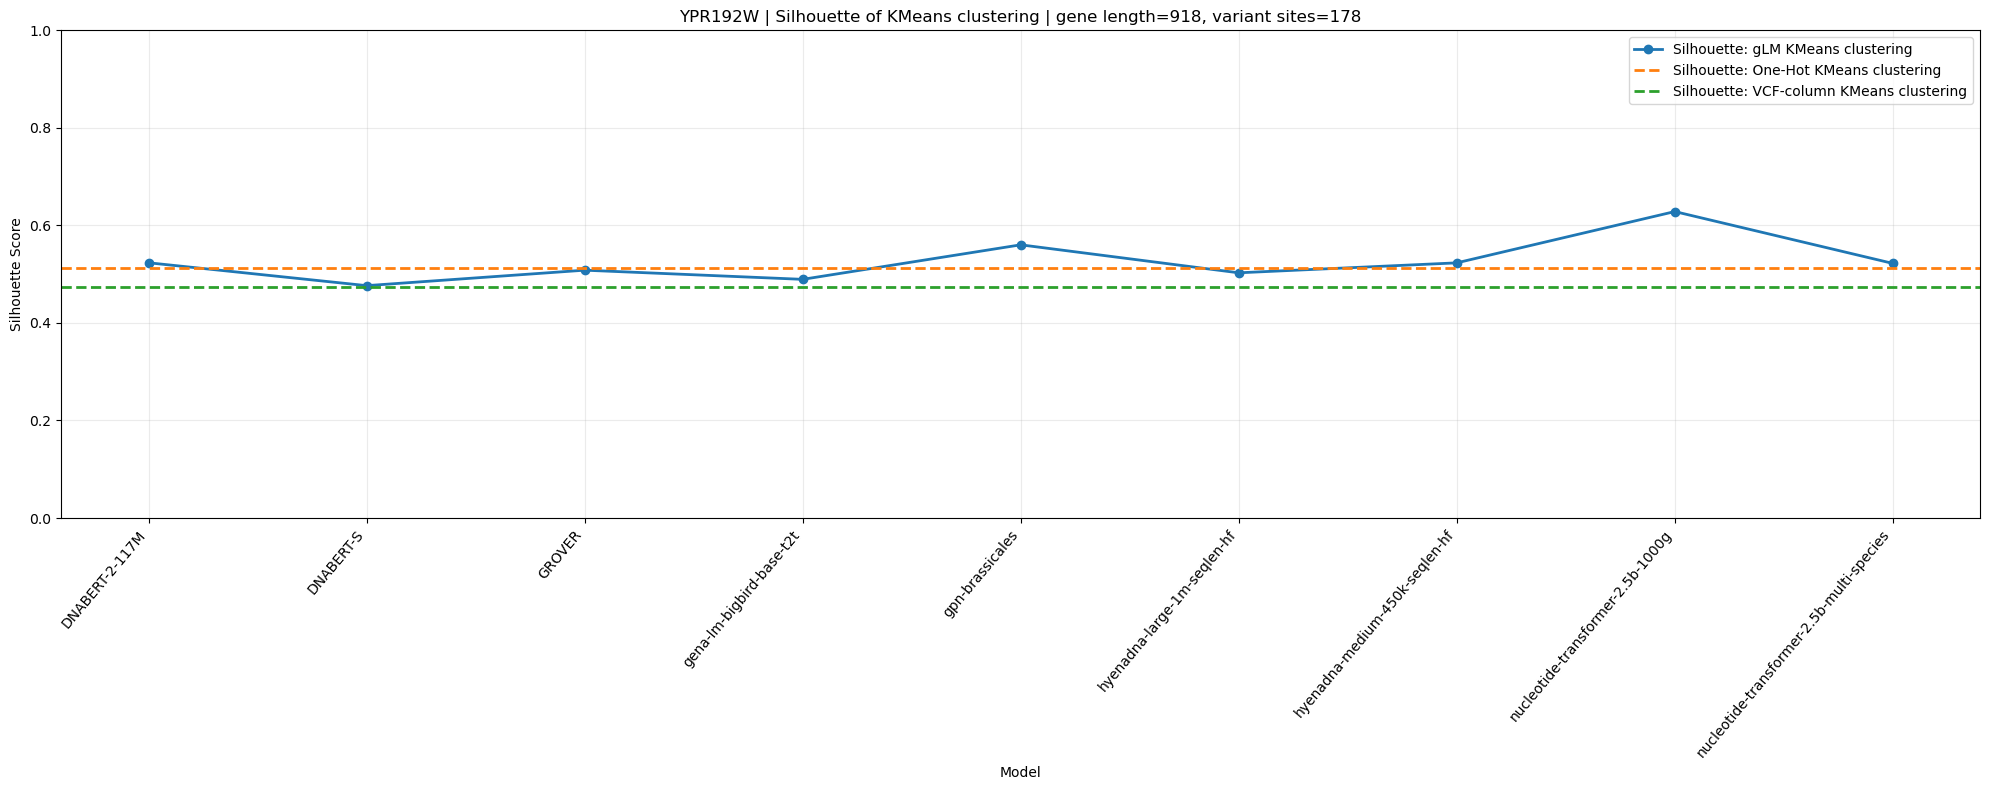

In [10]:
for gene in sorted(plot_df["gene"].unique()):
    g = plot_df[plot_df["gene"] == gene].sort_values("model_short")

    plt.figure(figsize=(20, 8))
    plt.plot(
        g["model_short"],
        g["sil_glm"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="Silhouette: gLM KMeans clustering",
    )
    plt.axhline(
        g["sil_onehot"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:orange",
        label="Silhouette: One-Hot KMeans clustering",
    )
    plt.axhline(
        g["sil_vcf"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:green",
        label="Silhouette: VCF-column KMeans clustering",
    )

    seq_len = g["seq_len"].iloc[0]
    n_sites = g["n_variant_sites"].iloc[0]
    plt.title(f"{gene} | Silhouette of KMeans clustering | gene length={seq_len}, variant sites={n_sites}")
    plt.xlabel("Model")
    plt.ylabel("Silhouette Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=50, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

## pairwise ARIs;
glm v/s one-hot and glm v/s VCF; how similar the clustering of glm embeddings is to both one hot and vcf encodings

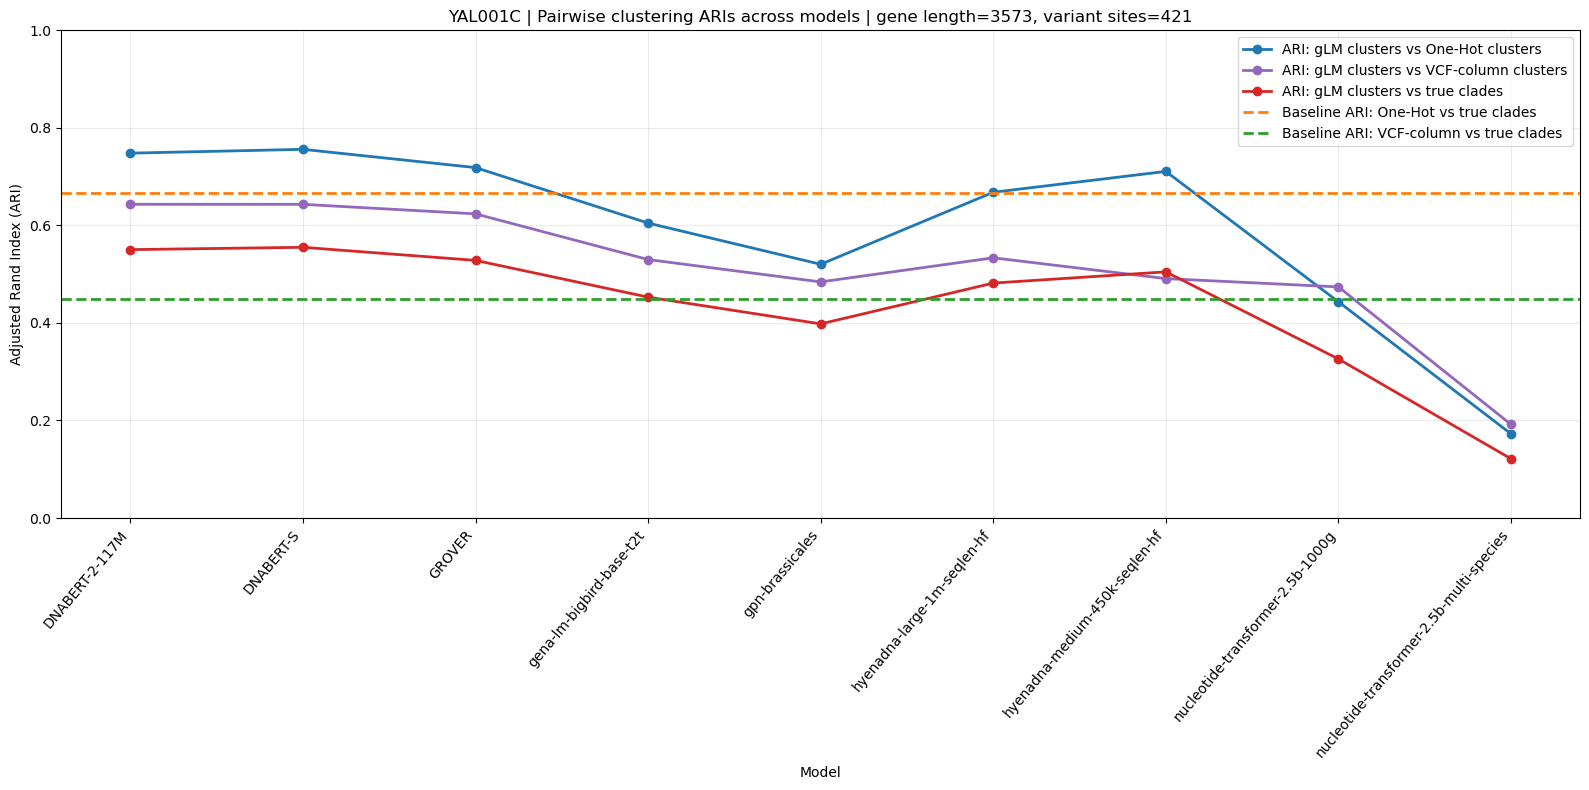

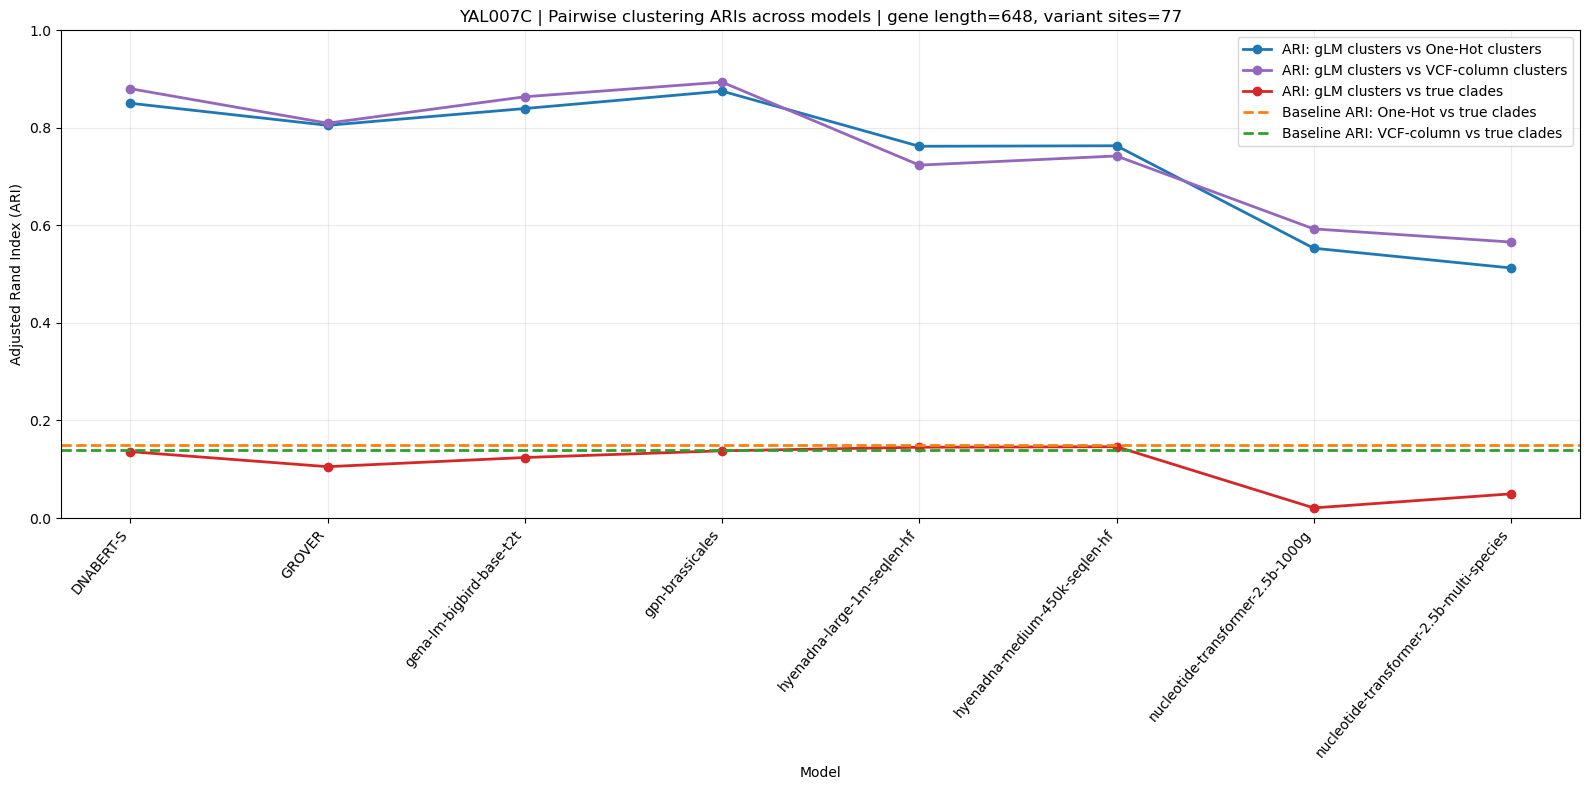

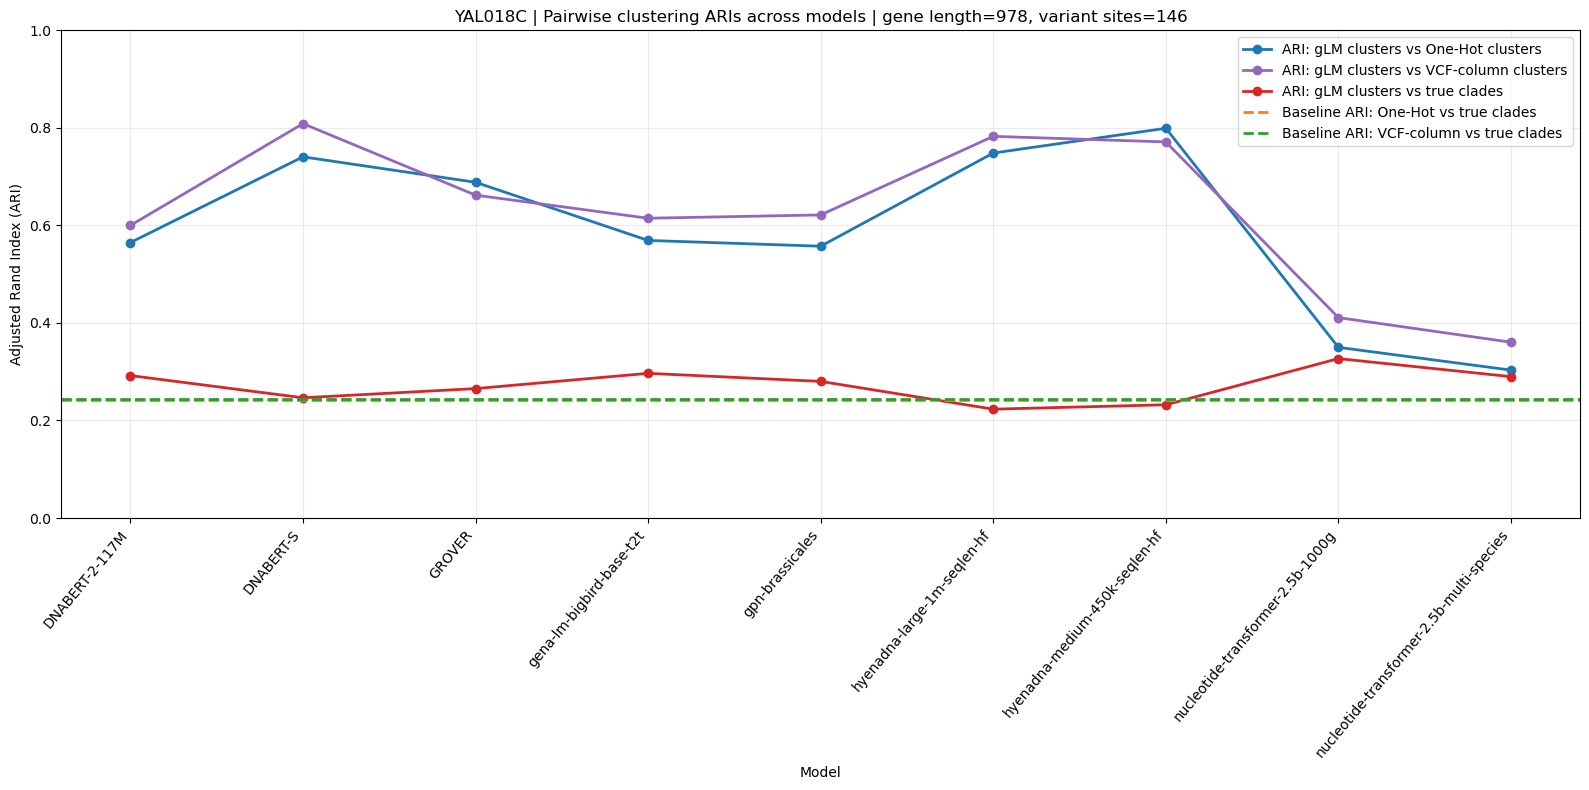

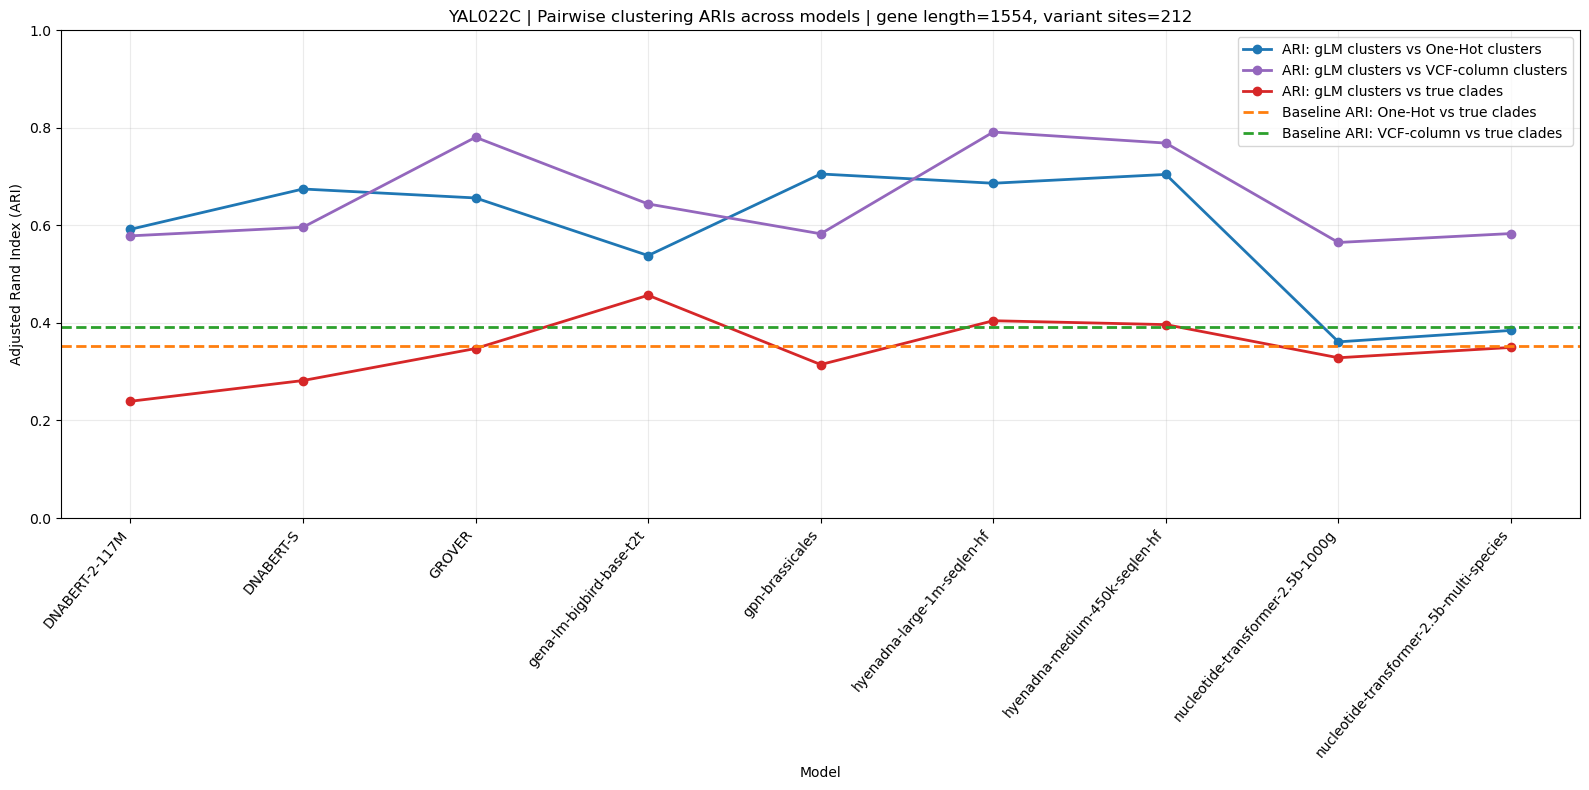

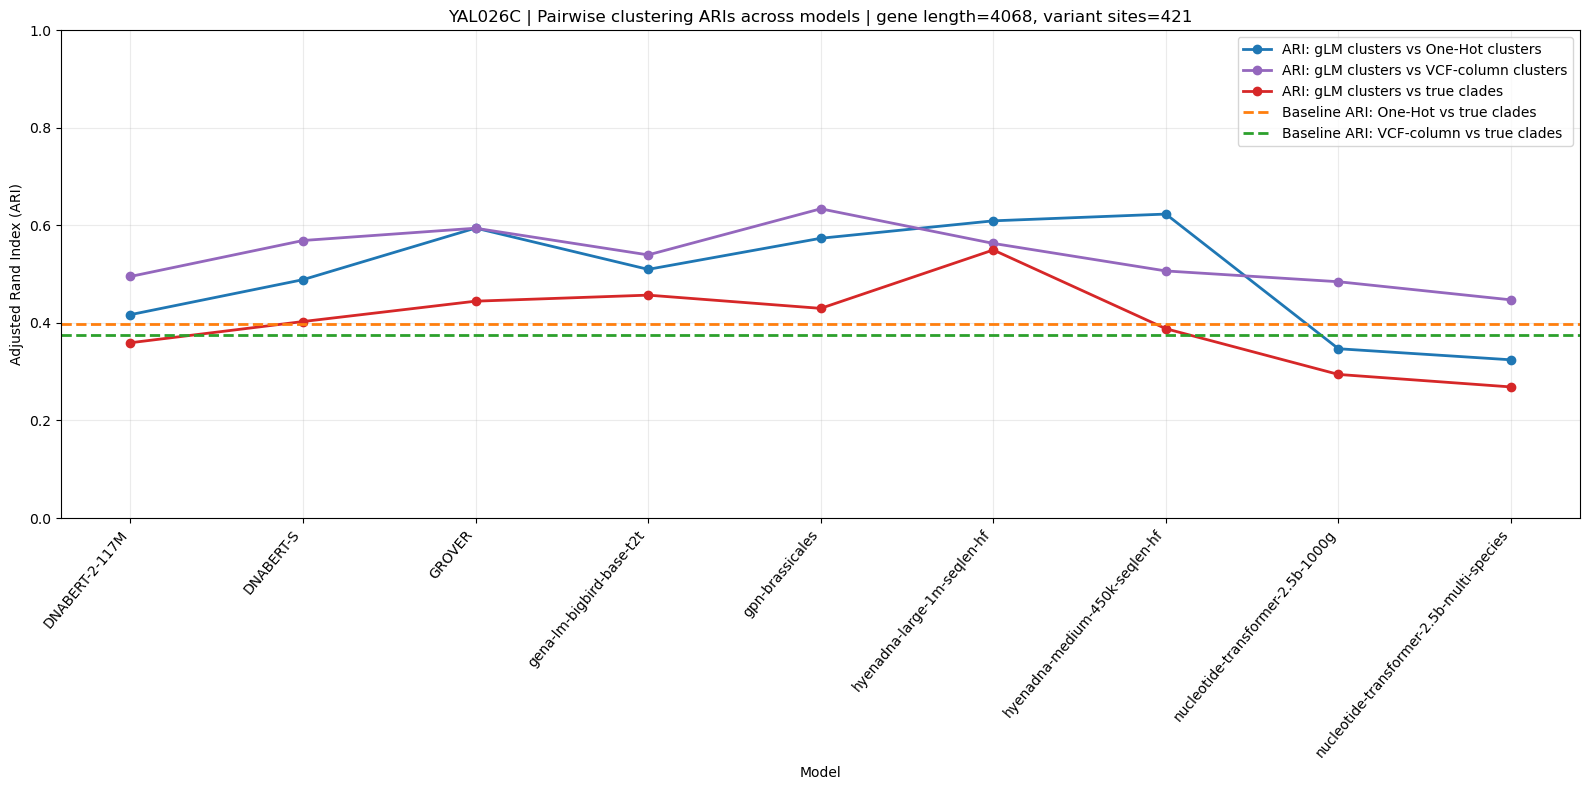

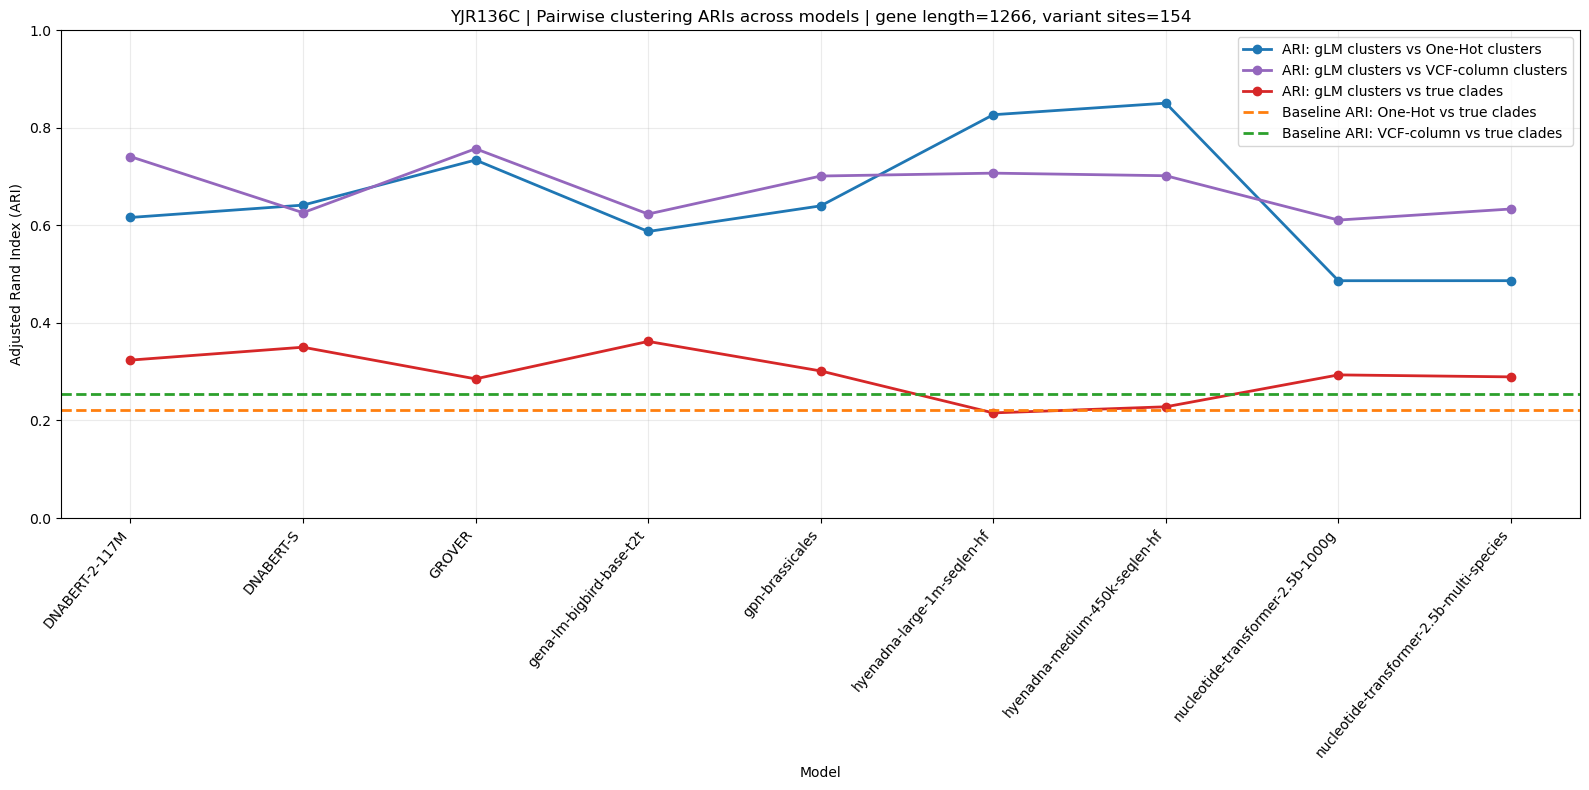

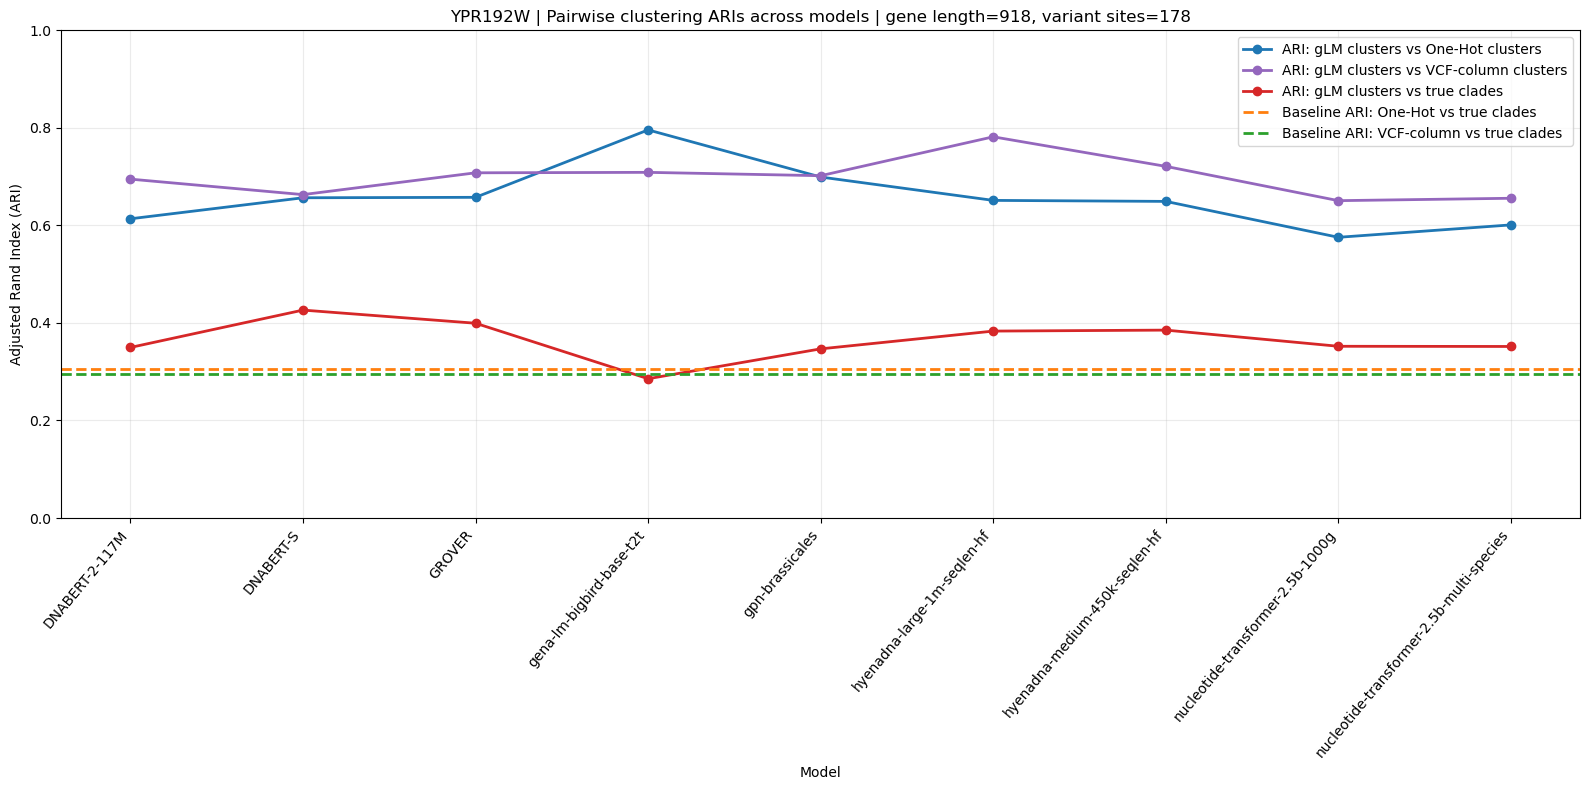

In [ ]:
# 3) Pairwise ARIs across models: gLM-vs-OneHot and gLM-vs-VCF, with clade-reference lines
for gene in sorted(plot_df["gene"].unique()):
    g = plot_df[plot_df["gene"] == gene].sort_values("model_short")

    plt.figure(figsize=(16, 8))
    plt.plot(
        g["model_short"],
        g["ari_glm_vs_onehot"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="ARI: gLM clusters vs One-Hot clusters",
    )
    plt.plot(
        g["model_short"],
        g["ari_glm_vs_vcf"],
        marker="o",
        linewidth=2,
        color="tab:purple",
        label="ARI: gLM clusters vs VCF-column clusters",
    )
    plt.plot(
        g["model_short"],
        g["ari_glm_vs_clades"],
        marker="o",
        linewidth=2,
        color="tab:red",
        label="ARI: gLM clusters vs true clades",
    )
    plt.axhline(
        g["ari_onehot_vs_clades"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:orange",
        label="Baseline ARI: One-Hot vs true clades",
    )
    plt.axhline(
        g["ari_vcf_vs_clades"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:green",
        label="Baseline ARI: VCF-column vs true clades",
    )

    seq_len = g["seq_len"].iloc[0]
    n_sites = g["n_variant_sites"].iloc[0]
    plt.title(f"{gene} | Pairwise clustering ARIs across models | gene length={seq_len}, variant sites={n_sites}")
    plt.xlabel("Model")
    plt.ylabel("Adjusted Rand Index (ARI)")
    plt.ylim(0, 1)
    plt.xticks(rotation=15, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

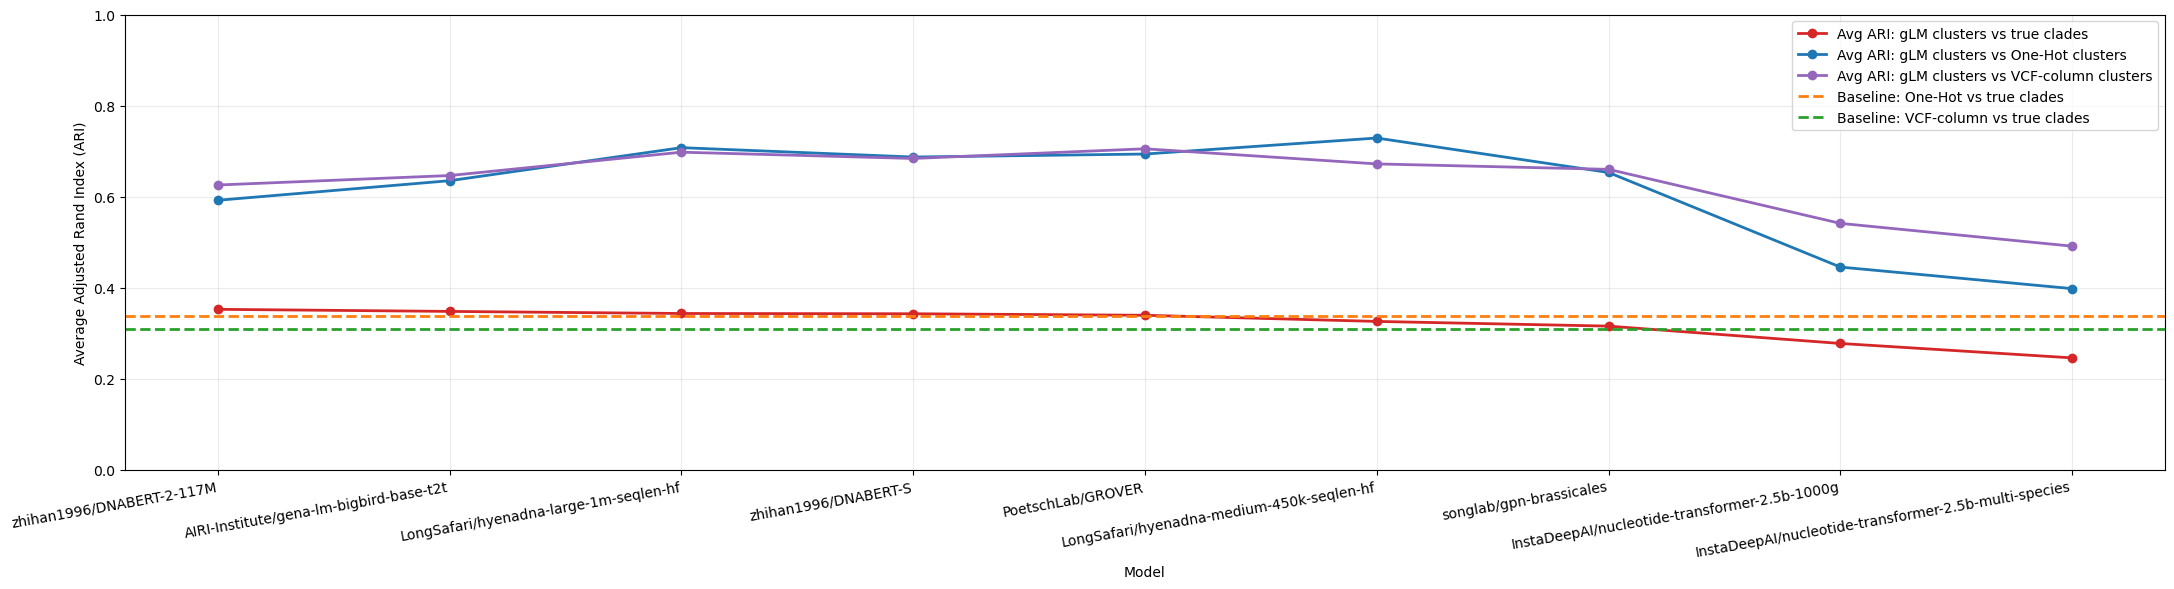

In [19]:
# Overall averaged ARI plot across all 7 genes
if len(results_df) > 0:
    avg_df = results_df.groupby("model", as_index=False)[
        [
            "ari_glm_vs_clades",
            "ari_glm_vs_onehot",
            "ari_glm_vs_vcf",
            "ari_onehot_vs_clades",
            "ari_vcf_vs_clades",
        ]
    ].mean().sort_values("ari_glm_vs_clades", ascending=False)

    plt.figure(figsize=(22, 6))
    plt.plot(
        avg_df["model"],
        avg_df["ari_glm_vs_clades"],
        marker="o",
        linewidth=2,
        color="tab:red",
        label="Avg ARI: gLM clusters vs true clades",
    )
    plt.plot(
        avg_df["model"],
        avg_df["ari_glm_vs_onehot"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="Avg ARI: gLM clusters vs One-Hot clusters",
    )
    plt.plot(
        avg_df["model"],
        avg_df["ari_glm_vs_vcf"],
        marker="o",
        linewidth=2,
        color="tab:purple",
        label="Avg ARI: gLM clusters vs VCF-column clusters",
    )
    plt.axhline(
        results_df["ari_onehot_vs_clades"].mean(),
        linestyle="--",
        linewidth=2,
        color="tab:orange",
        label="Baseline: One-Hot vs true clades",
    )
    plt.axhline(
        results_df["ari_vcf_vs_clades"].mean(),
        linestyle="--",
        linewidth=2,
        color="tab:green",
        label="Baseline: VCF-column vs true clades",
    )

    plt.xlabel("Model")
    plt.ylabel("Average Adjusted Rand Index (ARI)")
    plt.ylim(0, 1)
    plt.xticks(rotation=10, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("No results available to plot.")

## CKA b/w glm and one hot encodings

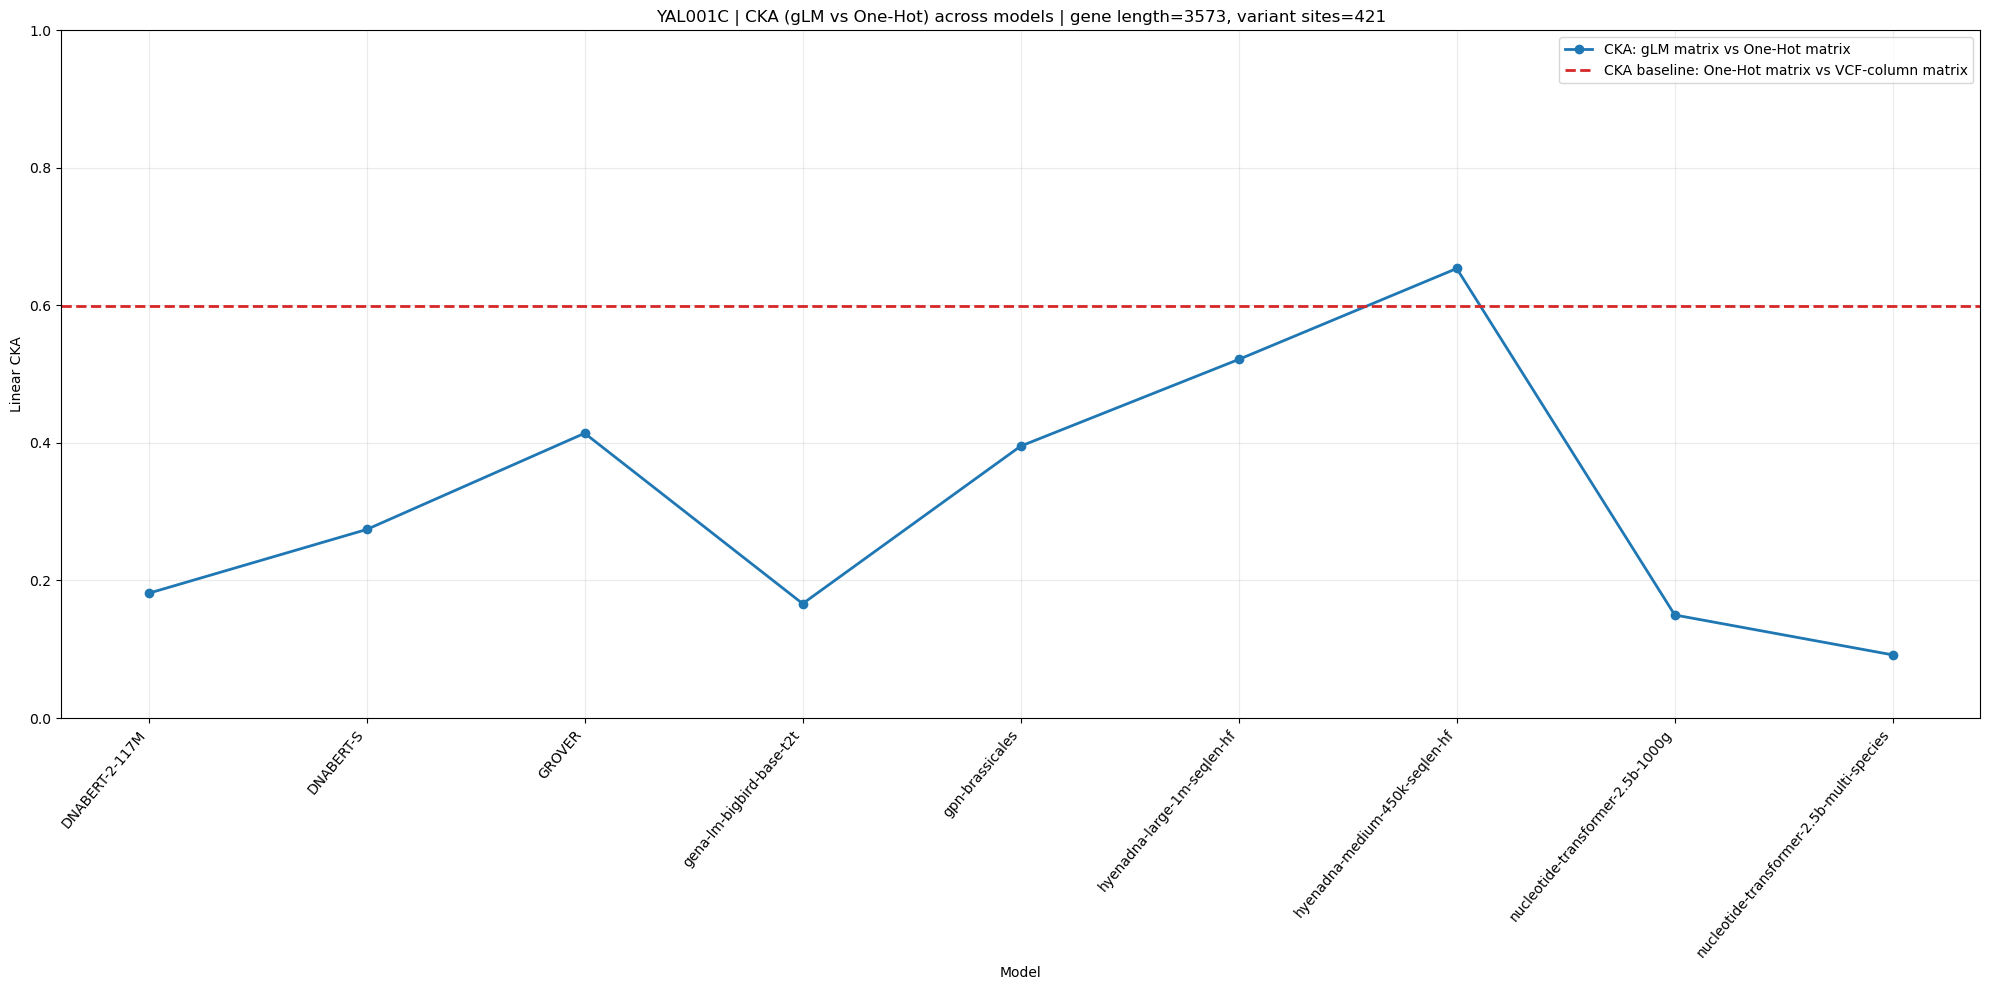

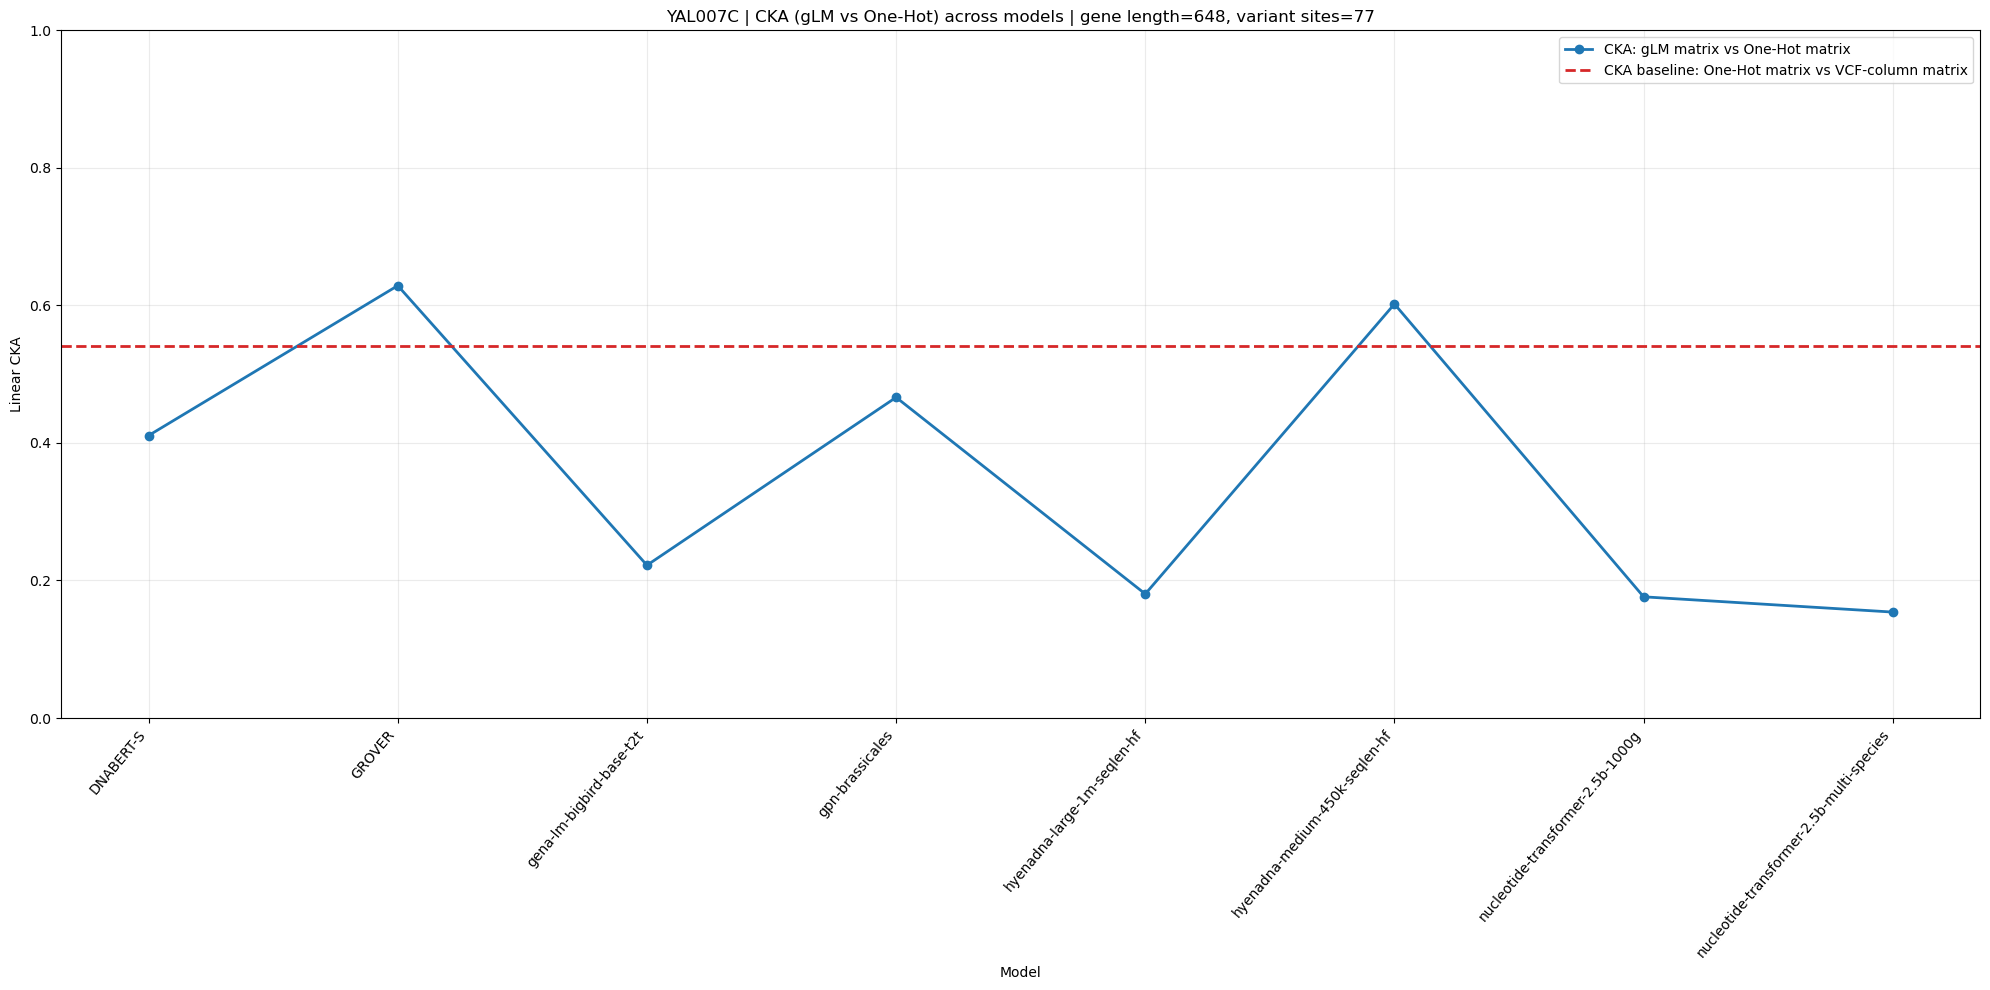

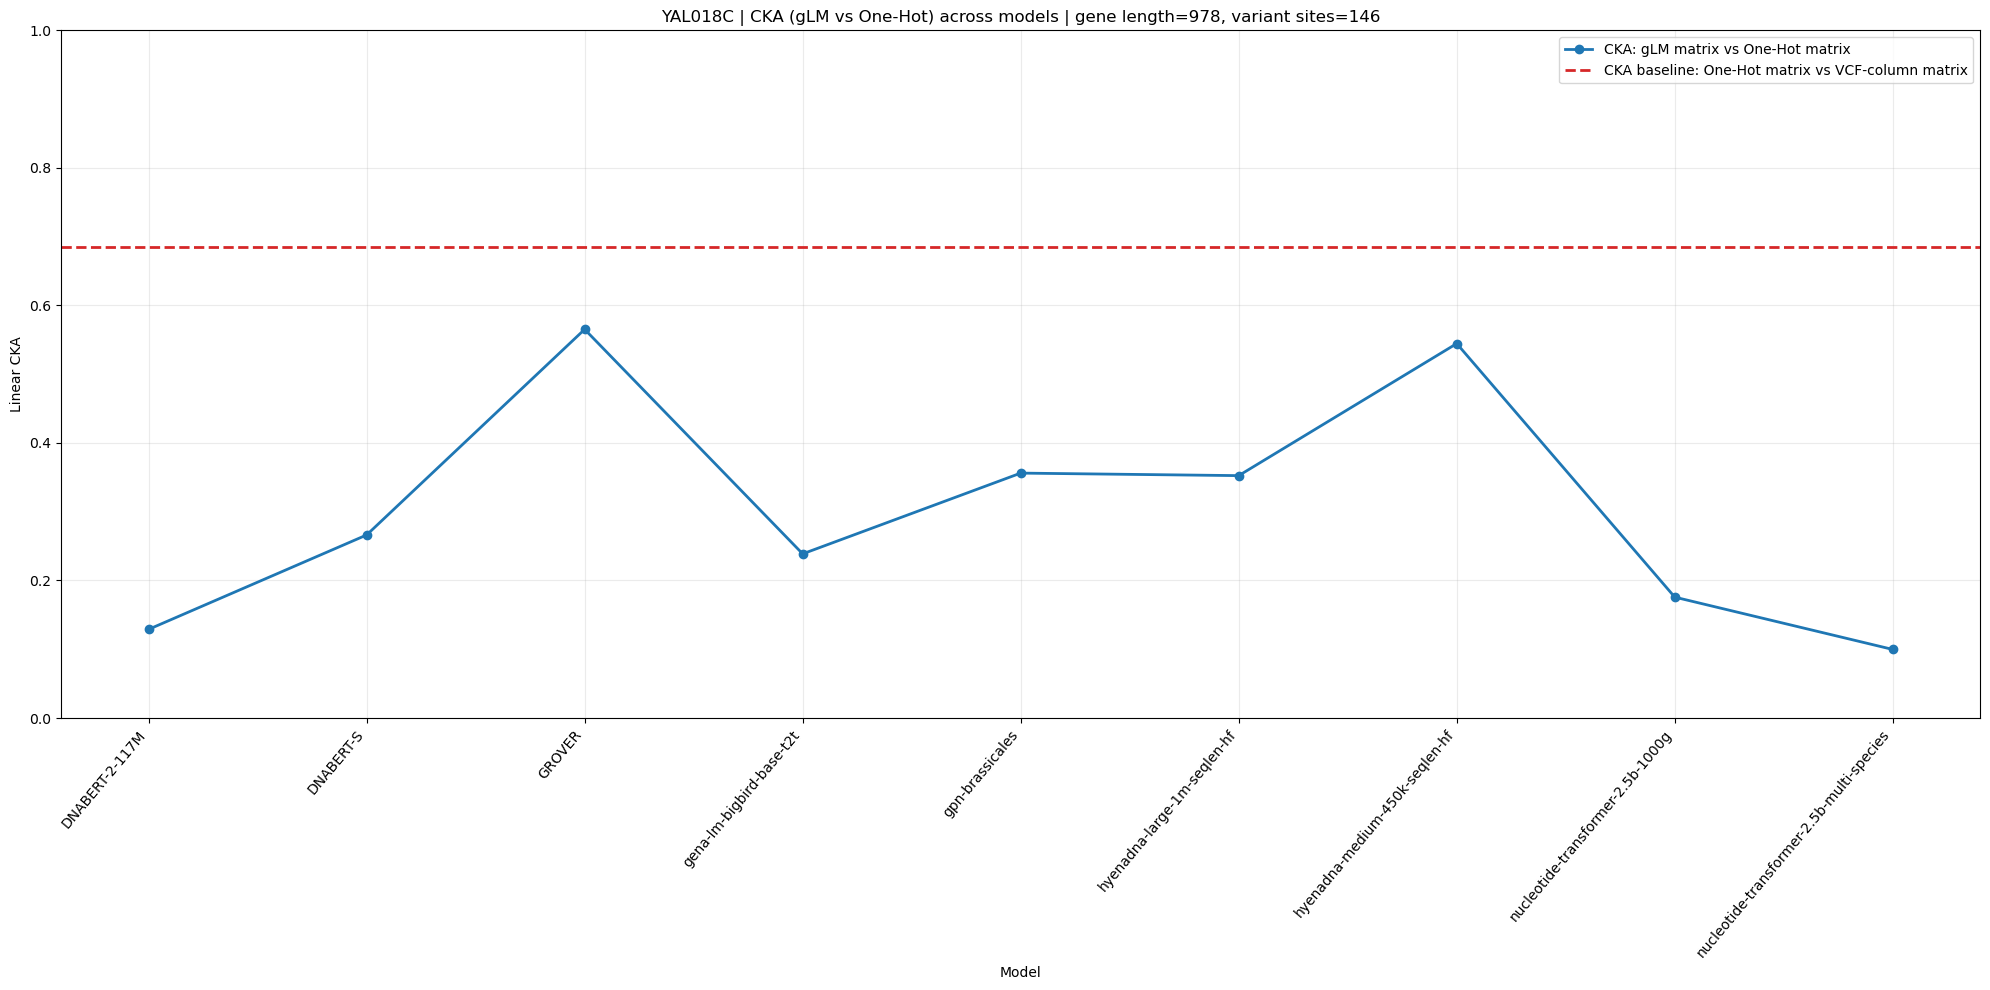

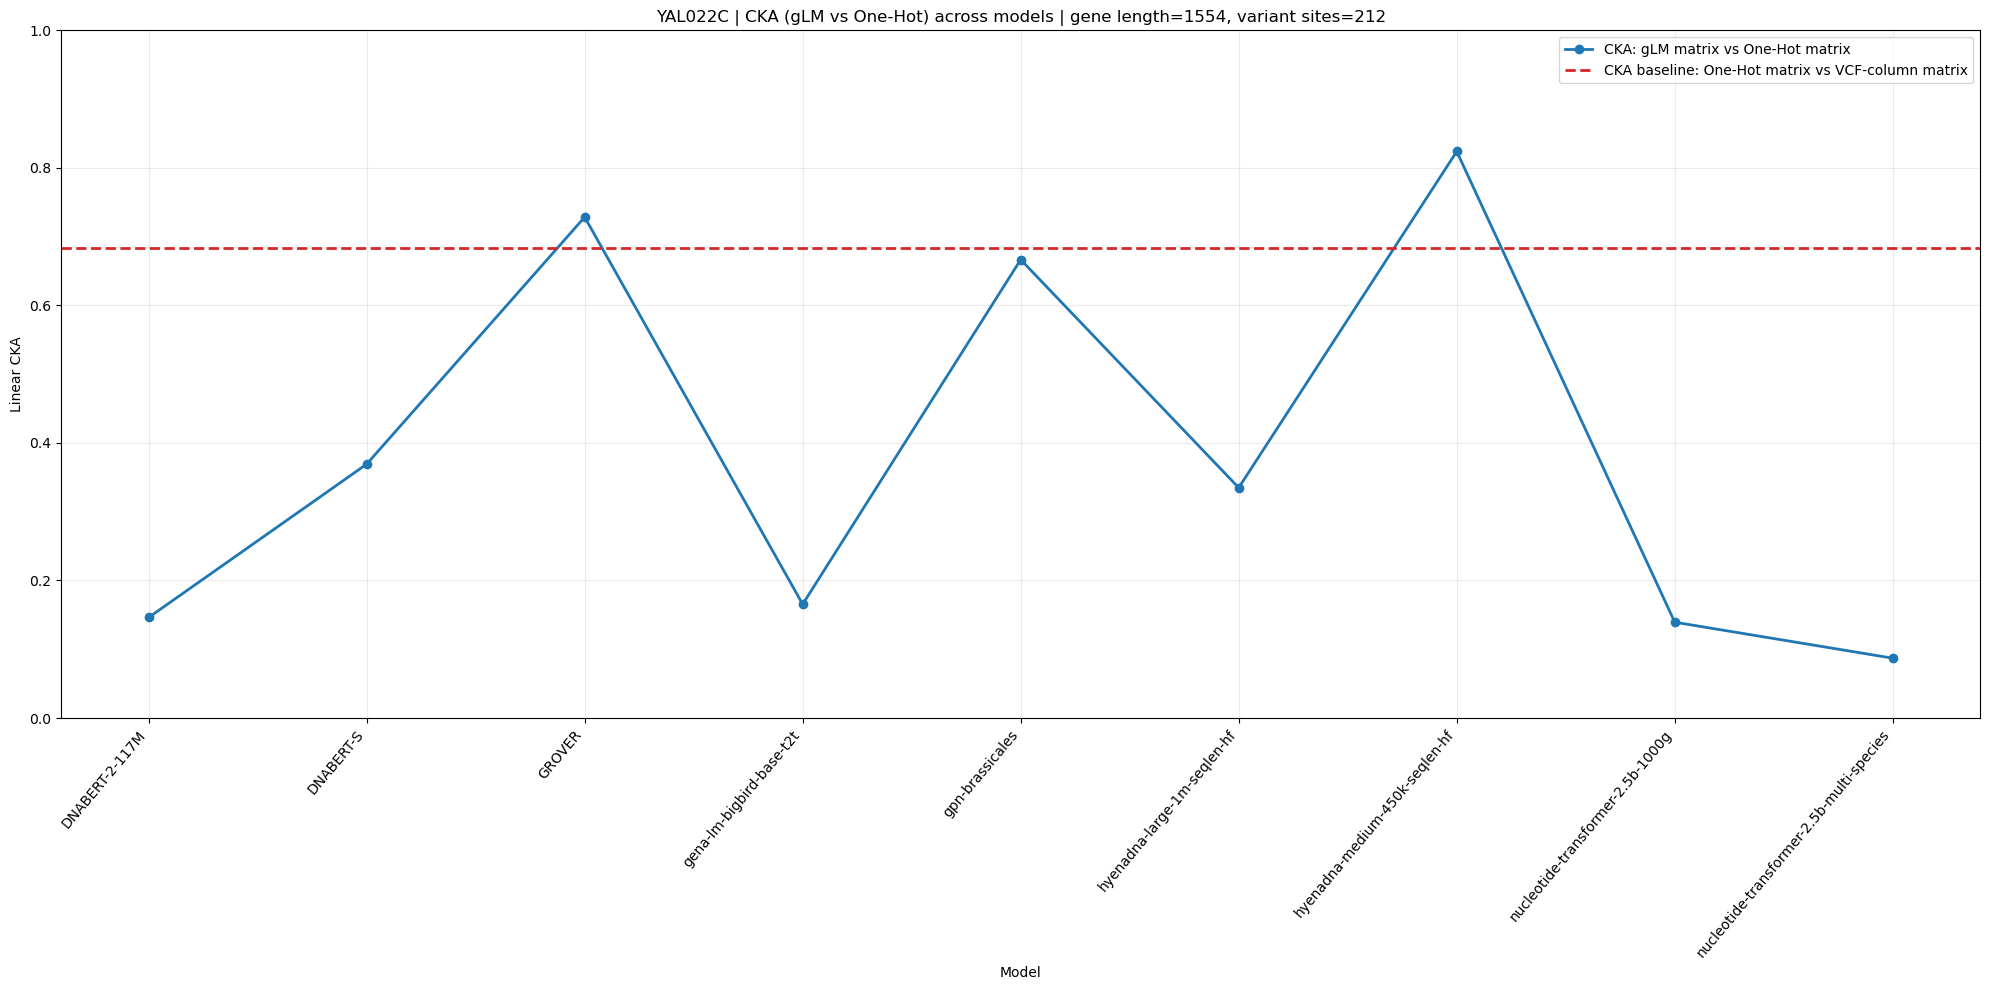

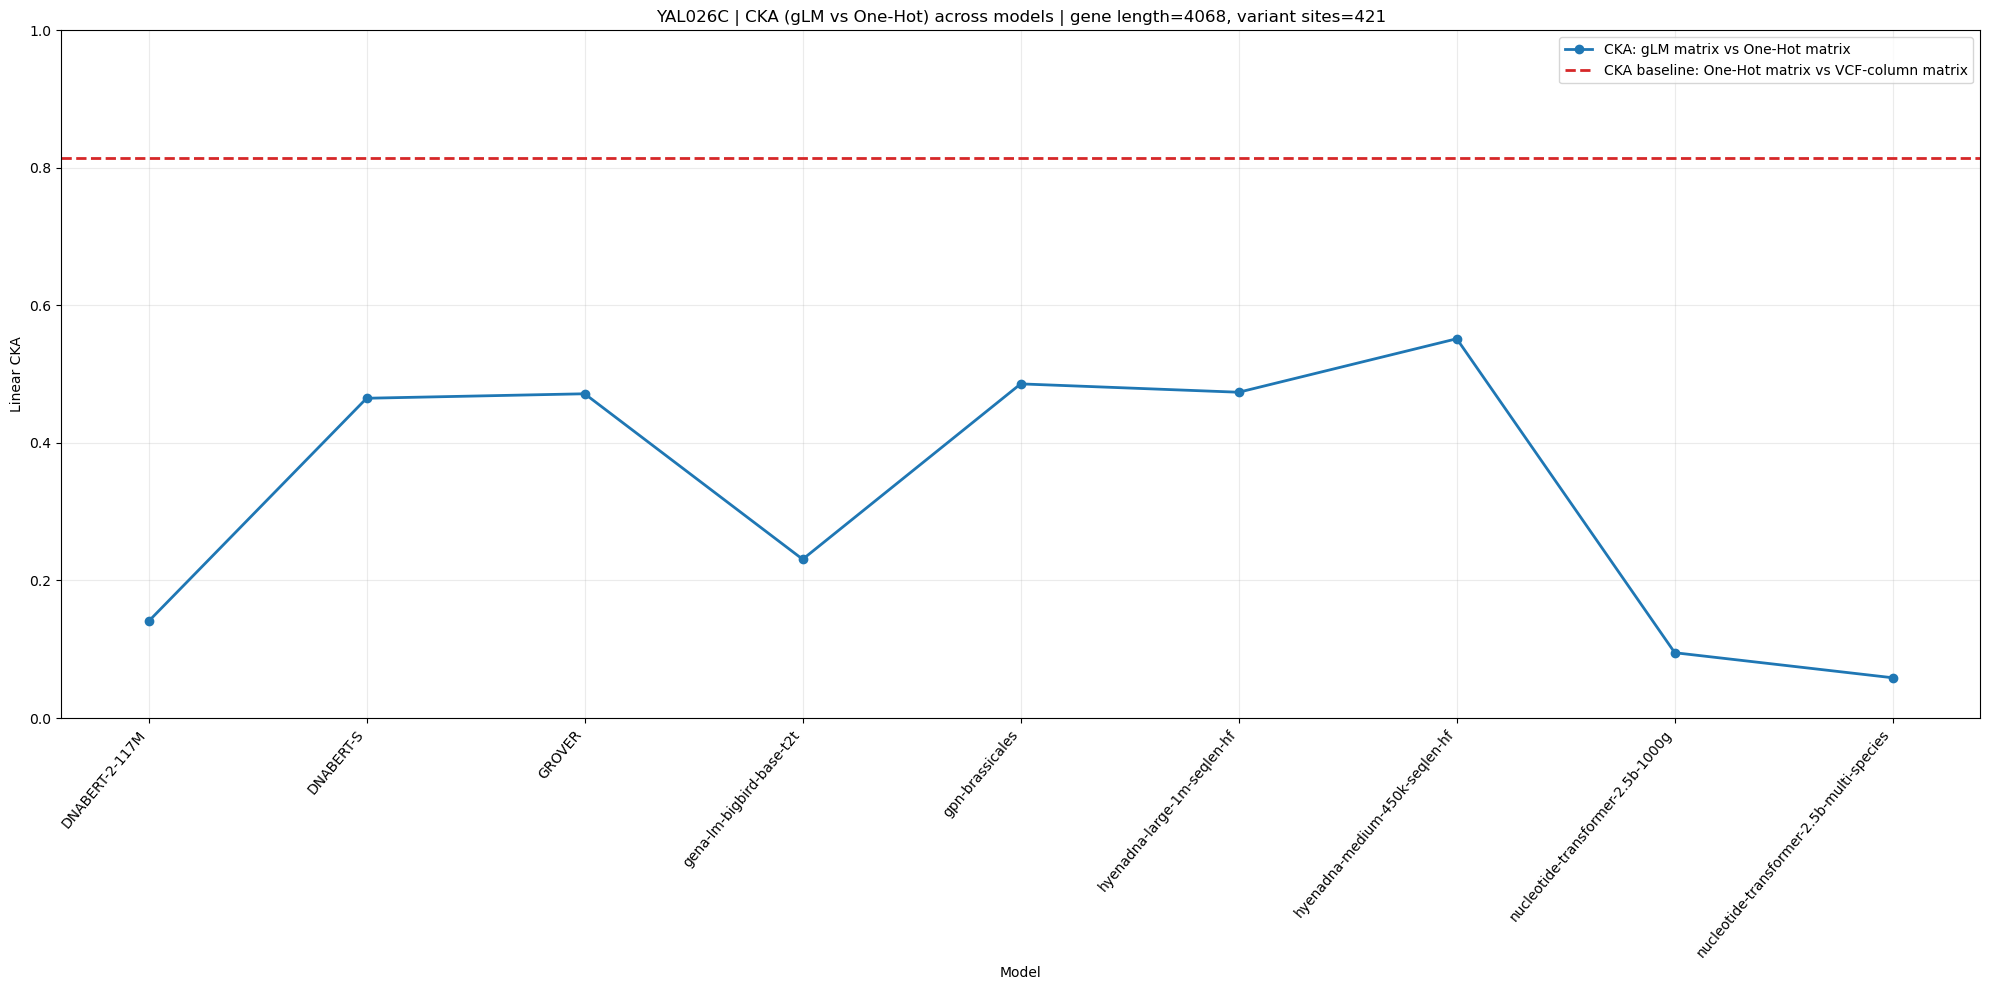

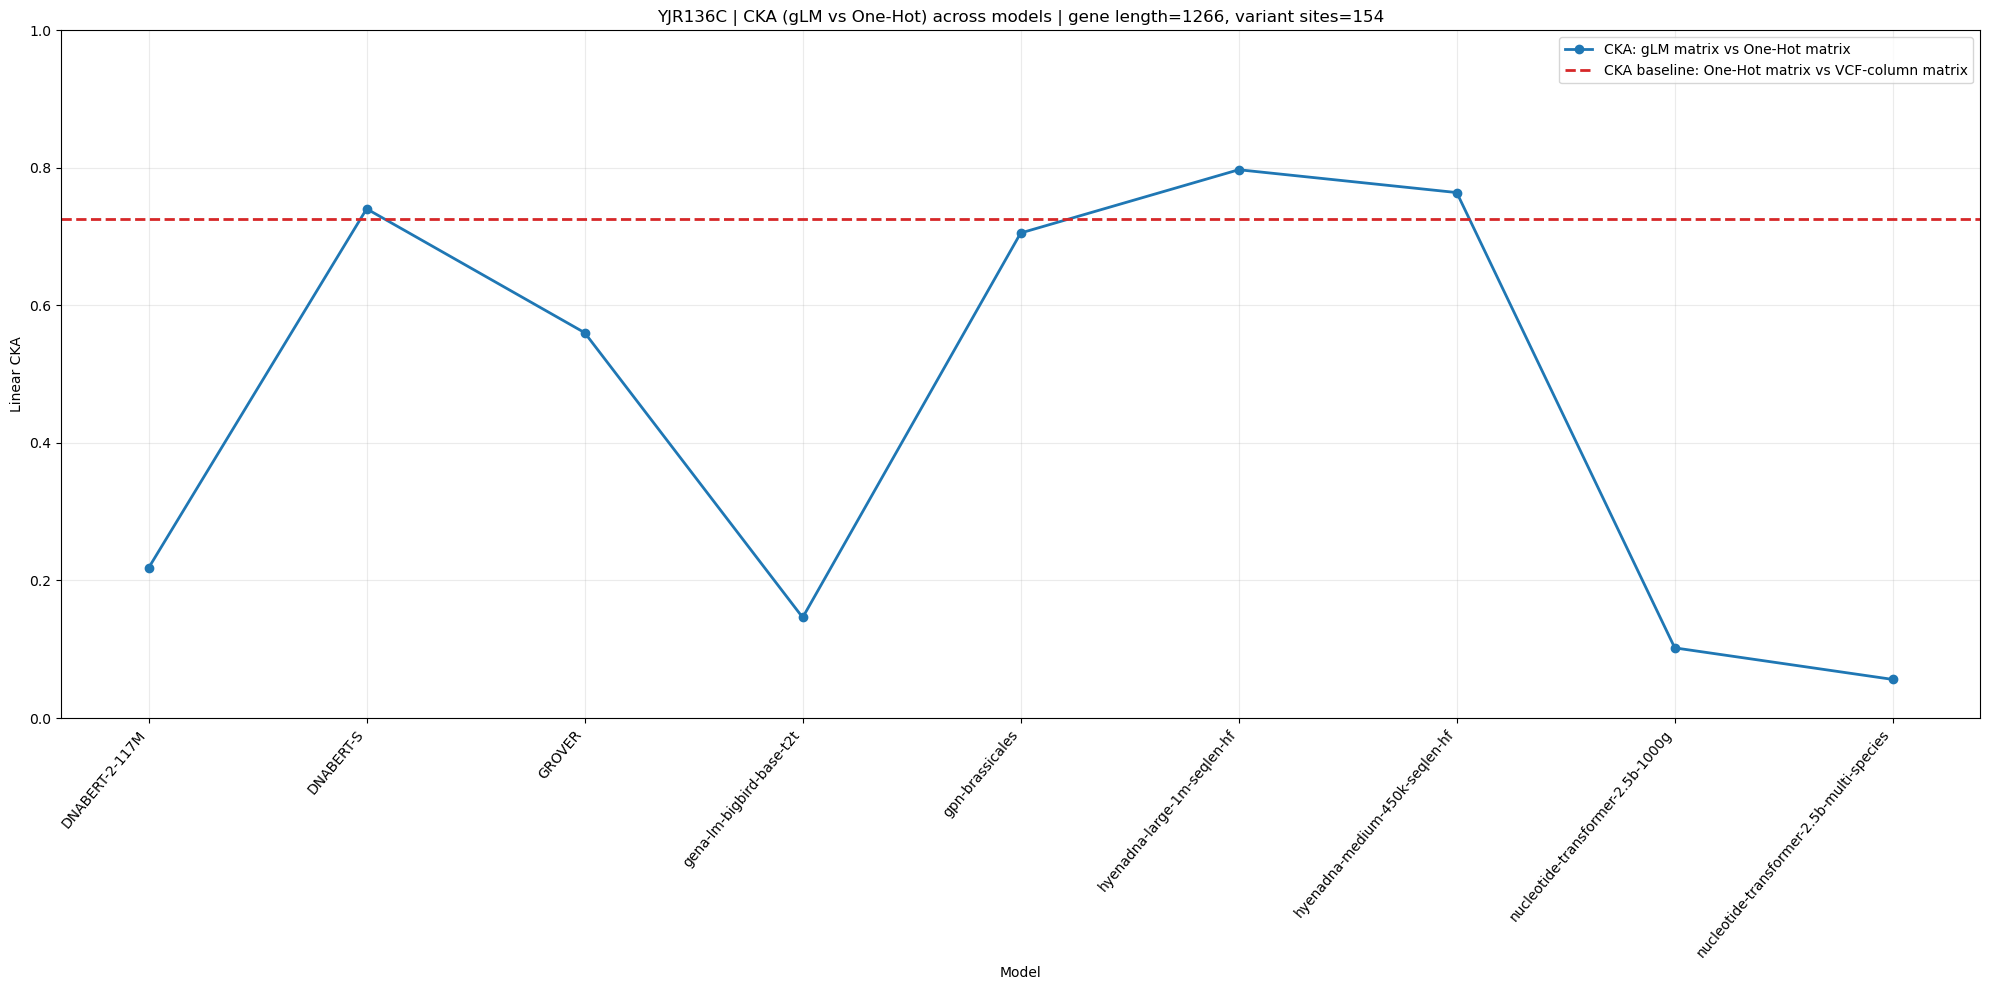

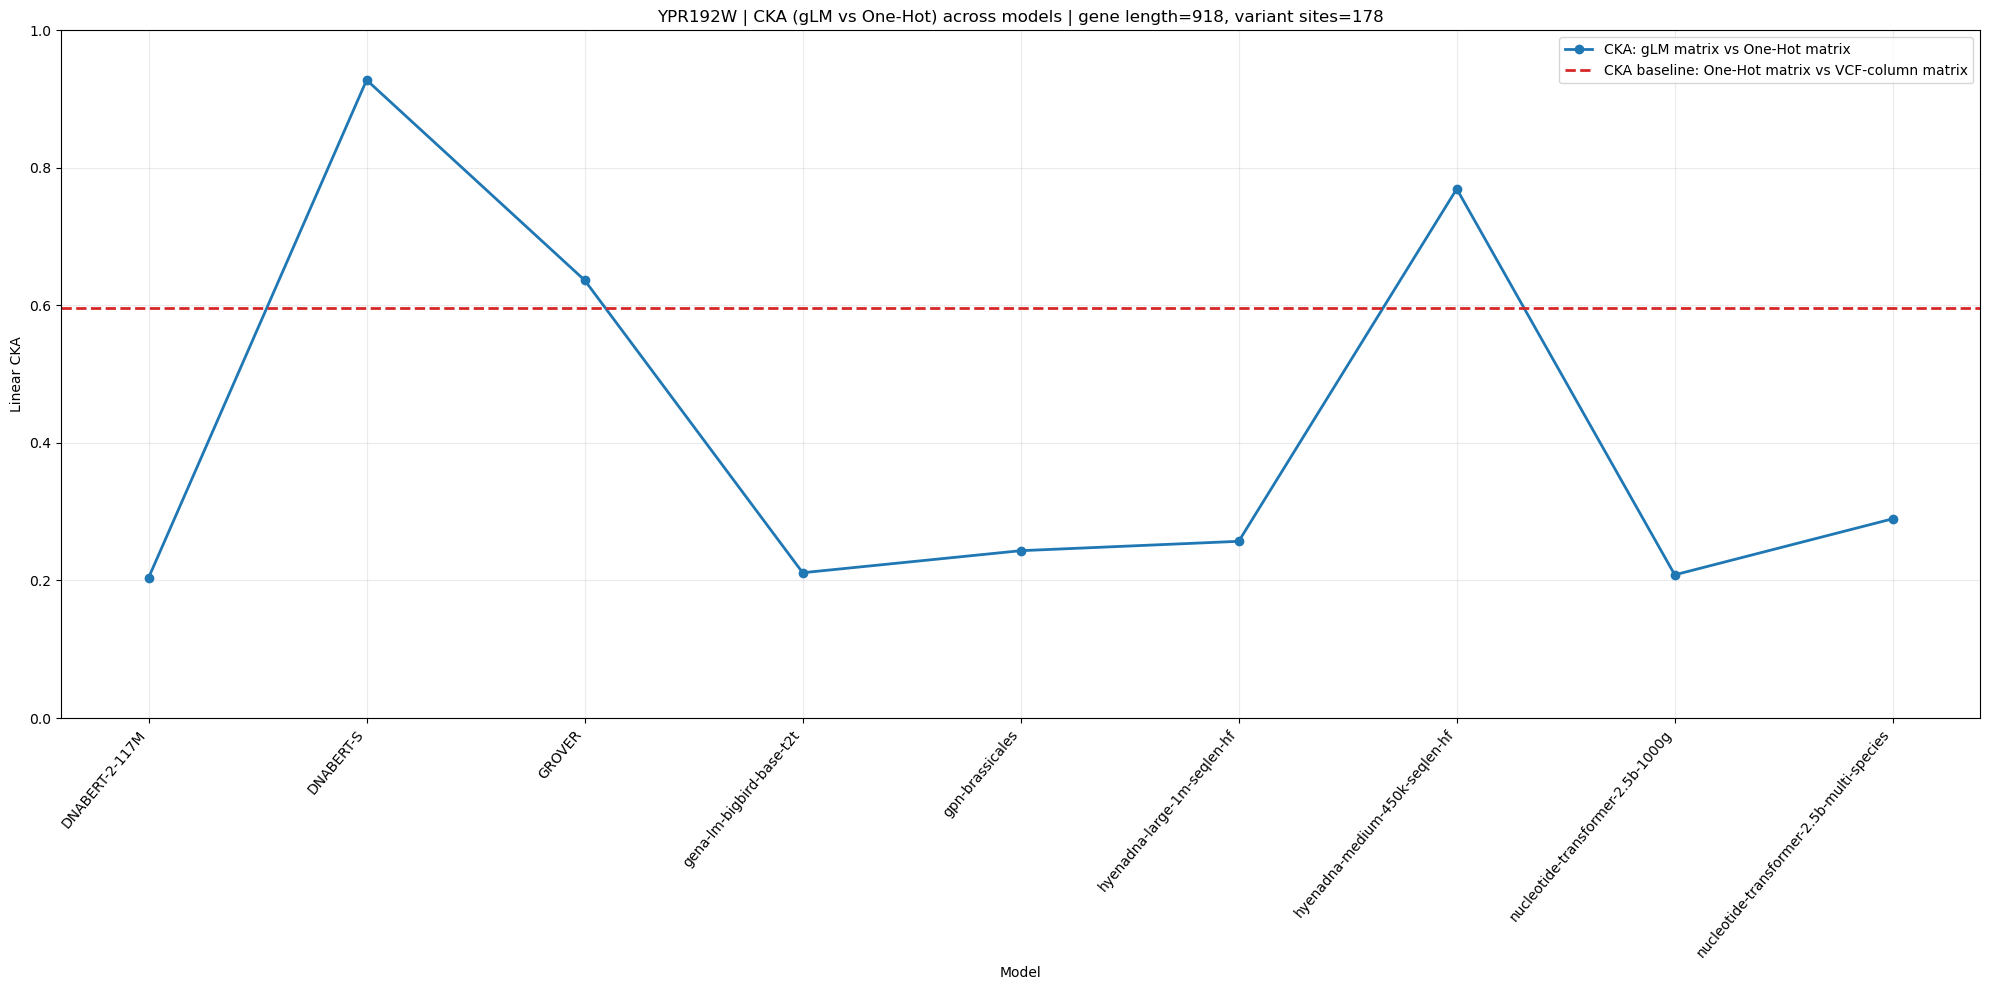

In [8]:
# 4) CKA: gLM vs One-Hot across models, with One-Hot-vs-VCF constant dashed baseline
for gene in sorted(plot_df["gene"].unique()):
    g = plot_df[plot_df["gene"] == gene].sort_values("model_short")

    plt.figure(figsize=(20, 10))
    plt.plot(
        g["model_short"],
        g["cka_glm_vs_onehot"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="CKA: gLM matrix vs One-Hot matrix",
    )
    plt.axhline(
        g["cka_onehot_vs_vcf"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:red",
        label="CKA baseline: One-Hot matrix vs VCF-column matrix",
    )

    seq_len = g["seq_len"].iloc[0]
    n_sites = g["n_variant_sites"].iloc[0]
    plt.title(f"{gene} | CKA (gLM vs One-Hot) across models | gene length={seq_len}, variant sites={n_sites}")
    plt.xlabel("Model")
    plt.ylabel("Linear CKA")
    plt.ylim(0, 1)
    plt.xticks(rotation=50, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

do heatmap across models's pairwise set of embeddings CKA

cmap cluster map for a distance matrix; then plot

[skip] YAL001C | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YAL001C | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YAL001C | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YAL001C | hyenadna-medium-160k-seqlen-hf: missing embedding file


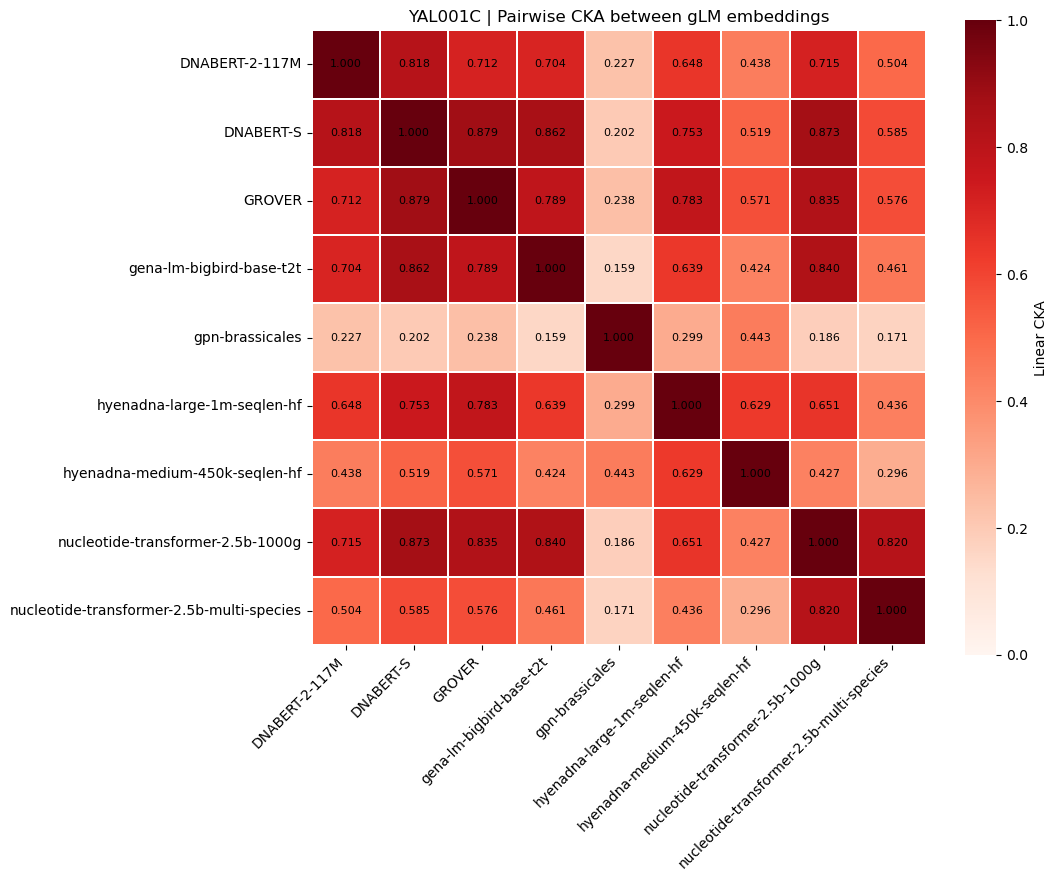

[skip] YAL007C | DNABERT-2-117M: missing embedding file
[skip] YAL007C | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YAL007C | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YAL007C | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YAL007C | hyenadna-medium-160k-seqlen-hf: missing embedding file


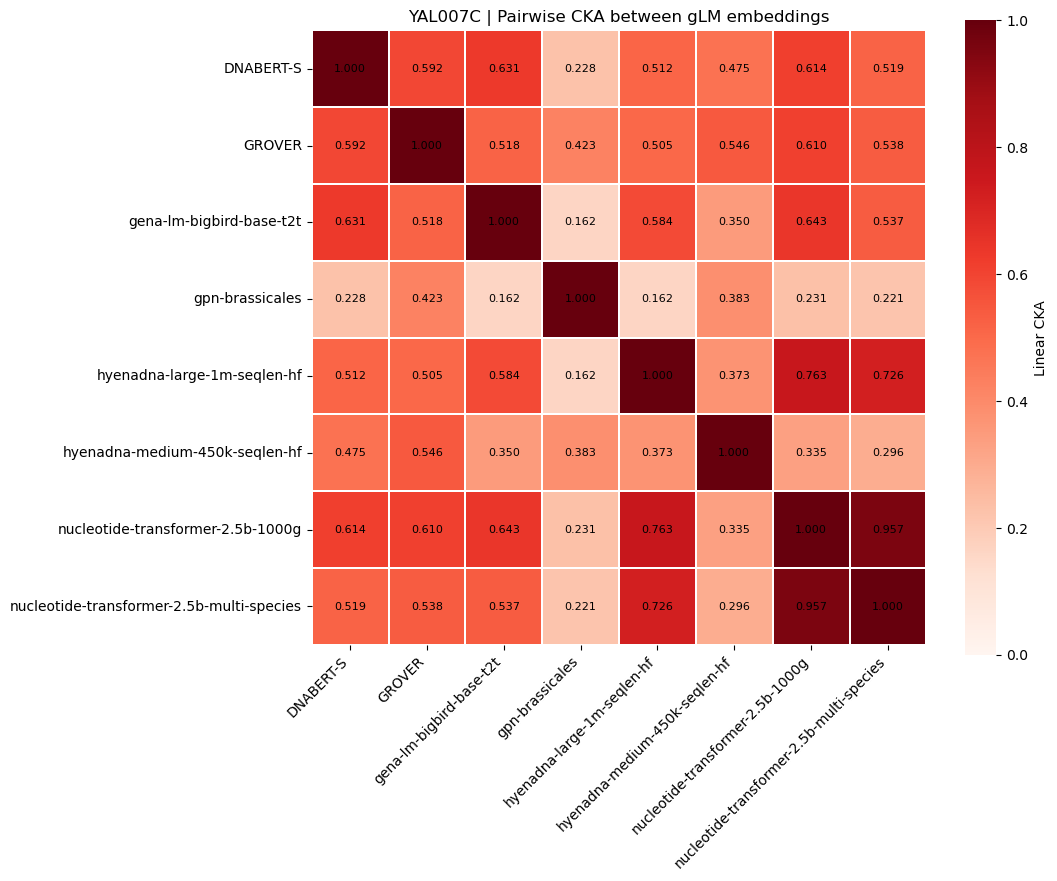

[skip] YAL018C | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YAL018C | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YAL018C | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YAL018C | hyenadna-medium-160k-seqlen-hf: missing embedding file


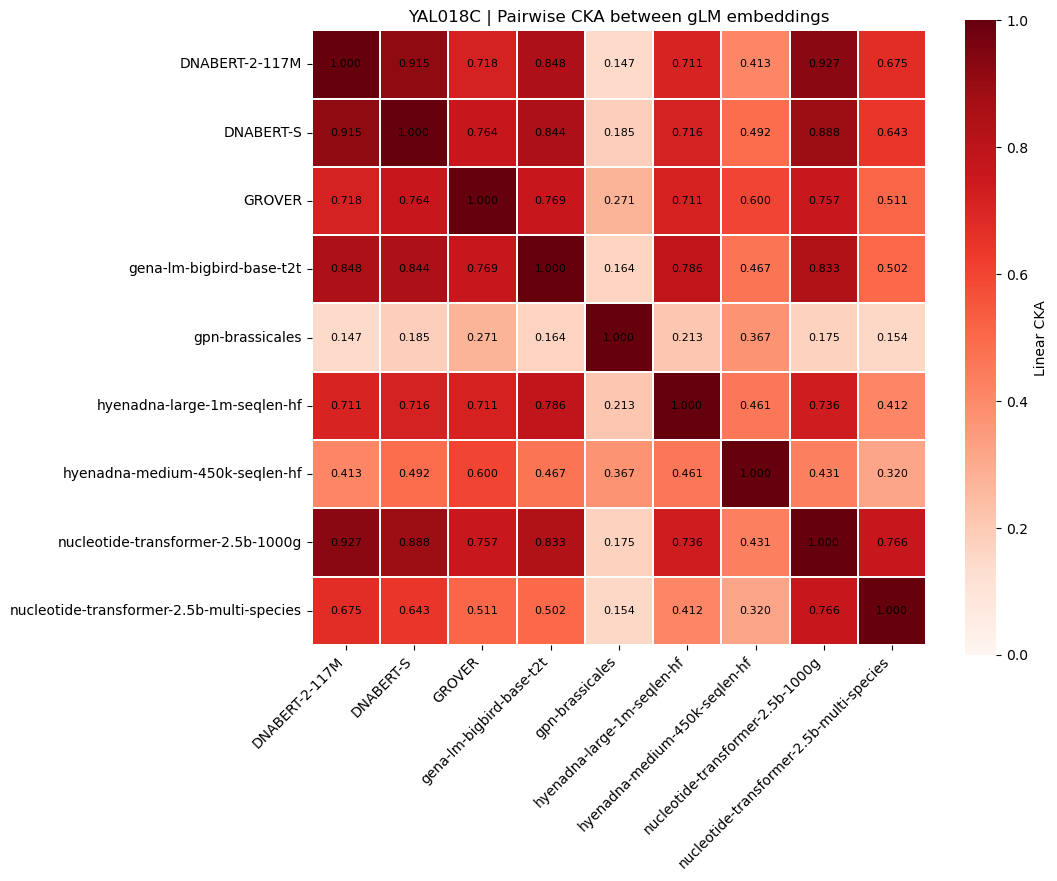

[skip] YAL022C | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YAL022C | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YAL022C | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YAL022C | hyenadna-medium-160k-seqlen-hf: missing embedding file


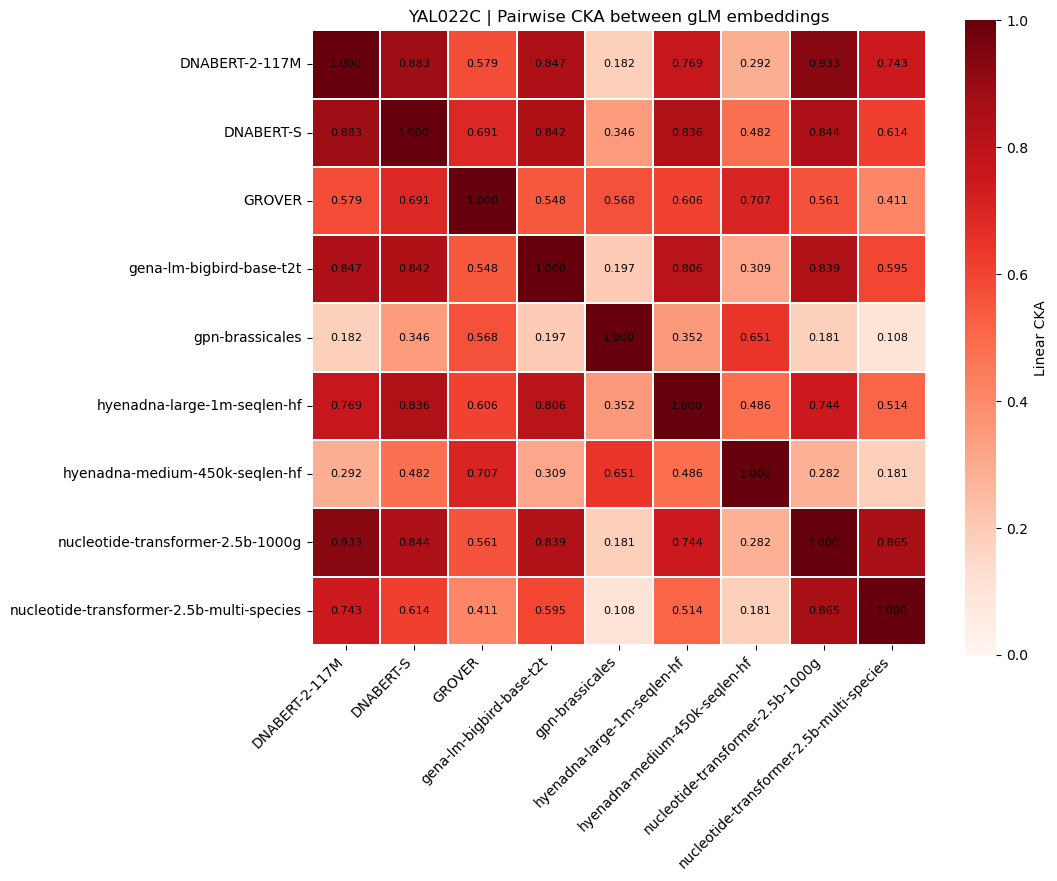

[skip] YAL026C | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YAL026C | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YAL026C | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YAL026C | hyenadna-medium-160k-seqlen-hf: missing embedding file


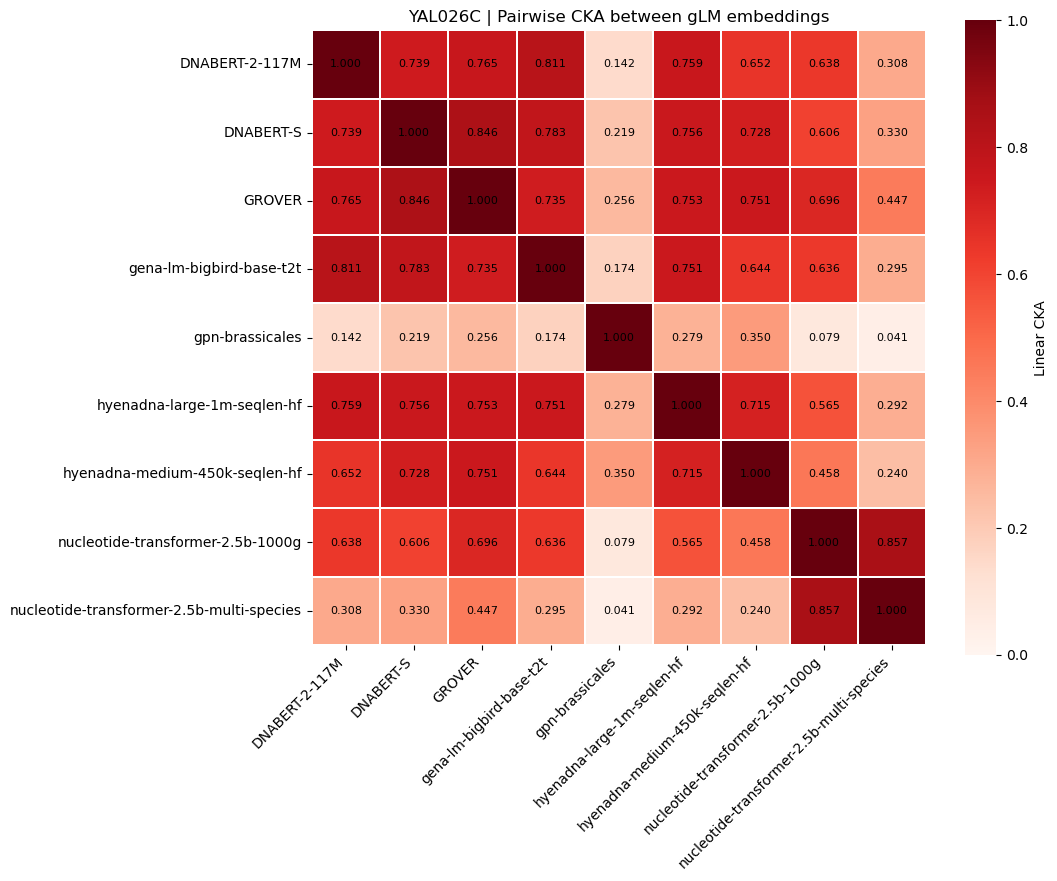

[skip] YJR136C | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YJR136C | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YJR136C | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YJR136C | hyenadna-medium-160k-seqlen-hf: missing embedding file


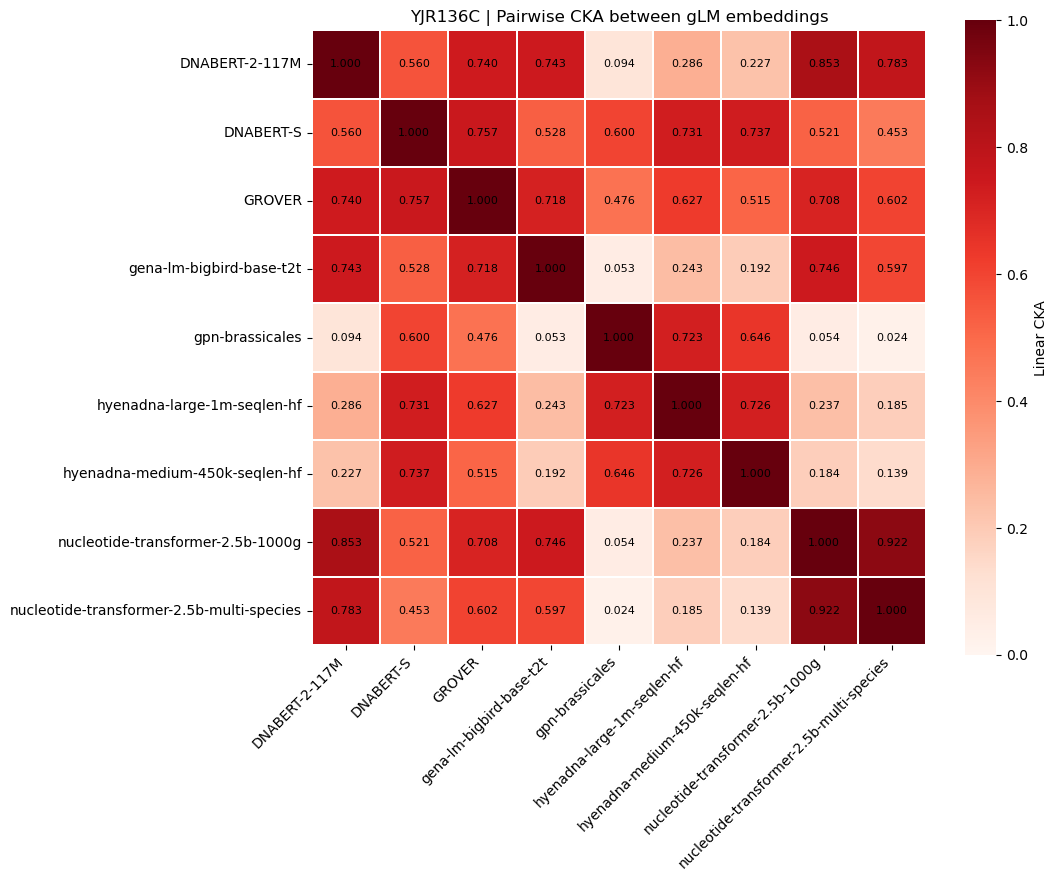

[skip] YPR192W | hyenadna-tiny-1k-seqlen-hf: missing embedding file
[skip] YPR192W | hyenadna-tiny-16k-seqlen-d128-hf: missing embedding file
[skip] YPR192W | hyenadna-small-32k-seqlen-hf: missing embedding file
[skip] YPR192W | hyenadna-medium-160k-seqlen-hf: missing embedding file


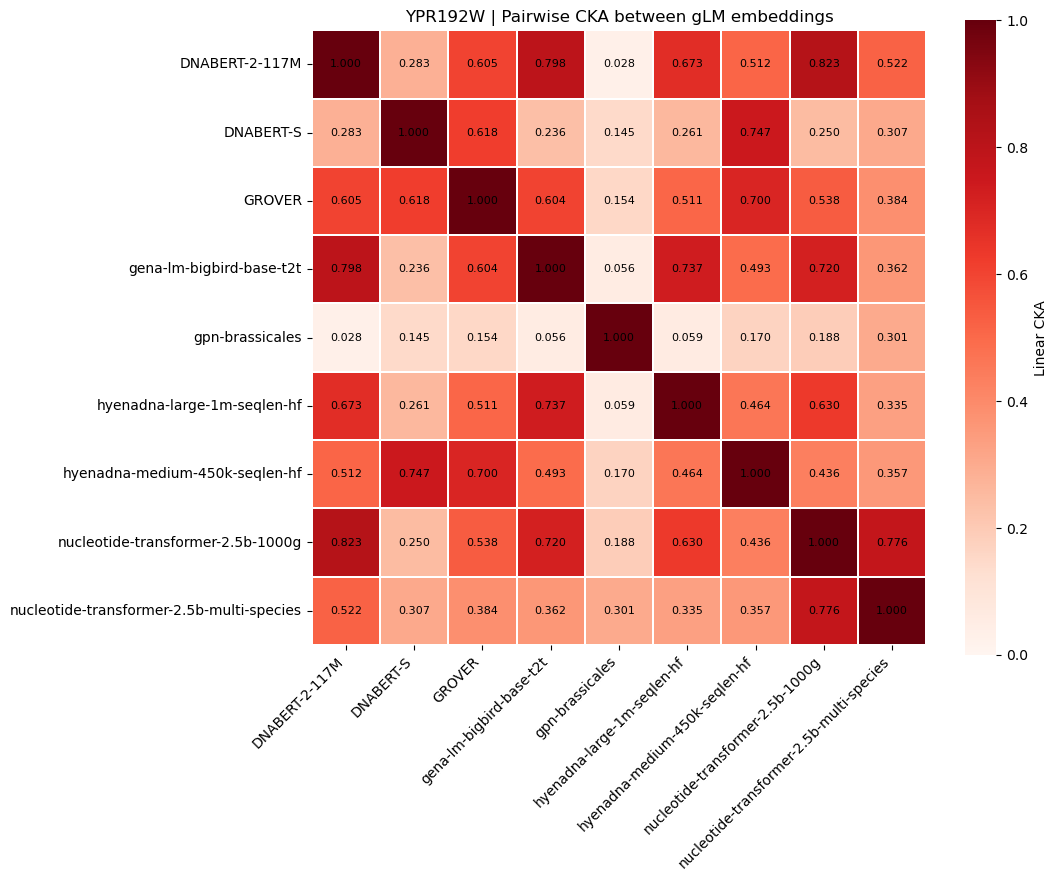

Saved per-gene pairwise CKA heatmaps to: Results\glm_vs_oh\pairwise_glm_cka_heatmaps


In [9]:
# Pairwise CKA heatmap across all gLM embeddings for each gene
PAIRWISE_CKA_DIR = RESULTS_DIR / "pairwise_glm_cka_heatmaps"
PAIRWISE_CKA_DIR.mkdir(parents=True, exist_ok=True)

def load_gene_model_embeddings(gene, model_list, embed_root):
    out = {}
    for model in model_list:
        model_short = model.split("/")[-1]
        emb_file = embed_root / gene / f"{model_short}_{gene}.txt"
        if not emb_file.exists():
            print(f"[skip] {gene} | {model_short}: missing embedding file")
            continue
        emb = load_glm_embeddings(emb_file)
        out[model_short] = emb
    return out

for gene in genes:
    model_embs = load_gene_model_embeddings(gene, models, EMBED_DIR)
    model_names = sorted(model_embs.keys())

    if len(model_names) < 2:
        print(f"[skip] {gene}: need at least 2 models with embeddings")
        continue

    # Ensure sample counts align across models for this gene.
    n_set = {model_embs[m].shape[0] for m in model_names}
    if len(n_set) != 1:
        print(f"[skip] {gene}: sample-count mismatch across models -> {n_set}")
        continue

    cka_mat = np.zeros((len(model_names), len(model_names)), dtype=float)
    for i, m1 in enumerate(model_names):
        for j, m2 in enumerate(model_names):
            cka_mat[i, j] = linear_cka(model_embs[m1], model_embs[m2])

    cka_df = pd.DataFrame(cka_mat, index=model_names, columns=model_names)
    cka_df.to_csv(PAIRWISE_CKA_DIR / f"{gene}_pairwise_glm_cka.csv")

    plt.figure(figsize=(11, 9))
    sns.heatmap(
        cka_df,
        cmap="Reds",
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.25,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 8, "color": "black"},
        cbar_kws={"label": "Linear CKA"},
    )
    plt.title(f"{gene} | Pairwise CKA between gLM embeddings")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(PAIRWISE_CKA_DIR / f"{gene}_pairwise_glm_cka_heatmap.png", dpi=180)
    plt.show()

print(f"Saved per-gene pairwise CKA heatmaps to: {PAIRWISE_CKA_DIR}")

## CKA b/w glm and vcf encodings

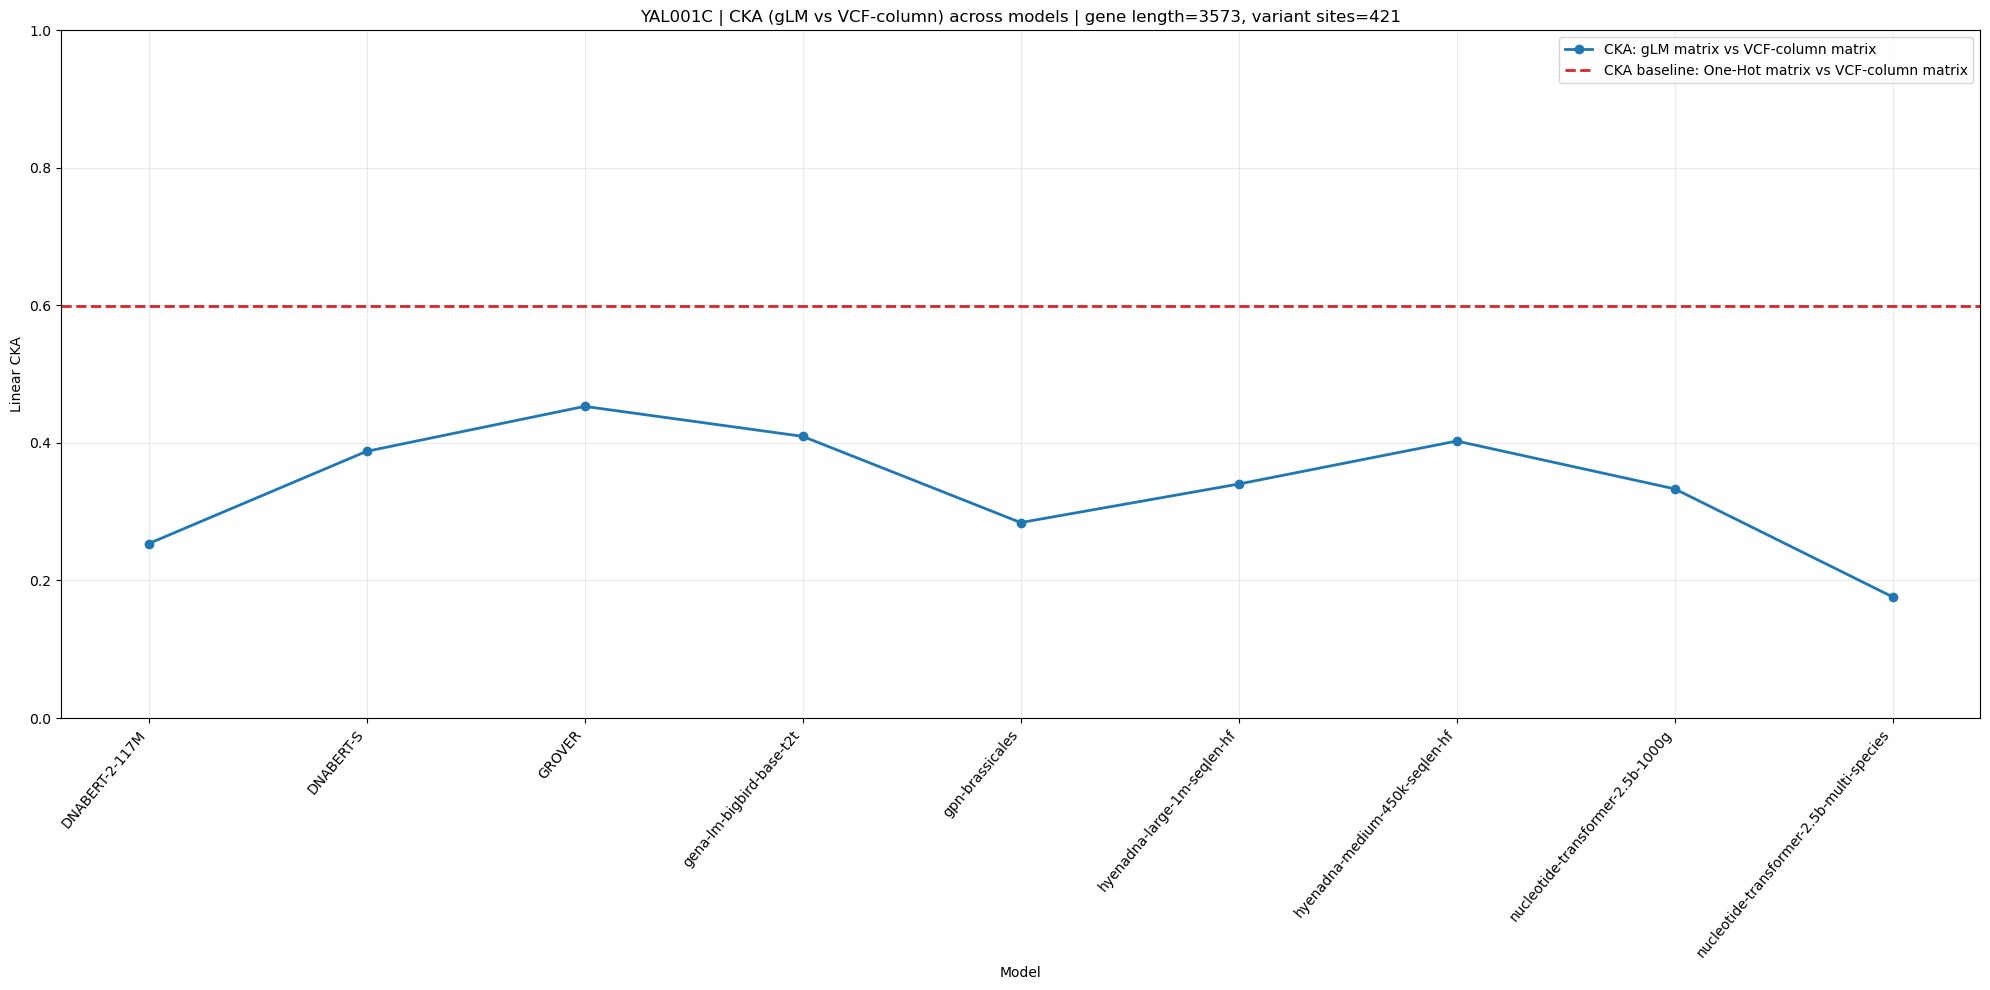

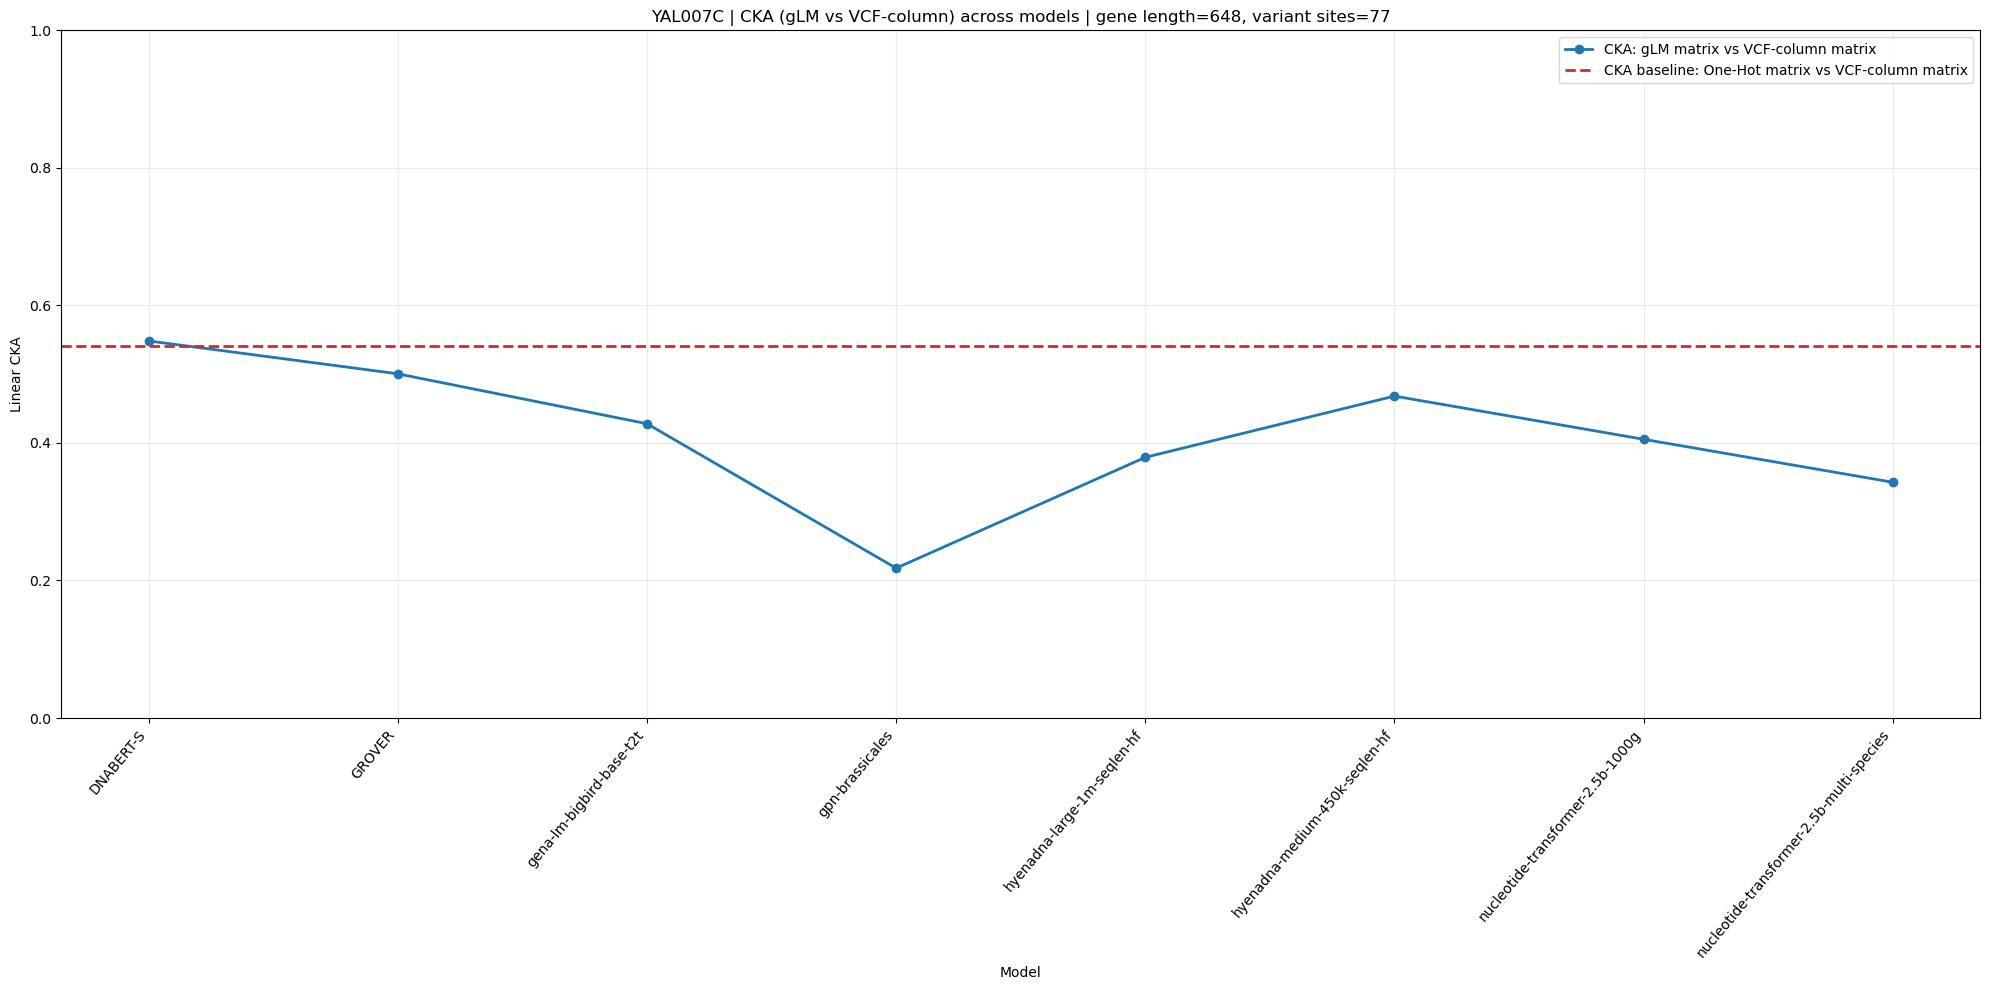

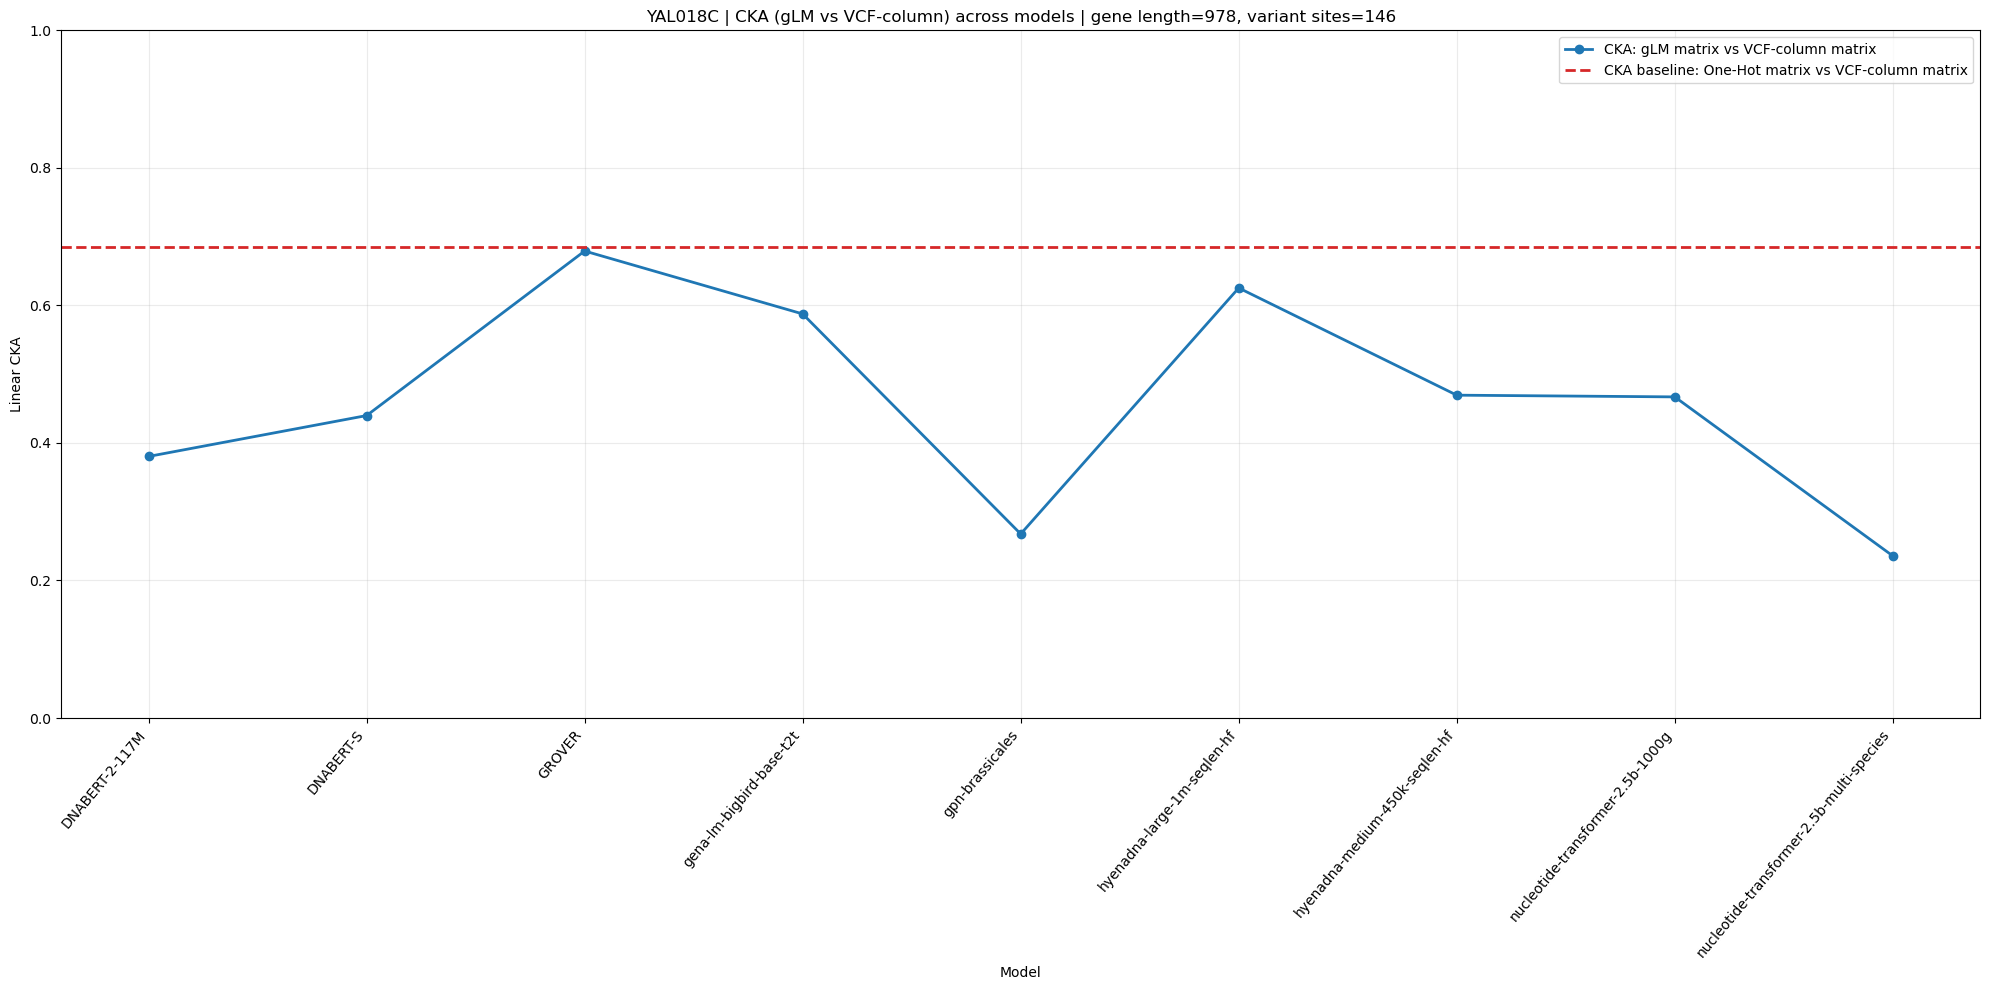

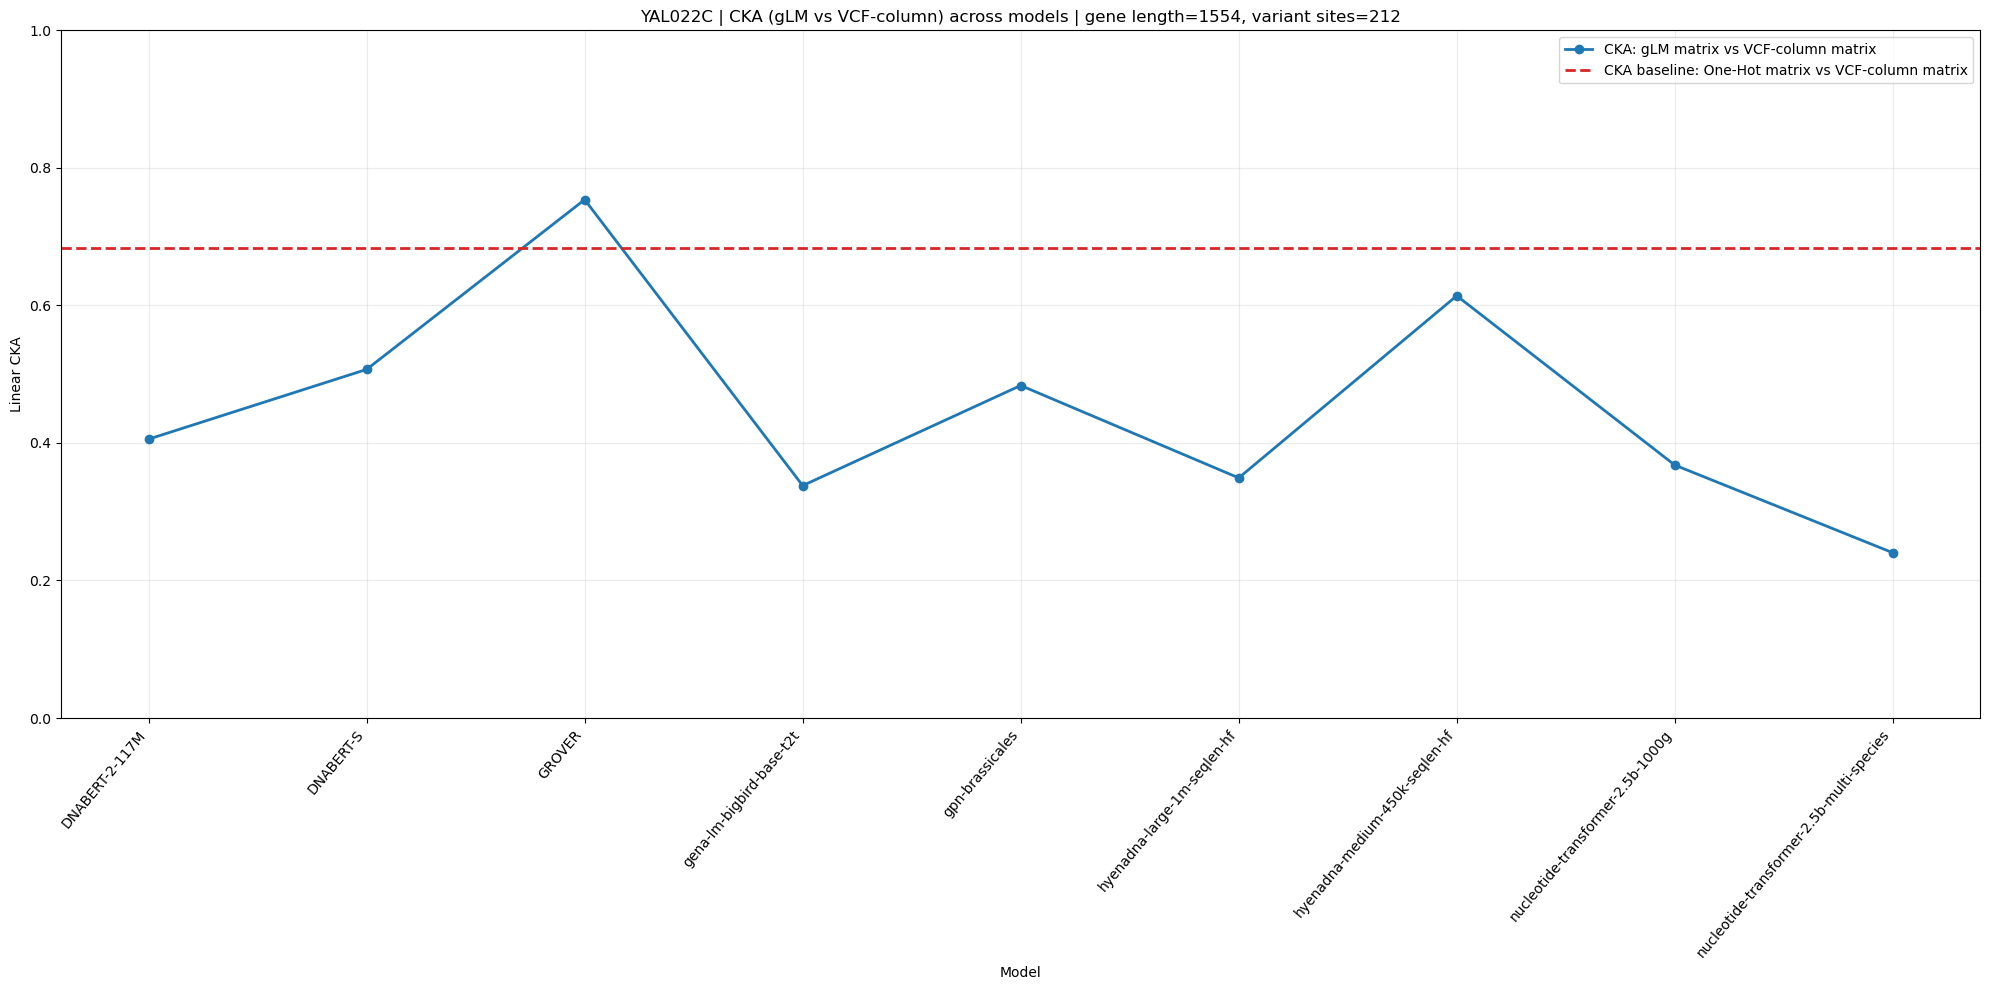

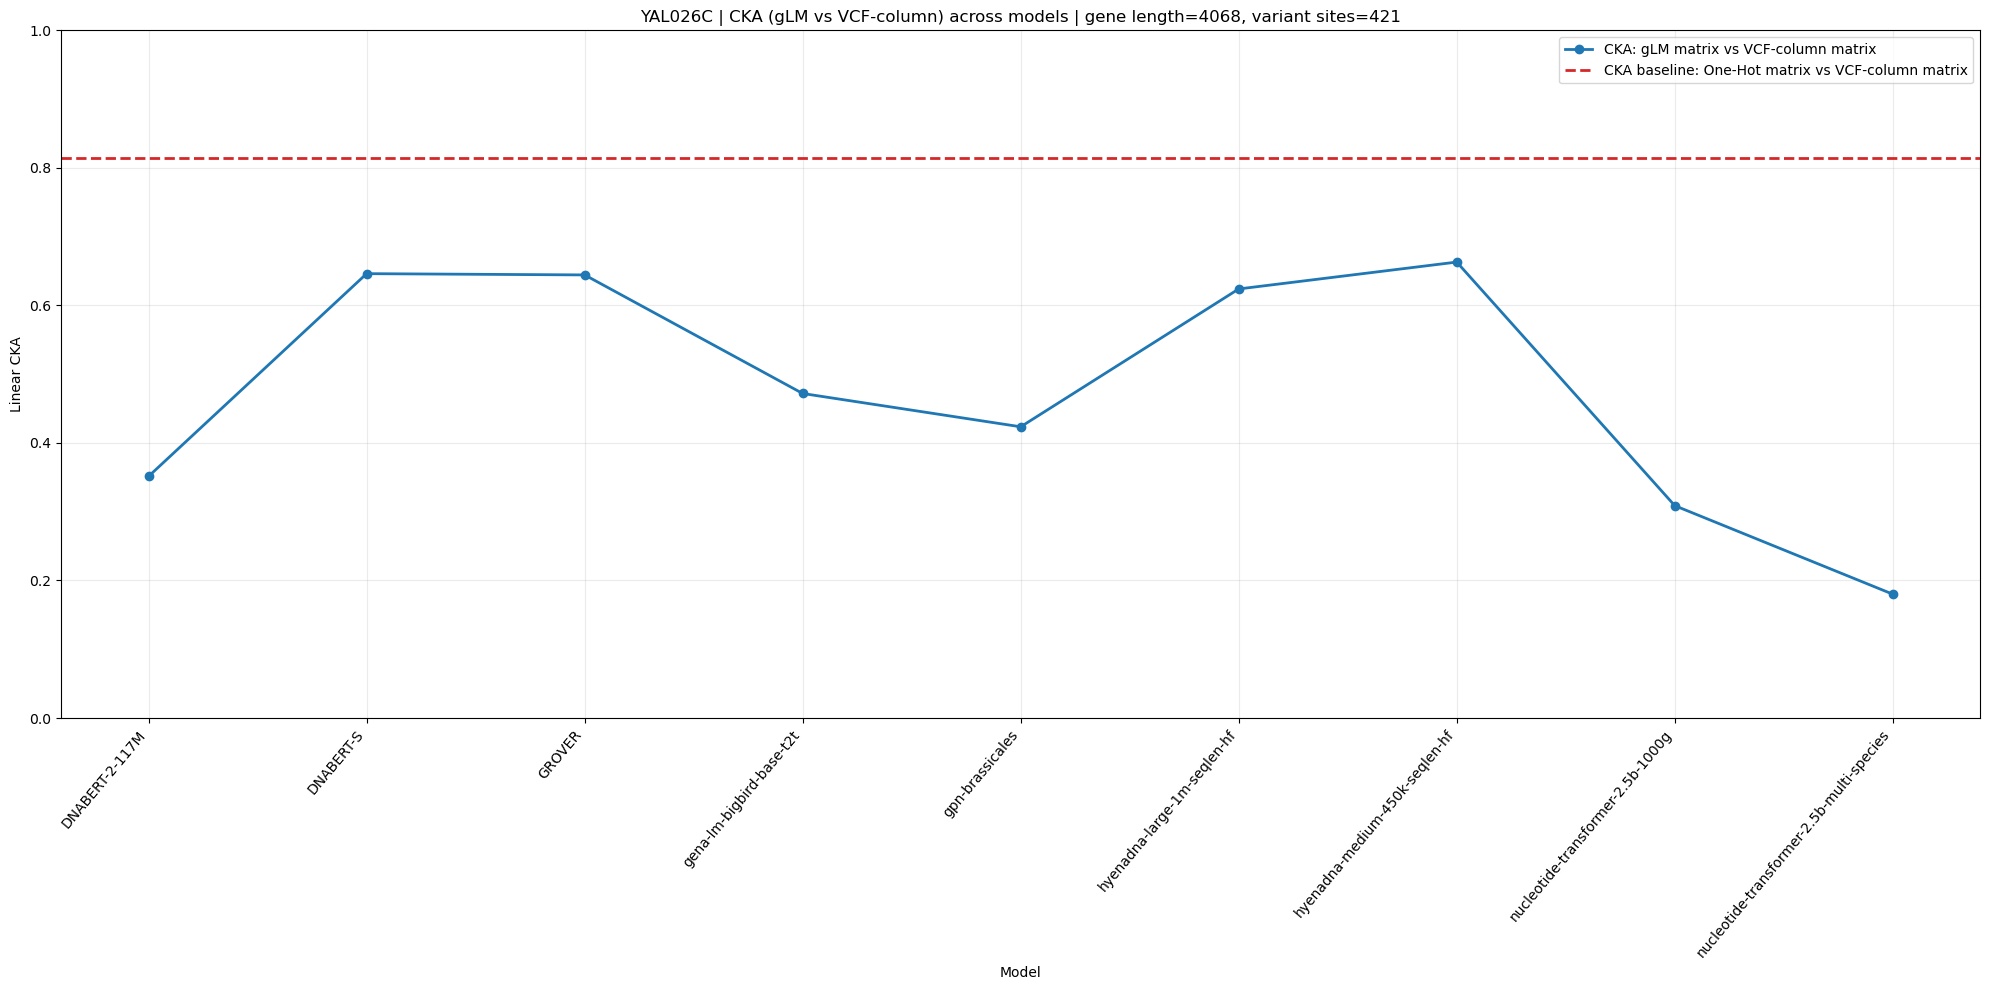

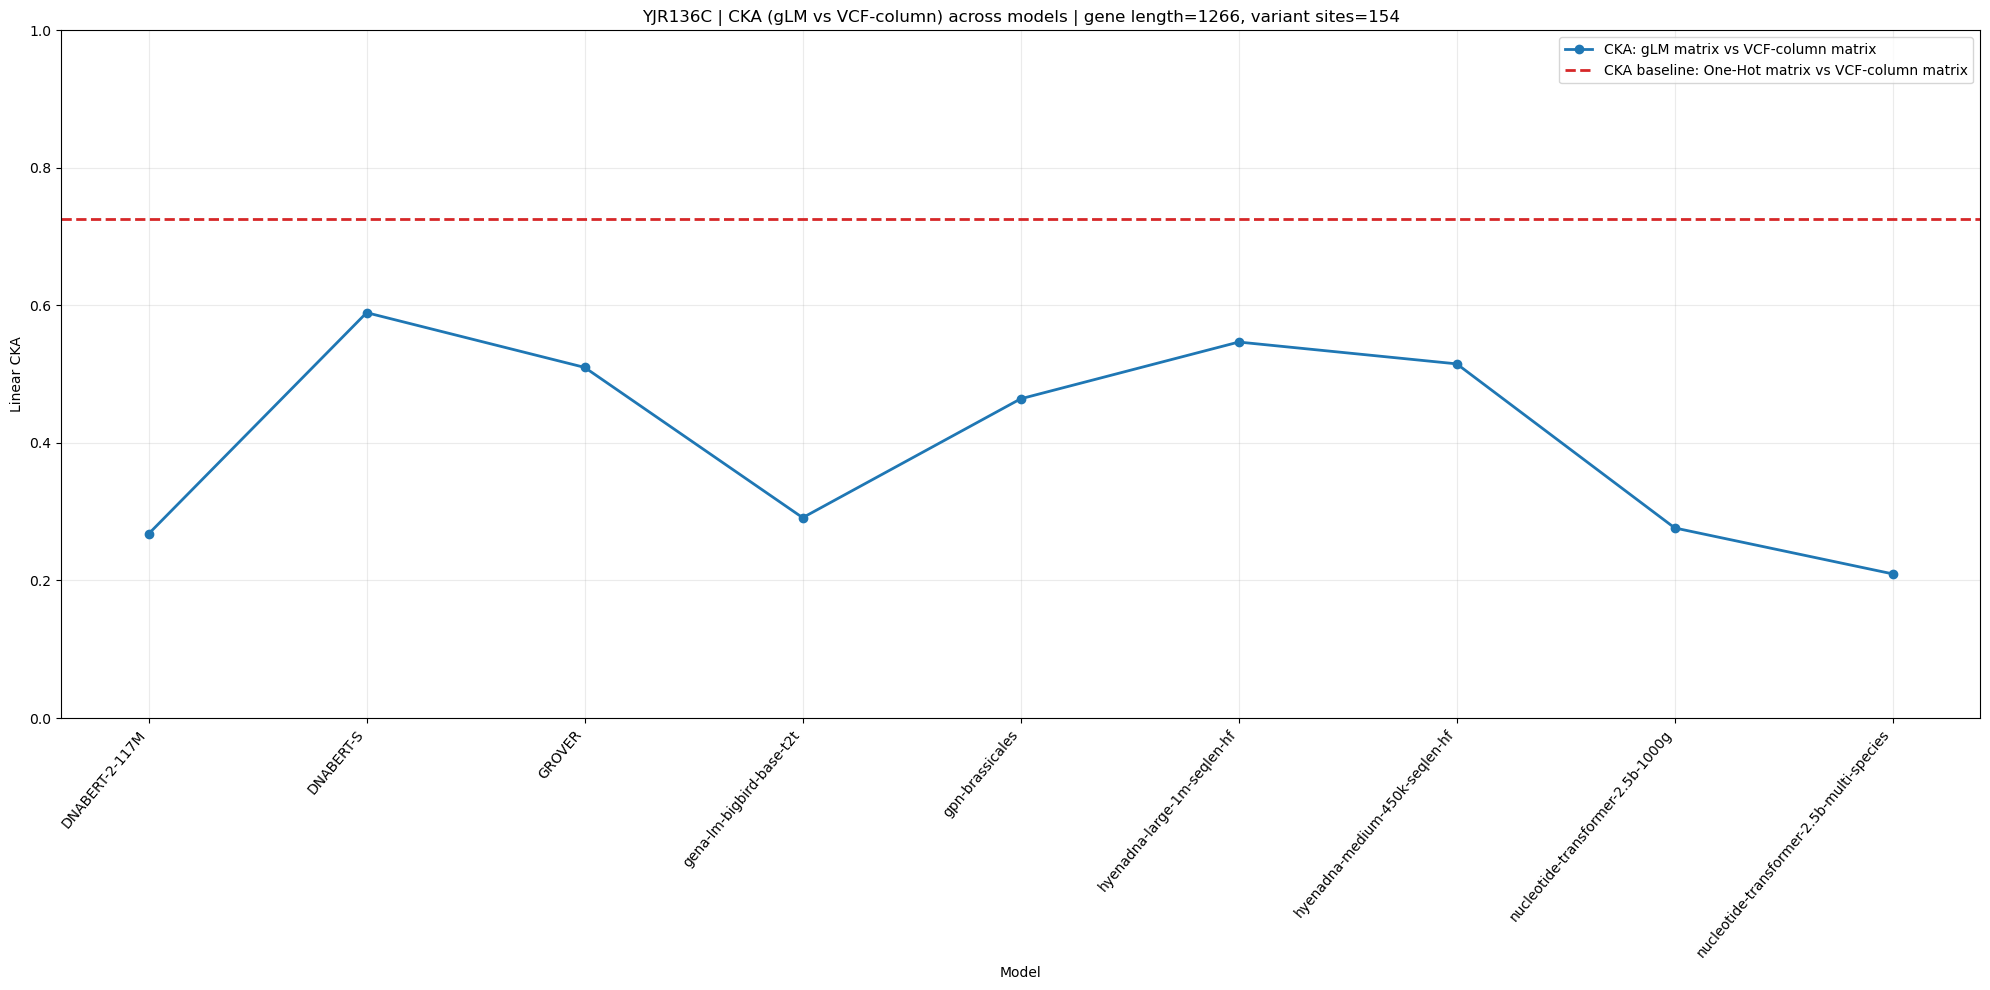

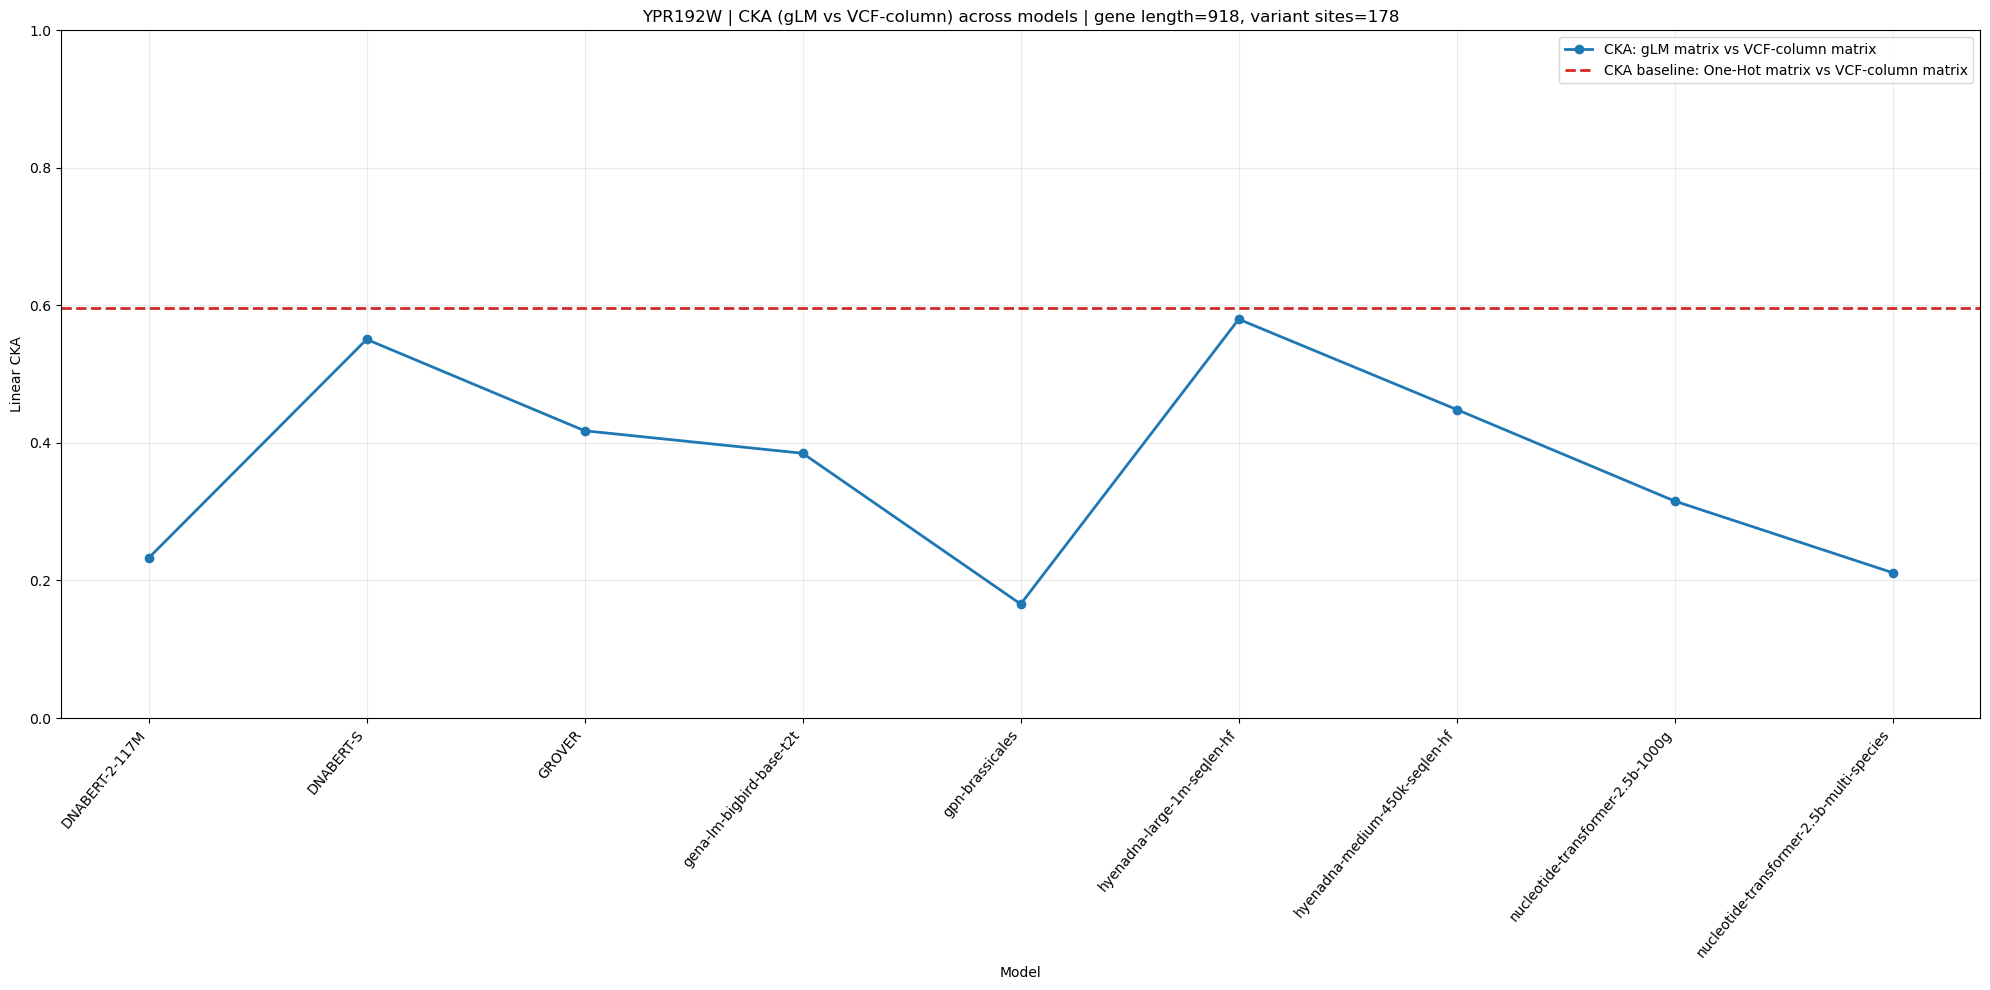

In [9]:
# 5) CKA: gLM vs VCF-column matrix across models, with One-Hot-vs-VCF constant dashed baseline
for gene in sorted(plot_df["gene"].unique()):
    g = plot_df[plot_df["gene"] == gene].sort_values("model_short")

    plt.figure(figsize=(20, 10))
    plt.plot(
        g["model_short"],
        g["cka_glm_vs_vcf"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="CKA: gLM matrix vs VCF-column matrix",
    )
    plt.axhline(
        g["cka_onehot_vs_vcf"].iloc[0],
        linestyle="--",
        linewidth=2,
        color="tab:red",
        label="CKA baseline: One-Hot matrix vs VCF-column matrix",
    )

    seq_len = g["seq_len"].iloc[0]
    n_sites = g["n_variant_sites"].iloc[0]
    plt.title(f"{gene} | CKA (gLM vs VCF-column) across models | gene length={seq_len}, variant sites={n_sites}")
    plt.xlabel("Model")
    plt.ylabel("Linear CKA")
    plt.ylim(0, 1)
    plt.xticks(rotation=50, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [13]:
# Final per-model summary statistics (mean, std, min, max across genes)
summary_stats = (
    plot_df.groupby("model", as_index=False)[
        [
            "ari_glm_vs_clades",
            "ari_onehot_vs_clades",
            "ari_vcf_vs_clades",
            "ari_glm_vs_onehot",
            "ari_glm_vs_vcf",
            "ari_onehot_vs_vcf",
            "sil_glm",
            "sil_onehot",
            "sil_vcf",
            "cka_glm_vs_onehot",
            "cka_glm_vs_vcf",
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)

summary_stats.columns = [f"{metric}_{stat}" for metric, stat in summary_stats.columns]
summary_stats = summary_stats.reset_index().sort_values("ari_glm_vs_clades_mean", ascending=False)

summary_path = RESULTS_DIR / "glm_oh_vcf_model_summary_stats.csv"
summary_stats.to_csv(summary_path, index=False)

display(summary_stats.head(20))
print(f"Saved model summary stats to: {summary_path}")

,index,model_,ari_glm_vs_clades_mean,ari_glm_vs_clades_std,ari_glm_vs_clades_min,ari_glm_vs_clades_max,ari_onehot_vs_clades_mean,ari_onehot_vs_clades_std,ari_onehot_vs_clades_min,ari_onehot_vs_clades_max,...,sil_vcf_min,sil_vcf_max,cka_glm_vs_onehot_mean,cka_glm_vs_onehot_std,cka_glm_vs_onehot_min,cka_glm_vs_onehot_max,cka_glm_vs_vcf_mean,cka_glm_vs_vcf_std,cka_glm_vs_vcf_min,cka_glm_vs_vcf_max
7,7,zhihan1996/DNABERT-2-117M,0.352490,0.106262,0.239423,0.550359,0.364690,0.162165,0.222285,0.66713,...,0.258028,0.627764,0.169948,0.036699,0.128962,0.218309,0.315262,0.072921,0.232688,0.405566
0,0,AIRI-Institute/gena-lm-bigbird-base-t2t,0.347911,0.123548,0.124108,0.457054,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.197296,0.037058,0.146223,0.238745,0.415919,0.096049,0.291342,0.587617
3,3,LongSafari/hyenadna-large-1m-seqlen-hf,0.343333,0.151155,0.145197,0.549667,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.416755,0.204634,0.180401,0.797302,0.492075,0.130442,0.340262,0.625367
8,8,zhihan1996/DNABERT-S,0.342762,0.136262,0.136129,0.555108,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.493363,0.249147,0.266207,0.927761,0.524180,0.087959,0.387856,0.646173
5,5,PoetschLab/GROVER,0.339436,0.137611,0.105313,0.528294,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.572139,0.105726,0.414113,0.728400,0.565509,0.126706,0.417729,0.753777
4,4,LongSafari/hyenadna-medium-450k-seqlen-hf,0.325937,0.125847,0.146241,0.504792,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.672745,0.113303,0.544517,0.823879,0.511586,0.093899,0.402804,0.663040
6,6,songlab/gpn-brassicales,0.315604,0.094775,0.137861,0.429919,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.474147,0.165358,0.243340,0.705333,0.329546,0.126401,0.165706,0.483547
1,1,InstaDeepAI/nucleotide-transformer-2.5b-1000g,0.277533,0.115083,0.020773,0.352180,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.149512,0.041211,0.094991,0.208260,0.353434,0.065284,0.276401,0.466986
2,2,InstaDeepAI/nucleotide-transformer-2.5b-multi-...,0.245843,0.115740,0.049592,0.351789,0.333941,0.168916,0.149452,0.66713,...,0.258028,0.762275,0.119583,0.081779,0.056140,0.289765,0.227995,0.056305,0.176051,0.342876


Saved model summary stats to: Results\glm_vs_oh\glm_oh_vcf_model_summary_stats.csv
